# Irradiated Microstructure of Ferritic / Ferritic–Martensitic Steels
## Experimental database, temperature fits and loop size-distribution fits

**Source data** — `FerriticSteels_RadiationDatabase.xlsx` (this directory), read *directly and
only* from its raw sheets so that every plotted point is traceable to a sheet row, a
literature reference and a DOI.

**Narrative source** — Appendix G (*Experimental Database*) of
`Ferritic_Martensitic_Steel_Microstructure.pdf`, N. M. Ghoniem (2026), together with the
`README` and `Summary_Trends` sheets of the workbook.

**Purpose** — provide a single, self-contained, reproducible processing of the raw
measurements into (i) temperature-dependent fits of dislocation-loop and void/cavity
number density and mean size, and (ii) lognormal fits of the measured dislocation-loop
size distributions, in a form that can be compared directly against `RadCluster`
cluster-dynamics predictions.

This notebook replaces the three earlier, mutually redundant notebooks
(`EuroferMicroData.ipynb`, `EuroferExperiments.ipynb`, `EuroferRadiationMicro.ipynb`).

---
# 1. The irradiated microstructure of F/M steels

Reduced-activation ferritic/martensitic (RAFM) steels — EUROFER97, F82H, T91, HT9, and the
Fe–9Cr / Fe–12Cr model alloys — start from a **tempered-martensite** condition: a lath
structure with a high pre-existing network dislocation density
($\rho_d \sim 10^{14}$ m⁻²), M₂₃C₆ carbides on prior-austenite and lath
boundaries, and finely dispersed MX (TaC, VN) particles. Under irradiation four
populations develop, and it is these that the database records.

### 1.1 Dislocation loops
Displacement cascades produce self-interstitial clusters that grow into prismatic
dislocation loops with two Burgers vectors in bcc iron:

| Loop type | Burgers vector | Character | Where it dominates |
|---|---|---|---|
| $a/2\langle 111\rangle$ | $\tfrac12\langle111\rangle$ | glissile, 1-D glide | $T \lesssim 300$ °C in EUROFER97 |
| $a\langle 100\rangle$ | $\langle100\rangle$ | sessile | $T \gtrsim 350$ °C; T91/HT9 at all doses, 376–460 °C |

Below ~300 °C the visible population is dominated by sub-3 nm **"black dots"**
(unresolved clusters, ~90 % of the population at 250 °C); resolved loops appear
as a shoulder at 5–15 nm. Above 350 °C the distribution becomes a well-developed
right-skewed **log-normal** centred at 10–13 nm, and above ~460 °C loops are
absorbed into the network dislocation structure. Obstacle strengths for dispersed-barrier
hardening are $\alpha \approx 0.45$–$0.54$ for $a\langle100\rangle$ and $\alpha \approx 0.17$
for $\tfrac12\langle111\rangle$ loops.

### 1.2 Cavities — voids and helium bubbles
F/M steels are exceptionally swelling-resistant compared with austenitic steels. The cavity
population is:

* **unimodal**, sub-2 nm, He-stabilised *sub-critical bubbles* at low dose or low
  temperature (all EUROFER97 conditions at 330–340 °C, and T91/HT9 below
  ~17–20 dpa), with $N_v \sim 10^{21}$ m⁻³ and swelling $< 0.02$ %;
* **bimodal** beyond ~35 dpa at 376–420 °C — a high-density small-bubble
  population ($d < 2$ nm, $\sim10^{21}$ m⁻³) coexisting with a lower-density
  *super-critical growing void* population ($d > 2$ nm, $\sim10^{19}$–$10^{20}$ m⁻³),
  separated by a valley near the critical radius $r_c \approx 1$ nm.

Despite its lower density the void population dominates swelling, since
$\Delta V/V \propto \sum_i N_i d_i^3$. Peak swelling occurs at 400–450 °C.

### 1.3 Radiation-induced precipitates
$\alpha'$ (Cr-rich bcc) forms in 9–12 %Cr steels at 250–380 °C and is absent above
~420 °C; G-phase (Mn–Ni–Si) is radiation-induced in T91 and HT9; MX and
M₂₃C₆ undergo radiation-enhanced coarsening. These are recorded in the workbook
(`Neutron_Precipitates`, `Ion_Precipitates`) but are **not fitted here** — this notebook is
restricted to loops and voids, as required.

---
## 2. Data sources

All rows come from the raw sheets of `FerriticSteels_RadiationDatabase.xlsx`:

| Sheet | Irradiation | Feature | Materials |
|---|---|---|---|
| `Neutron_DislocLoops` | neutron (fast / mixed / spallation) | dislocation loops | EUROFER97, EUROFER-ODS, F82H, T91, HT9, Fe-9Cr, Pure Fe |
| `Ion_DislocLoops` | self-ion, Kr⁺, dual-beam | dislocation loops | HT9, T91, T92, F82H, ODS, Fe-9Cr, CLAM, EUROFER97 |
| `Neutron_Voids_Swelling` | neutron | voids / cavities | EUROFER97, T91, HT9, Pure Fe |
| `Ion_Voids_Swelling` | self-ion, dual/triple beam | voids | HT9, T91, T92, ODS-FM, F82H |
| `Ion_He_Bubbles` | He⁺, dual Fe+He, spallation | He bubbles | ODS variants, CLAM, F82H, T91, Fe-12Cr |
| `Loop_Size_Distributions` | neutron + ion | loop size histograms | EUROFER97, EUROFER-ODS |

### Primary literature

The **#** column is the reference number printed on every data point in Sections 5–10
and appended to every legend entry in Section 9: a point labelled `7` was measured in
reference 7. The same number is repeated in the caption table under each figure, so a
marker can be traced to a row of the database and from there to the paper.

| # | Reference | Material | Irradiation | Facility | Dose (dpa) | $T$ (°C) | Method |
|---|---|---|---|---|---|---|---|
| 1 | Klimenkov 2012 — JNM 426(2012)52 <sup>+</sup> | EUROFER97 | N, fast | BOR-60 | 15, 32 | 330–335 | WBDF TEM |
| 2 | Gaganidze 2011 — JNM 417(2011)93 | EUROFER97 | N, fast | BOR-60 | 16.3 | 250–415 | BF/DF TEM |
| 3 | Gaganidze 2016 — NME 9(2016)471 <sup>+</sup> | EUROFER97 | N, mixed | HFR Petten | 15 | 300 | BF/DF TEM |
| 4 | Dethloff 2016 — NME 9(2016)471 | EUROFER97 | N, fast | BOR-60 (ARBOR) | 15 | 300 | WBDF TEM |
| 5 | Klimenkov 2017 — JNM 493(2017)426 | EUROFER-ODS | N, fast | BOR-60 | 16.3 | 350 | WBDF TEM |
| 6 | Wan 2010 — *not resolved* <sup>?</sup> | F82H | N, spallation | SINQ/STIP-III | 20 | 345 | BF/DF TEM |
| 7 | Gao 2018 — JNM 504(2018)122 <sup>+</sup> | T91 | N, fast | BOR-60 | 15.4, 35.1 | 376 | TEM/STEM/APT |
| 8 | Gao 2019 — JNM 523(2019)421 <sup>+</sup> | HT9 | N, fast | BOR-60 | 17.1, 35.1 | 377 | TEM/STEM/APT |
| 9 | Zhong 2021 — JNM 552(2021)153001 | T91, NF616 | N, fast | ATR | 4.3 | 469 | TEM/STEM |
| 10 | Zhong 2024 — JNM 593(2024)154990 | F/M steels | N, fast | — | — | — | TEM/STEM |
| 11 | Yan 2021 — JNM 557(2021)153207 | HT9 | N, fast | ATR | 4.02 | 300 | S/TEM + APT |
| 12 | Lambrecht 2014 — JNM 533(2020)152130 <sup>+</sup> | Fe-9Cr | N, fission | BR2 | 2.0 | 300 | WBDF TEM |
| 13 | Lambrecht 2009 — JNM 385(2009)334 | Pure Fe | N, fission | multiple | 0.19 | 300 | PAS + TEM |
| 14 | Eldrup 1999 — JNM 271–272(1999)97 | Pure Fe | N, fission | multiple | 0.79 | 60 | BF/DF TEM |
| 15 | English 1982 — JNM 108–109(1982)222 | Pure Fe | N, fission | reactors | 1.0 | 400 | BF/DF TEM |
| 16 | Gelles 1990s (Garner review) — *not resolved* <sup>?</sup> | HT9 | N, fast | EBR-II / FFTF | 200 | 420 | TEM |
| 17 | Rouffié 2014 — HAL cea-02383837 | EUROFER97 | Fe³⁺ dual-beam | CEA Saclay | 26 | 400 | TEM |
| 18 | Zheng 2018 — Phil. Mag. 98(2018)2440 | HT9 | Kr⁺ in-situ | IVEM | 4 | 420–470 | in-situ TEM |
| 19 | Toloczko 2015 — JNM 462(2015)458 <sup>+</sup> | HT9 | Fe⁺⁺ 5 MeV | accelerator | 140 | 440 | TEM/STEM |
| 20 | Toloczko 2024 — *not resolved* <sup>?</sup> | T91 | Fe³⁺+He²⁺ | dual-ion | 16.6–72 | 369–520 | TEM/STEM |
| 21 | Getto 2015 — JNM 465(2015)116 | HT9, T91, T92 | Fe⁺⁺ 5 MeV | accelerator | 75–650 | 460 | STEM ADF+EDX |
| 22 | Ando 2018 — *not resolved* <sup>?</sup> | F82H | Fe³⁺ 6.4 MeV | accelerator | 30 | 300 | WBDF TEM |
| 23 | Swenson & Wharry 2018 — JNM 502(2018)30 | Fe-9Cr ODS, HCM12A | Fe²⁺ | accelerator | 3 | 500 | TEM |
| 24 | Jiang 2024 — *not resolved* <sup>?</sup> | Fe-9Cr, Fe-9Cr-C | Fe¹³⁺ 3.5 MeV | accelerator | 3 | 450 | TEM |
| 25 | Boulanger & Serruys 2009 — JNM 386–388(2009)441 | EUROFER97 | Kr²⁺ 700 keV | JANNUS-Saclay | 3 | 350 | WBDF TEM |
| 26 | Liu 2023 — *not resolved* <sup>?</sup> | CLAM, ODS-FM | Fe²⁺, Fe+He | accelerator | 11–500 | 350–550 | TEM+EDS |
| 27 | Song 2018 — JNM 502(2018)76 | Y-Ti / Y-Al / Y-Al-Zr ODS | dual Fe+He | accelerator | 30 | 550 | TEM |
| 28 | Wakai 2002 — JNM 307–311(2002)278 | F82H | Fe+He+H triple | TIARA | 20–50 | 400–500 | BF TEM |
| 29 | Yutani 2007 — J. ASTM Int. 4(2007)JAI100701 | 14.5Cr-ODS | He⁺ | accelerator | 0.2 | 300–700 | TEM |
| 30 | Dai 2004 — *not resolved* <sup>?</sup> | F82H | spallation | SINQ | 10.7–19.6 | 165–305 | TEM |
| 31 | Jia 2005 — JNM 343(2005)212 | T91 | spallation | SINQ | ≤ 11.8 | 165–305 | TEM |
| 32 | Schroeder & Trinkaus 1986 — JNM 141–143(1986)723 <sup>+</sup> | Fe-12Cr | He⁺ | accelerator | $<1$ | 250–400 | TEM |
| 33 | Auger 2019 — JNM 528(2020)151852 <sup>+</sup> | 14YWT | Fe⁹⁺ 70 MeV | CAMS/LLNL | 21 | 450 | TEM+APT |
| 34 | Rogozhkin 2020 — Inorg. Mater. Appl. Res. 11(2020)359 | RUSFER-EK-181 | Fe ion | accelerator | 6 | 250–400 | TEM+APT |
| 35 | Gilbon 1988 — JNM 155–157(1988)1268 | F17, EM12 | dual-beam ion | accelerator | — | $<500$ | TEM |
| 36 | Konstantinovic 2021 — JNM 545(2021)152724 <sup>+</sup> | ODS-EUROFER | He⁺ / dual Au+He | accelerator | — | RT | TEM |
| 37 | Was 2025 (IAEA CRP) — JNM 616(2025)156065 | T91 (round robin) | Fe²⁺ | 13 laboratories | ~47 | 376 | TEM |
| 38 | Lee 2021 — *not resolved* <sup>?</sup> | FC92-B, Gr.92 | Fe⁺⁺ 3.5 MeV | accelerator | 480 | 475 | TEM |

<sup>+</sup> The workbook's author-year label is not the first author of the paper it points
to (e.g. reference 1 is published as Weiß *et al.*, reference 7 as Jiao *et al.*, reference 8
as Zheng *et al.*, reference 19 as Getto *et al.*, reference 36 as Emelyanova *et al.*).
The labels are kept unchanged because the whole database is keyed on them.
References 3 and 4 are two workbook labels for the *same* publication, which reports both
the HFR-Petten and the BOR-60 irradiations; they are numbered separately so that the
sheet rows remain distinguishable.

<sup>?</sup> No published paper could be matched to the label. The workbook's own
`DOI / Source` column is **not** used as the citation anywhere above: most of its entries
are malformed, and the well-formed ones mostly resolve to unrelated papers. Every
citation given here was re-resolved by matching title and content against Crossref, and
where that failed nothing was invented.


---
## 3. Experimental conditions represented

* **Alloys** — EUROFER97 and EUROFER-ODS (9Cr-WTaV RAFM), F82H (8Cr-2W RAFM),
  T91 / T92 / NF616 / Gr.92 (9Cr F/M), HT9 / HCM12A (12Cr F/M), CLAM, RUSFER-EK-181,
  ODS variants (Y-Ti-O, Y-Al-O, 14YWT), model Fe-9Cr and Fe-12Cr, and pure α-Fe.
  All are in the normalised-and-tempered (tempered martensite) condition except the model
  alloys (annealed/homogenised ferrite) and the mechanically alloyed ODS grades.
* **Irradiation sources** — fast-reactor neutrons (BOR-60, EBR-II/FFTF, ATR, BR2),
  mixed-spectrum neutrons (HFR Petten, HFIR), spallation (SINQ/STIP), self-ions
  (Fe²⁺/Fe³⁺, 2.5–70 MeV), Kr⁺/Kr²⁺, single He⁺, and dual/triple
  (Fe+He, Fe+He+H) beams.
* **Dose** — 0.19 to 650 dpa. **Temperature** — 60 to 550 °C (333–823 K).
* **Dose rate** — neutron $\sim 6\times10^{-7}$ dpa/s versus ion $\sim 10^{-4}$–$10^{-3}$
  dpa/s, i.e. **three orders of magnitude higher for ions**. This is the single most
  important systematic difference between the two data classes.
* **Technique** — TEM in bright-field / dark-field / weak-beam dark-field, STEM-ADF,
  in-situ TEM, with APT, SANS and nanoindentation as complements.

### 3.1 General trends (Appendix G.1–G.5, G.8; Tables G.32–G.33)

**Loops vs temperature (fixed dose).** Loop density peaks at 280–320 °C. Below that,
visible density is *artificially* suppressed because most defects remain sub-resolution
black dots; above it, thermal diffusion accelerates coarsening and large loops are absorbed
into the network. EUROFER97 at 16.3 dpa: $N_d = 1.2\times10^{22}$ m⁻³ at 300 °C
falling to $0.5\times10^{22}$ m⁻³ at 415 °C; T91 at 15.4 dpa falls from
$1.0\times10^{22}$ at 376 °C to $\sim0.1\times10^{22}$ m⁻³ at 460 °C.
Mean size rises monotonically: EUROFER97 2.5 nm (250 °C) $\to$ 12.5 nm (415 °C);
T91 ~8 nm (376 °C) $\to >25$ nm (460 °C).

**Loops vs dose (fixed temperature).** Accumulation regime ($\lesssim 5$ dpa):
$N_d \propto \phi^n$ with $n<1$ and $\bar d \propto \phi^m$ with $m \approx 0.3$–0.5.
Saturation regime ($\gtrsim 15$–20 dpa): density saturates (EUROFER97 at 330 °C:
1.4 $\to$ 1.7 $\times10^{22}$ m⁻³ from 15 to 32 dpa) or decreases as loops convert
to network dislocations (T91, HT9), while mean size keeps growing.

**Voids.** Unimodal sub-2 nm bubbles below ~415 °C; bimodal beyond ~35 dpa
at 376–420 °C; bell-shaped swelling peaking at 400–450 °C. Steady-state
self-ion swelling rates at 460 °C: HT9 0.033 %/dpa, T91 0.007 %/dpa, T92
~0.002 %/dpa. A higher He/dpa ratio raises bubble density and triggers the bimodal
transition earlier.

**Neutron vs ion.** Ion irradiation reproduces neutron microstructures only after a
**+60–70 °C temperature shift**, because of the ~$10^{3}$ higher dose rate. Ions
give a more symmetric, spatially more homogeneous loop field and a larger
$\langle100\rangle$ fraction (~40 % vs ~20–30 % at 300 °C). Neutron
irradiation is strongly heterogeneous: loop density near pre-existing dislocation lines
($\sim10^{23}$ m⁻³) exceeds the matrix value ($\sim10^{20}$ m⁻³) by three
orders of magnitude.

---
# 4. Method

### 4.1 Reading the raw cells
Database cells are free text: `~10–15`, `<5 (black dots)`, `High (>1.4)`,
`~5×10²⁰`, `Bimodal: ~0.5 (small); <0.1 (large)`. They are reduced as follows.

| Pattern | Rule |
|---|---|
| `a–b` (range) | arithmetic mean for sizes/temperatures, **geometric** mean for doses and densities |
| `~x`, `≈x` | value taken as `x` |
| `<x`, `>x` | value taken as `x` and the row flagged `bound` |
| `(×10²² est.)` | recognised as a *unit annotation*, stripped before parsing |
| `A×10^k`, `10^k` | absolute scientific notation, overrides the column's declared unit |
| `p; q` (bimodal) | the two populations are **summed** to a total cavity density |
| `N/R`, `Reported`, `Wide scatter`, `High`, `Bimodal: …` | no numeric value $\Rightarrow$ row dropped for that quantity |

Superscript digits appear in two Unicode encodings in this workbook
(U+00B9/B2/B3 for ¹²³, U+2070–2079 for the rest). Both are normalised to a **caret**
form, `10²²` $
ightarrow$ `10^22`, rather than to bare digits: flattening the superscript
would turn `10²²` into `1022`, which is indistinguishable from a literal `>100`, and the
power-of-ten scanner would read that cell as $10^{0}$. With the caret the scanner can
require it, so `>100` falls through to the plain-number branch and is multiplied by the
column's declared unit.

### 4.2 Data-quality repair
The workbook was repaired at source on 2026-07-27 and now needs no code-side fixups.
Four defects were corrected in the spreadsheet itself:

* `Ion_He_Bubbles`, Schroeder & Trinkaus (1986) Fe-12Cr row — the pre-irradiation
  microstructure had been split across two cells, displacing every field from column E
  rightwards by $+1$. Read against the header it gave a missing dose and temperature and
  a mean bubble diameter of 325 nm (in fact the temperature range, 250–400 °C).
* `Ion_Voids_Swelling`, density column header — declared $	imes 10^{22}$ m⁻³ while every
  entry in the column was written in absolute form (`~5×10²⁰`). The header now reads
  m⁻³, consistent with the `unit = 1` this sheet is read with.
* `Ion_DislocLoops`, CLAM row — density `~10²²–10²³` in a column declared
  $	imes 10^{22}$ m⁻³; now `~1–10` in the column's own units.
* `Neutron_Voids_Swelling`, pure-Fe row — density `>100 (×10²² est.)`, which repeated the
  unit already carried by the header; now `>100`.

`ROW_FIXUPS` is retained but empty, as the hook for any future single-row repair.

### 4.3 Ion temperature shift
Following Appendix G.8, ion-irradiation temperatures are shifted by
$\Delta T = -60$ °C onto a **neutron-equivalent temperature** axis $T_\mathrm{eq}$ before
fitting. Neutron and spallation points are not shifted. The shift is a documented switch
(`T_SHIFT_ION`); set it to 0 to disable.

### 4.4 The fitting function
The simplest model consistent with the data is a **two-parameter log-linear (Arrhenius)
form**. Writing $y$ for either a number density $N$ (m⁻³) or a mean diameter
$\bar d$ (nm),

$$\ln y \;=\; a + b\,x, \qquad x = T\ \text{(K)}\quad\text{or}\quad x = 1000/T\ (\mathrm{K}^{-1}).$$

The corresponding probability model is **log-normal** with a temperature-dependent median,

$$y \mid x \;\sim\; \mathrm{Lognormal}\!\left(a + bx,\; s^2\right),\qquad
\mathrm{median}(y) = e^{a+bx},\qquad
\mathrm{GSD} = e^{s},$$

so that $y$ lies within a factor $e^{2s}$ of the fitted median for ≈95 % of
observations. For each panel the following are reported:

* $a \pm \sigma_a$, $b \pm \sigma_b$ — coefficients and standard errors;
* $s^2$ — residual variance in $\ln y$, and $\mathrm{GSD} = e^{s}$ — the multiplicative
  scatter about the fit;
* $R^2$;
* the **geometric mean** and **geometric standard deviation** of the group (the
  distribution parameters when temperature is ignored), and the arithmetic mean $\pm$
  standard deviation;
* for the $1000/T$ form, the effective activation energy from
  $y = y_0 e^{-E_\mathrm{eff}/k_\mathrm{B}T}$, i.e. $E_\mathrm{eff} = -1000\,b\,k_\mathrm{B}$.

Fits degrade gracefully: with $n = 2$ the line is exactly determined and no residual
variance is defined; with $n < 2$, or no temperature spread, only the mean is reported.

### 4.5 What is plotted
Every graph is a separate figure, has **no title**, and uses **20 pt** fonts for axis
labels and tick labels, **10 pt** for the inset legend, and 13 pt for the reference tags
on the points — large enough to read against 20 pt axes, small enough that thirty tags on
one panel stay separable. Marker **colour encodes the material**
and marker **shape encodes the irradiation class** (● neutron, ▲ ion, ■ He-bubble
measurement, ◆ spallation). Each point carries the **number of the paper it was measured
in** (Section 2), so points from one source share a tag; the caption table below each
figure repeats that number beside the reference, while its own `#` column indexes the
rows in order of increasing $T_\mathrm{eq}$. The solid black line is the fit to all points in the panel;
the dashed blue line, where shown, is the neutron-only fit — free of the ion dose-rate
offset. The grey band is the $\pm 2s$ (≈95 %) log-normal prediction band.

> **Caveat that matters for interpretation.** These panels pool many alloys, doses,
> facilities and TEM protocols. The strong monotonic temperature trends of Appendix G
> Fig. G.11 are *within-series* trends (one alloy, one dose, one facility). Pooled across
> the database, alloy-to-alloy and dose-rate scatter is comparable to the temperature
> signal, so several fitted slopes are not statistically significant. The reported
> standard errors and $R^2$ make this explicit and should be quoted with any use of these
> coefficients.

In [1]:
import os, re, io, logging
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # silence font-cache chatter

XLSX = "FerriticSteels_RadiationDatabase.xlsx"
assert os.path.exists(XLSX), f"workbook not found next to the notebook: {os.path.abspath(XLSX)}"

# Times New Roman throughout, with STIX (matplotlib's bundled Times-metric face) for
# mathtext so text and equations match.  Two non-obvious requirements:
#   * `font.family` must be a LIST, not "serif" plus a `font.serif` list - only the list
#     form activates per-glyph fallback.  Times New Roman has no U+27E8/U+27E9
#     (the angle brackets in the Burgers-vector labels, e.g. 1/2<111>); DejaVu Sans
#     supplies them.  With the "serif" form those glyphs render as dummy boxes.
#   * STIX ships inside matplotlib's own font directory but is silently ignored when the
#     font cache predates the install, in which case mathtext falls back to DejaVu Sans
#     and clashes with the Times body text.  Register the bundled faces if they are absent.
import glob as _glob
from matplotlib import font_manager as _fm
if "STIXGeneral" not in {f.name for f in _fm.fontManager.ttflist}:
    _ttf = os.path.join(os.path.dirname(matplotlib.__file__), "mpl-data", "fonts", "ttf")
    for _p in _glob.glob(os.path.join(_ttf, "STIX*.ttf")):
        _fm.fontManager.addfont(_p)
    print("registered matplotlib's bundled STIX faces (font cache was stale)")

plt.rcParams.update({
    "font.family": ["Times New Roman", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "font.size": 20, "axes.labelsize": 20, "axes.titlesize": 20,
    "xtick.labelsize": 20, "ytick.labelsize": 20, "legend.fontsize": 10,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

PT_LABEL_FS = 13             # reference tags on the data points (not a legend)

KB = 8.617333262e-5          # Boltzmann constant, eV/K
T_SHIFT_ION = -60.0          # neutron-equivalent temperature shift for ions (Appendix G.8)
INCLUDE_HE_BUBBLES = True    # treat the Ion_He_Bubbles sheet as part of the cavity population
print("workbook:", os.path.abspath(XLSX))

workbook: D:\GitHub\RadCluster\RadCluster_2_1\Eurofer_micro_database\FerriticSteels_RadiationDatabase.xlsx


### 4.6 Cell parsers

In [2]:
# --- unicode normalisation ---------------------------------------------------
# Superscripts appear in TWO encodings in this workbook: 1/2/3 are Latin-1
# (U+00B9/B2/B3) while the rest are the Unicode superscript block (U+2070-2079).
# A naive [\u2070-\u2079] class silently misses 123, turning "7.4x10^23" into 7.4.
_SUP = {"\u2070":"0","\u00b9":"1","\u00b2":"2","\u00b3":"3","\u2074":"4",
        "\u2075":"5","\u2076":"6","\u2077":"7","\u2078":"8","\u2079":"9","\u207b":"-"}
_DASH = {"\u2212":"-", "\u2013":"-", "\u2014":"-"}

def _clean(s):
    """Normalise superscript runs to a caret form, and unify dashes.

    A run of superscript characters becomes "^" followed by the digits, so
    "10²²" -> "10^22" and "10⁻³" -> "10^-3".  Flattening the run to bare
    digits instead (the obvious reading) is *not* reversible: it turns "10²²" into
    "1022", which the power-of-ten scanner in `parse_density` cannot distinguish
    from a literal ">100" -- that cell would then be read as 1 x 10^0.  The caret
    marks the exponent unambiguously, so the scanner can require it.
    """
    out, in_sup = [], False
    for c in str(s):
        if c in _SUP:
            if not in_sup:
                out.append("^")
                in_sup = True
            out.append(_SUP[c])
        else:
            in_sup = False
            out.append(c)
    s = "".join(out)
    for k, v in _DASH.items():
        s = s.replace(k, v)
    return s

_NONNUM = re.compile(r"(?i)^\s*(n/?r|n/?a|reported|wide scatter|obs\.?|observable|"
                     r"high|low|non-negligible|significant.*|density unchanged|"
                     r"decreases.*|higher.*|linear increase.*|slightly.*|"
                     r"variable|various|mixed.*|rt|-|nan)\s*$")

def _bound_dir(s):
    if "<" in s or "\u2264" in s: return "<"
    if ">" in s or "\u2265" in s: return ">"
    return ""

def parse_scalar(x, reduce="mean"):
    """Free-text cell -> (value, flags, bound_direction). NaN when non-numeric."""
    flags = set()
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan, flags, ""
    if isinstance(x, (int, float)):
        return float(x), flags, ""
    s = _clean(x).strip()
    if not s or _NONNUM.match(s) or re.match(r"(?i)^\s*bimodal", s):
        return np.nan, flags, ""          # "Bimodal: <2 + >2" has no single mean
    bd = _bound_dir(s)
    if bd:
        flags.add("bound")
    s = re.sub(r"\([^)]*[\u00d7x]\s*10[^)]*\)", " ", s)      # drop "(x10^22 est.)"
    body = re.sub(r"[~\u2248<>\u2264\u2265]", " ", s)
    nums = [float(v) for v in re.findall(r"\d+\.?\d*", re.sub(r"\([^)]*\)", " ", body))]
    if not nums:
        nums = [float(v) for v in re.findall(r"\d+\.?\d*", body)]
    if not nums:
        return np.nan, flags, bd
    if len(nums) == 1:
        return nums[0], flags, bd
    flags.add("range")
    a, b = nums[0], nums[1]
    v = float(np.sqrt(a*b)) if (reduce == "geom" and a > 0 and b > 0) else float(0.5*(a+b))
    return v, flags, bd

def parse_density(x, unit=1e22):
    """Density cell -> (m^-3, flags, bound_direction). `unit` = column's declared unit."""
    flags = set()
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan, flags, ""
    if isinstance(x, (int, float)):
        return float(x) * unit, flags, ""
    s = _clean(x).strip()
    if not s or _NONNUM.match(s):
        return np.nan, flags, ""
    bd = _bound_dir(s)
    if bd:
        flags.add("bound")
    if ";" in s:                       # "~0.5 (small); <0.1 (large)" -> total cavity density
        tot, ok = 0.0, False
        for part in s.split(";"):
            v, f, _ = parse_density(part, unit)
            if np.isfinite(v):
                tot += v; ok = True; flags |= f
        flags.add("multi")
        return (tot if ok else np.nan), flags, bd
    s_na = re.sub(r"\([^)]*[\u00d7x]\s*10[^)]*\)", " ", s)   # unit annotation, not a value
    annotated = s_na != s
    body = re.sub(r"[~\u2248<>\u2264\u2265]", " ", s_na)
    if not annotated:
        vals = []
        # The caret is mandatory (see _clean): without it ">100" would match as
        # 10^0 and the cell would be read as 1 m^-3 instead of 100 x the unit.
        _POW = r"(?:(\d+\.?\d*)\s*[\u00d7x]\s*)?10\s*\^\s*(-?\d+)"
        for m in re.finditer(_POW, body):
            try:
                vals.append(float(m.group(1) or 1.0) * 10.0 ** int(m.group(2)))
            except ValueError:
                pass
        if vals:
            if len(vals) > 1:
                flags.add("range")
                return float(np.exp(np.mean(np.log(vals)))), flags, bd
            return vals[0], flags, bd
    v, f, _ = parse_scalar(body, reduce="geom")
    return (v * unit if np.isfinite(v) else np.nan), flags | f, bd

### 4.7 Sheet map, row repair, and database assembly

In [3]:
# Column indices are 0-based into each raw sheet; `skip` is the first data row.
SPEC = {
 "Neutron_DislocLoops":    dict(skip=3, dose=7, temp=8,  size=9,  dens=10, ref=16,
                                src=5, fac=6, burg=12,   unit=1e22, defect="loop", kind="loop"),
 "Ion_DislocLoops":        dict(skip=4, dose=8, temp=10, size=11, dens=12, ref=16,
                                src=5, fac=7, burg=13,   unit=1e22, defect="loop", kind="loop"),
 "Neutron_Voids_Swelling": dict(skip=3, dose=7, temp=8,  size=9,  dens=10, ref=16,
                                src=5, fac=6, burg=None, unit=1e22, defect="void", kind="void/bubble"),
 "Ion_Voids_Swelling":     dict(skip=4, dose=8, temp=10, size=11, dens=12, ref=17,
                                src=5, fac=7, burg=None, unit=1.0,  defect="void", kind="void"),
 "Ion_He_Bubbles":         dict(skip=4, dose=6, temp=9,  size=10, dens=11, ref=16,
                                src=4, fac=5, burg=None, unit=1.0,  defect="void", kind="He bubble"),
}

# DATA-QUALITY REPAIR (see 4.2).  The workbook itself was repaired on 2026-07-27:
# the column shift in the Schroeder & Trinkaus (1986) Fe-12Cr row of `Ion_He_Bubbles`
# was corrected at source, so no row-specific column map is needed any more.  The hook
# is kept, empty, as the right place for any future single-row repair.
ROW_FIXUPS = {}

def _s(v):
    t = str(v).strip()
    return "" if t.lower() == "nan" else t

def _irr_class(src, sheet):
    """Neutron / Spallation / Ion.  Only Ion receives the -60 C equivalence shift."""
    s = src.lower()
    if "spall" in s:
        return "Spallation"
    if s.startswith("neutron"):
        return "Spallation" if "spall" in s else "Neutron"
    if s.startswith(("ion", "fe", "kr", "he", "dual", "single", "self")) or sheet.startswith("Ion_"):
        return "Ion"
    return "Neutron"

def load_sheet(name):
    base = SPEC[name]
    raw = pd.read_excel(XLSX, sheet_name=name, header=None).iloc[base["skip"]:]
    rows = []
    for _, r in raw.iterrows():
        mat = _s(r.iloc[0])
        if not mat:
            continue
        sp = dict(base); sp.update(ROW_FIXUPS.get((name, mat), {}))
        dose, _f1, dbd = parse_scalar(r.iloc[sp["dose"]], reduce="geom")
        temp, _f2, tbd = parse_scalar(r.iloc[sp["temp"]], reduce="mean")
        size, sf,  _   = parse_scalar(r.iloc[sp["size"]], reduce="mean")
        dens, nf,  _   = parse_density(r.iloc[sp["dens"]], unit=sp["unit"])
        src = _s(r.iloc[sp["src"]])
        rows.append(dict(
            defect=sp["defect"], cavity_kind=sp["kind"], sheet=name,
            irradiation=_irr_class(src, name), material=mat, alloy=_s(r.iloc[1]),
            dose=dose, dose_bound=dbd, T_C=temp, T_bound=tbd,
            size_nm=size, size_flags=",".join(sorted(sf)),
            dens_m3=dens, dens_flags=",".join(sorted(nf)),
            ref=_s(r.iloc[sp["ref"]]), facility=_s(r.iloc[sp["fac"]]), irr_src=src,
            burgers=_s(r.iloc[sp["burg"]]) if sp["burg"] is not None else ""))
    return pd.DataFrame(rows)

def build_database():
    sheets = ["Neutron_DislocLoops", "Ion_DislocLoops",
              "Neutron_Voids_Swelling", "Ion_Voids_Swelling"]
    if INCLUDE_HE_BUBBLES:
        sheets.append("Ion_He_Bubbles")
    d = pd.concat([load_sheet(s) for s in sheets], ignore_index=True)
    d["T_K"] = d["T_C"] + 273.15
    d["T_K_eq"] = d["T_K"] + np.where(d["irradiation"].eq("Ion"), T_SHIFT_ION, 0.0)
    lo = (d["dose"] < 1) | ((d["dose_bound"] == "<") & (d["dose"] <= 1))
    d["dose_group"] = np.where(d["dose"].isna(), "unknown", np.where(lo, "<1 dpa", ">=1 dpa"))
    d["series"] = np.where(d["cavity_kind"].eq("He bubble"), "He bubble", d["irradiation"])
    return d

DB = build_database()
print(f"rows read: {len(DB)}   |   applied row repairs: {len(ROW_FIXUPS)}")
print(DB.groupby(["defect", "dose_group"]).agg(
        rows=("material", "size"), n_density=("dens_m3", "count"),
        n_size=("size_nm", "count")).to_string())
print("\nrows with no usable dose (excluded from both dose groups):")
print(DB.loc[DB.dose_group == "unknown", ["defect", "material", "ref"]].to_string(index=False))

rows read: 68   |   applied row repairs: 1
                   rows  n_density  n_size
defect dose_group                         
loop   <1 dpa         2          2       2
       >=1 dpa       33         27      32
       unknown        1          0       0
void   <1 dpa         4          3       4
       >=1 dpa       26         17      21
       unknown        2          0       2

rows with no usable dose (excluded from both dose groups):
defect            material                 ref
  loop    9Cr-NbMo (model)          Zhong 2024
  void 17Cr ferritic (F17)         Gilbon 1988
  void         ODS-EUROFER Konstantinovic 2021


### 4.8 Reference numbering


In [4]:
# --- reference numbering -------------------------------------------------------
# Every plotted point is tagged with the number of the *paper* it came from, so the
# same number appears wherever that source appears, in every panel.  This list is
# the single place those numbers are defined; Section 2 renders it as a table.
#
# The workbook's own `DOI / Source` column could not be used as the citation: most
# of its entries are malformed, and the well-formed ones mostly resolve (Crossref)
# to unrelated papers.  Every citation below was therefore re-resolved by matching
# the paper's *title and content* against Crossref.  Two flags are carried:
#   "+"  the publication's first author differs from the workbook's author-year
#        label (the label is kept, because the whole database is keyed on it);
#   "?"  no published paper could be matched - no citation is invented;
#   "w"  title as recorded in the `Loop_fractions` sheet, journal not resolved.
REFERENCES = [
    (1,  "Klimenkov 2012",           "JNM 426(2012)52",                    "+"),
    (2,  "Gaganidze 2011",           "JNM 417(2011)93",                    ""),
    (3,  "Gaganidze 2016",           "NME 9(2016)471",                     "+"),
    (4,  "Dethloff 2016",            "NME 9(2016)471",                     ""),
    (5,  "Klimenkov 2017",           "JNM 493(2017)426",                   ""),
    (6,  "Wan 2010",                 "",                                   "?"),
    (7,  "Gao 2018",                 "JNM 504(2018)122",                   "+"),
    (8,  "Gao 2019",                 "JNM 523(2019)421",                   "+"),
    (9,  "Zhong 2021",               "JNM 552(2021)153001",                ""),
    (10, "Zhong 2024",               "JNM 593(2024)154990",                ""),
    (11, "Yan 2021",                 "JNM 557(2021)153207",                ""),
    (12, "Lambrecht 2014",           "JNM 533(2020)152130",                "+"),
    (13, "Lambrecht 2009",           "JNM 385(2009)334",                   ""),
    (14, "Eldrup 1999",              "JNM 271-272(1999)97",                ""),
    (15, "English 1982",             "JNM 108-109(1982)222",               ""),
    (16, "Gelles 1990s",             "",                                   "?"),
    (17, "Rouffi\u00e9 2014",             "HAL cea-02383837",                   ""),
    (18, "Zheng 2018",               "Phil. Mag. 98(2018)2440",            ""),
    (19, "Toloczko 2015",            "JNM 462(2015)458",                   "+"),
    (20, "Toloczko 2024",            "",                                   "?"),
    (21, "Getto 2015",               "JNM 465(2015)116",                   ""),
    (22, "Ando 2018",                "",                                   "?"),
    (23, "Swenson & Wharry 2018",    "JNM 502(2018)30",                    ""),
    (24, "Jiang 2024",               "",                                   "?"),
    (25, "Boulanger & Serruys 2009", "JNM 386-388(2009)441",               ""),
    (26, "Liu 2023",                 "",                                   "?"),
    (27, "Song 2018",                "JNM 502(2018)76",                    ""),
    (28, "Wakai 2002",               "JNM 307-311(2002)278",               ""),
    (29, "Yutani 2007",              "J. ASTM Int. 4(2007)JAI100701",      ""),
    (30, "Dai 2004",                 "",                                   "?"),
    (31, "Jia 2005",                 "JNM 343(2005)212",                   ""),
    (32, "Schroeder & Trinkaus 1986","JNM 141-143(1986)723",               "+"),
    (33, "Auger 2019",               "JNM 528(2020)151852",                "+"),
    (34, "Rogozhkin 2020",           "Inorg. Mater. Appl. Res. 11(2020)359", ""),
    (35, "Gilbon 1988",              "JNM 155-157(1988)1268",              ""),
    (36, "Konstantinovic 2021",      "JNM 545(2021)152724",                "+"),
    (37, "Was 2025",                 "JNM 616(2025)156065",                ""),
    (38, "Lee 2021",                 "",                                   "?"),
    # --- introduced by the `Loop_fractions` sheet (Section 12) -------------------
    # This sheet records its sources as full titles rather than as author-year keys,
    # and no DOI column.  The titles below are reproduced from the workbook and
    # flagged "w": author, year and title are as recorded there, and the journal was
    # not independently resolved, so nothing is asserted that the sheet does not say.
    (39, "Dethloff 2018",            "Review and critical assessment of dislocation "
                                     "loop analyses on EUROFER 97",        "w"),
    (40, "Klimenkov 2011",           "Characterization of radiation induced defects "
                                     "in EUROFER 97 after neutron irradiation", "w"),
    (41, "Klimenkov 2020",           "Correlation of microstructural and mechanical "
                                     "properties of neutron irradiated EUROFER97 steel", "w"),
    (42, "Klimenkov 2021",           "Post-irradiation microstructural examination of "
                                     "EUROFER-ODS steel irradiated at 300 and 400 C", "w"),
    (43, "Wei\u00df 2012",               "Quantitative characterization of microstructural "
                                     "defects in up to 32 dpa neutron irradiated EUROFER97", "w"),
    (44, "Chauhan 2021",             "Post-irradiation annealing of neutron-irradiated "
                                     "EUROFER97",                          "w"),
    (45, "Sch\u00e4ublin 2002",          "Microstructure of irradiated ferritic-martensitic "
                                     "steels",                             "w"),
    (46, "Chen 2013",                "Irradiation effects of HT-9 martensitic steel", "w"),
    (47, "Rogozhkin 2019a",          "The influence of Fe-ion irradiation on the "
                                     "microstructure of reduced-activation F/M steel", "w"),
    (48, "Rogozhkin 2019b",          "Study of microscopic origins of radiation hardening "
                                     "of Eurofer 97 in a simulation experiment with ions", "w"),
    (49, "Brimbal 2015",             "Microstructural characterization of Eurofer-97 and "
                                     "Eurofer-ODS before and after multi-beam ion irradiation", "w"),
    (50, "Zhang 2014",               "Irradiation-induced evolution of mechanical properties "
                                     "and microstructure of Eurofer 97", "w"),
    (51, "Kaiser 2018",              "Investigation of microstructure defects in EUROFER97 "
                                     "under He+Fe3+ dual ion beam irradiation", "w"),
]

# The same paper is spelled several ways across the workbook's sheets.
REF_ALIAS = {
    "Getto 2015 (Gao/Was group)":   "Getto 2015",
    "Yutani 2007 / Kimura group":   "Yutani 2007",
    "Rouffi\u00e9 2014 (HAL)":           "Rouffi\u00e9 2014",
    "Was 2025 (IAEA CRP)":          "Was 2025",
    "Gelles 1990s (Garner review)": "Gelles 1990s",
}

REF_NO   = {k: n for n, k, _c, _f in REFERENCES}
REF_CITE = {k: c for _n, k, c, _f in REFERENCES}

def ref_key(s):
    """Workbook reference string -> canonical key (variant spellings collapsed)."""
    s = str(s).strip()
    return REF_ALIAS.get(s, s)

def ref_no(s):
    """Workbook reference string -> the number printed on the data points."""
    return REF_NO.get(ref_key(s), 0)

DB["ref_key"] = DB["ref"].map(ref_key)
DB["ref_no"]  = DB["ref"].map(ref_no)

_unkeyed = sorted(DB.loc[DB.ref_no == 0, "ref"].unique())
print(f"references defined: {len(REFERENCES)}   |   "
      f"database rows keyed: {int((DB.ref_no > 0).sum())} of {len(DB)}   |   "
      f"sources actually used: {DB.loc[DB.ref_no > 0, 'ref_no'].nunique()}")
print("without a resolved citation:",
      ", ".join(f"[{n}] {k}" for n, k, c, _f in REFERENCES if not c))
if _unkeyed:
    print("UNKEYED reference strings (fix REFERENCES/REF_ALIAS):", _unkeyed)


references defined: 38   |   database rows keyed: 68 of 68   |   sources actually used: 38
without a resolved citation: [6] Wan 2010, [16] Gelles 1990s, [20] Toloczko 2024, [22] Ando 2018, [24] Jiang 2024, [26] Liu 2023, [30] Dai 2004, [38] Lee 2021


### 4.9 Fitting and plotting machinery

In [5]:
def loglin_fit(x, y):
    """OLS of ln(y) on x.  Returns coefficients, standard errors and residual statistics."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    g = np.isfinite(x) & np.isfinite(y) & (y > 0)
    x, y = x[g], y[g]
    n = len(x)
    out = dict(n=n)
    if n == 0:
        return out
    ly = np.log(y)
    out.update(gm=float(np.exp(ly.mean())), mean=float(y.mean()),
               gsd=float(np.exp(ly.std(ddof=1))) if n > 1 else np.nan,
               sd=float(y.std(ddof=1)) if n > 1 else np.nan)
    if n < 2 or np.ptp(x) == 0:
        return out
    X = np.column_stack([np.ones(n), x])
    beta, *_ = np.linalg.lstsq(X, ly, rcond=None)
    res = ly - X @ beta
    dof = n - 2
    out.update(a=float(beta[0]), b=float(beta[1]), dof=dof)
    if dof > 0:
        s2 = float(res @ res / dof)
        cov = s2 * np.linalg.inv(X.T @ X)
        out.update(s2=s2, s=float(np.sqrt(s2)), se_a=float(np.sqrt(cov[0, 0])),
                   se_b=float(np.sqrt(cov[1, 1])), gsd_fit=float(np.exp(np.sqrt(s2))),
                   R2=float(1 - res @ res / np.sum((ly - ly.mean())**2))
                      if np.ptp(ly) > 0 else np.nan)
    else:
        out.update(s2=0.0, s=0.0, se_a=np.nan, se_b=np.nan, gsd_fit=1.0,
                   R2=np.nan, exact=True)
    return out

def texify(s):
    """Render the workbook's literal angle brackets as mathtext.

    Times New Roman has no U+27E8/U+27E9, and a label that mixes those characters with
    a $...$ segment is parsed *entirely* by the mathtext engine, which ignores the
    font.family fallback list and substitutes a dummy box.  Emitting them as
    $\\langle$ / $\\rangle$ keeps the Burgers-vector labels legible and in Times.
    """
    return str(s).replace("\u27e8", r"$\langle$").replace("\u27e9", r"$\rangle$")


def place_legend_inside(ax, fontsize=10, max_grow=18, step=0.10):
    """Draw the legend inside the axes at the 'best' spot and make room for it.

    Matplotlib's ``loc="best"`` only minimises overlap against the *current* limits --
    it cannot create space, so on a full panel it still lands on top of the data.  The
    procedure here is: let 'best' choose a corner, pin the legend to that corner so it
    cannot wander, then extend that side of the y-axis in small steps until the legend
    box no longer intersects any marker, curve or point label.

    The translucent +/-2s prediction bands are deliberately excluded from the collision
    test: they span nearly the whole panel, so demanding clearance from them would never
    converge, and being able to read the legend through a shaded band is fine.
    """
    from matplotlib.collections import PathCollection
    fig = ax.get_figure()
    n = len(ax.get_legend_handles_labels()[1])
    ncol = 2 if n > 10 else 1

    def make(loc):
        return ax.legend(loc=loc, ncol=ncol, frameon=True, fontsize=fontsize,
                         framealpha=0.92, borderaxespad=0.6)

    leg = make("best")
    fig.canvas.draw()
    ab, lb = ax.get_window_extent(), leg.get_window_extent()
    top   = (lb.y0 + lb.y1) / 2 > (ab.y0 + ab.y1) / 2
    right = (lb.x0 + lb.x1) / 2 > (ab.x0 + ab.x1) / 2
    leg = make(f"{'upper' if top else 'lower'} {'right' if right else 'left'}")

    def blockers():
        out = []
        for a in list(ax.lines) + [c for c in ax.collections
                                   if isinstance(c, PathCollection)]:
            try:
                bb = a.get_window_extent()
            except Exception:
                continue
            if bb.width > 0 and bb.height > 0:
                out.append(bb)
        for t in ax.texts:                      # the reference-number point tags
            try:
                out.append(t.get_window_extent())
            except Exception:
                pass
        return out

    is_log = ax.get_yscale() == "log"
    y0_start = ax.get_ylim()[0]
    for _ in range(max_grow):
        fig.canvas.draw()
        lb = leg.get_window_extent()
        if not any(lb.overlaps(b) for b in blockers()):
            break
        y0, y1 = ax.get_ylim()
        if is_log:
            r = np.log10(y1) - np.log10(y0)
            if top:
                ax.set_ylim(y0, 10 ** (np.log10(y1) + step * r))
            else:
                ax.set_ylim(10 ** (np.log10(y0) - step * r), y1)
        else:
            r = y1 - y0
            if top:
                ax.set_ylim(y0, y1 + step * r)
            elif y0 - step * r < 0 <= y0_start:
                # a positive quantity (diameter): do not push the axis below zero --
                # move the legend to the top instead and grow upward from there
                top = True
                leg = make(f"upper {'right' if right else 'left'}")
                ax.set_ylim(y0, y1 + step * r)
            else:
                ax.set_ylim(y0 - step * r, y1)
    return leg


_MATCOL, _PAL = {}, list(plt.get_cmap("tab20").colors)
def matcolour(m):
    if m not in _MATCOL:
        _MATCOL[m] = _PAL[len(_MATCOL) % len(_PAL)]
    return _MATCOL[m]

MARK = {"Neutron": "o", "Ion": "^", "He bubble": "s", "Spallation": "D"}
QCOL = {"density": "dens_m3", "size": "size_nm"}

def select(defect, quantity, group, db=None):
    """Rows of one panel, sorted by equivalent temperature and numbered 1..n."""
    db = DB if db is None else db
    col = QCOL[quantity]
    d = db[(db.defect == defect) & (db.dose_group == group)
           & np.isfinite(db[col]) & np.isfinite(db["T_K_eq"])].copy()
    d = d.sort_values(["T_K_eq", "material"]).reset_index(drop=True)
    d.insert(0, "pt", np.arange(1, len(d) + 1))
    return d

def _x(d, xmode):
    return d["T_K_eq"].to_numpy(float) if xmode == "T" else 1000.0 / d["T_K_eq"].to_numpy(float)

def annotate_refs(ax, d, xmode, col):
    """Tag every plotted point with the reference number of the paper it came from.

    The tag is a *source* index, not a row index: points that share a paper carry the
    same number, which is what makes the label readable on a panel pooling thirty
    measurements from twenty papers.  The numbers are assigned in Section 4.8 and
    tabulated in Section 2.
    """
    for _, r in d.iterrows():
        x = r["T_K_eq"] if xmode == "T" else 1000.0 / r["T_K_eq"]
        ax.annotate(str(int(r["ref_no"])), (x, r[col]), textcoords="offset points",
                    xytext=(10, 7), fontsize=PT_LABEL_FS, zorder=4)


def panel(d, quantity, xmode, ylabel, ylog=True):
    """One separate, untitled figure (20 pt axes, 10 pt inset legend) with fit and 95% band."""
    col = QCOL[quantity]
    x, y = _x(d, xmode), d[col].to_numpy(float)
    fit = loglin_fit(x, y)
    fig, ax = plt.subplots(figsize=(11, 8))
    for (mat, ser), g in d.groupby(["material", "series"], sort=False):
        ax.scatter(_x(g, xmode), g[col], s=200, c=[matcolour(mat)], marker=MARK[ser],
                   edgecolors="k", linewidths=1.0, zorder=3, label=f"{mat} \u2014 {ser}")
    annotate_refs(ax, d, xmode, col)
    if "a" in fit:
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, np.exp(fit["a"] + fit["b"]*xs), "k-", lw=2.8, zorder=2)
        if fit.get("dof", 0) > 0:
            ax.fill_between(xs, np.exp(fit["a"] + fit["b"]*xs - 2*fit["s"]),
                            np.exp(fit["a"] + fit["b"]*xs + 2*fit["s"]),
                            color="0.5", alpha=0.18, zorder=1)
    dn = d[d.series == "Neutron"]                     # neutron-only reference fit
    if len(dn) >= 3:
        fn = loglin_fit(_x(dn, xmode), dn[col].to_numpy(float))
        if fn.get("dof", 0) > 0:
            xs = np.linspace(_x(dn, xmode).min(), _x(dn, xmode).max(), 200)
            ax.plot(xs, np.exp(fn["a"] + fn["b"]*xs), "--", color="#1f4e79", lw=2.6, zorder=2)
    ax.set_xlabel(r"$T$ (K)" if xmode == "T" else r"$1000/T$ (K$^{-1}$)")
    ax.set_ylabel(ylabel)
    if ylog:
        ax.set_yscale("log")
    ax.grid(alpha=0.3, ls=":")
    place_legend_inside(ax)
    fig.tight_layout()
    return fig, fit

def fit_lines(fit, xmode, name):
    v = "T" if xmode == "T" else "1000/T"
    L = [f"[{name}]  n = {fit['n']}"]
    if not fit["n"]:
        return L + ["   no usable points"]
    L.append(f"   geometric mean = {fit['gm']:.4g}"
             + (f",  GSD = {fit['gsd']:.3f}" if np.isfinite(fit.get('gsd', np.nan)) else "")
             + f"   |   arithmetic mean = {fit['mean']:.4g}"
             + (f" +/- {fit['sd']:.3g}" if np.isfinite(fit.get('sd', np.nan)) else ""))
    if "a" not in fit:
        return L + ["   fewer than 2 points or no temperature spread -> no fit"]
    L.append(f"   ln y = a + b*({v}):   a = {fit['a']:.4f}"
             + (f" +/- {fit['se_a']:.4f}" if np.isfinite(fit.get('se_a', np.nan)) else "")
             + f",   b = {fit['b']:.5g}"
             + (f" +/- {fit['se_b']:.3g}" if np.isfinite(fit.get('se_b', np.nan)) else ""))
    if fit.get("exact"):
        L.append("   n = 2 -> line exactly determined; residual variance undefined")
    else:
        L.append(f"   residual variance s^2 = {fit['s2']:.4f} (ln-units),  s = {fit['s']:.4f},"
                 f"   GSD about fit = {fit['gsd_fit']:.3f},   R^2 = {fit['R2']:.3f}")
    if xmode == "invT":
        L.append(f"   Arrhenius  y = y0*exp(-E/kT):   E_eff = {-fit['b']*1000*KB:+.4f} eV")
    return L

def report(d, quantity, xmode):
    """Fit to all points in the panel, plus irradiation-class sub-fits."""
    col = QCOL[quantity]
    out = fit_lines(loglin_fit(_x(d, xmode), d[col].to_numpy(float)), xmode, "all data")
    for name, m in (("neutron only", d.series == "Neutron"),
                    ("ion only", d.series == "Ion"),
                    ("voids only (He-bubble rows excluded)", d.cavity_kind != "He bubble")):
        s = d[m]
        if len(s) and len(s) != len(d):
            out += fit_lines(loglin_fit(_x(s, xmode), s[col].to_numpy(float)), xmode, name)
    print("\n".join(out))

def show(defect, quantity, group, xmode, ylabel, ylog=True):
    d = select(defect, quantity, group)
    fig, _ = panel(d, quantity, xmode, ylabel, ylog=ylog)
    plt.show()
    report(d, quantity, xmode)
    return d

---
# 5. Dislocation loops — fits versus $T$ (K)

## 5.1 Dislocation loop number density versus $T$ (K), dose < 1 dpa

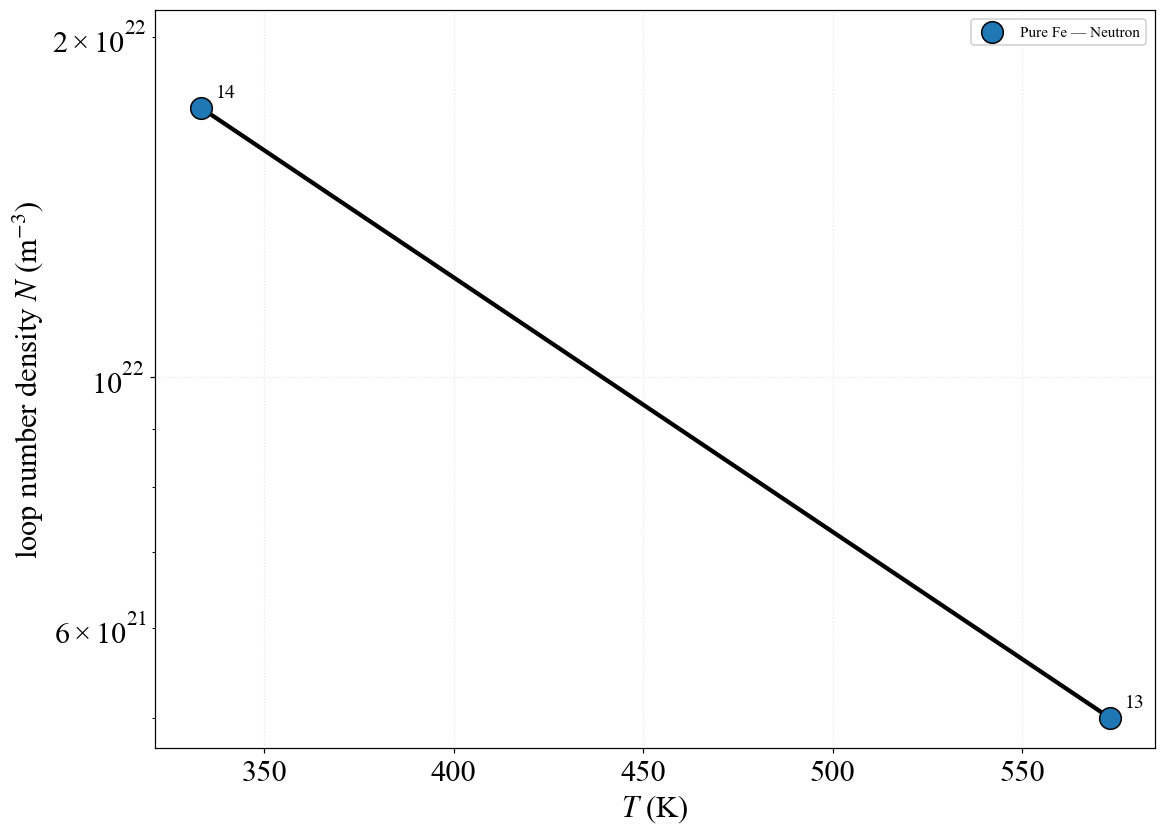

[all data]  n = 2
   geometric mean = 9.306e+21,  GSD = 2.407   |   arithmetic mean = 1.116e+22 +/- 8.71e+21
   ln y = a + b*(T):   a = 52.9309,   b = -0.0051769
   n = 2 -> line exactly determined; residual variance undefined


In [6]:
d = show("loop", "density", "<1 dpa", "T",
         r"loop number density $N$ (m$^{-3}$)", ylog=True)

**Figure 5.1.** Dislocation loop number density versus $T$ (K) for all database entries with dose < 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 2$ points.

Fit (all data): $\ln y = 52.931 -0.0051769\,(T)$ (exactly determined, $n=2$).

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (m⁻³) | Reference |
|---|---|---|---|---|---|---|
| 1 | Pure Fe | Neutron (fission) | 0.79 | 60 / 333 | 1.73e22 | [14] Eldrup 1999 |
| 2 | Pure Fe | Neutron (fission) | 0.19 | 300 / 573 | 5.00e21 | [13] Lambrecht 2009 |

## 5.2 Mean dislocation loop diameter versus $T$ (K), dose < 1 dpa

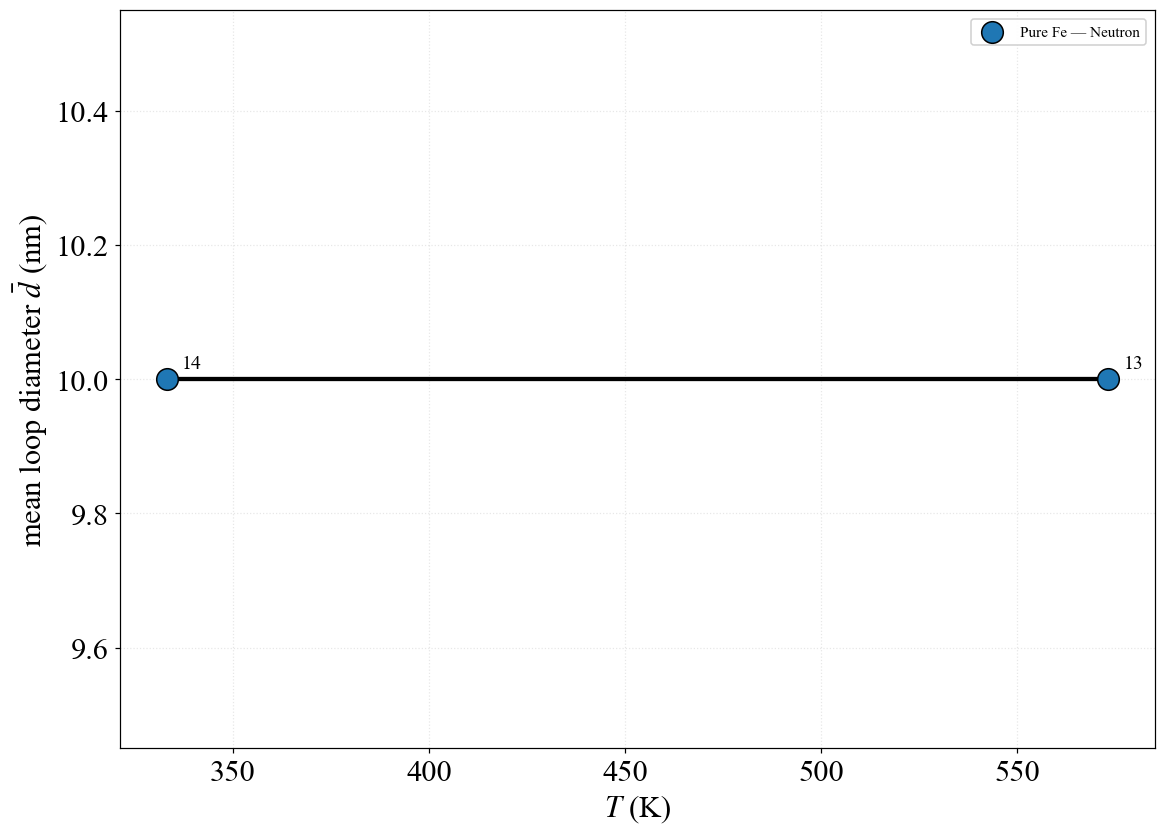

[all data]  n = 2
   geometric mean = 10,  GSD = 1.000   |   arithmetic mean = 10 +/- 0
   ln y = a + b*(T):   a = 2.3026,   b = 1.5839e-18
   n = 2 -> line exactly determined; residual variance undefined


In [7]:
d = show("loop", "size", "<1 dpa", "T",
         r"mean loop diameter $\bar d$ (nm)", ylog=False)

**Figure 5.2.** Mean dislocation loop diameter versus $T$ (K) for all database entries with dose < 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 2$ points.

Fit (all data): $\ln y = 2.303 +1.5839e-18\,(T)$ (exactly determined, $n=2$).

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (nm) | Reference |
|---|---|---|---|---|---|---|
| 1 | Pure Fe | Neutron (fission) | 0.79 | 60 / 333 | 10 | [14] Eldrup 1999 |
| 2 | Pure Fe | Neutron (fission) | 0.19 | 300 / 573 | 10 | [13] Lambrecht 2009 |

## 5.3 Dislocation loop number density versus $T$ (K), dose ≥ 1 dpa

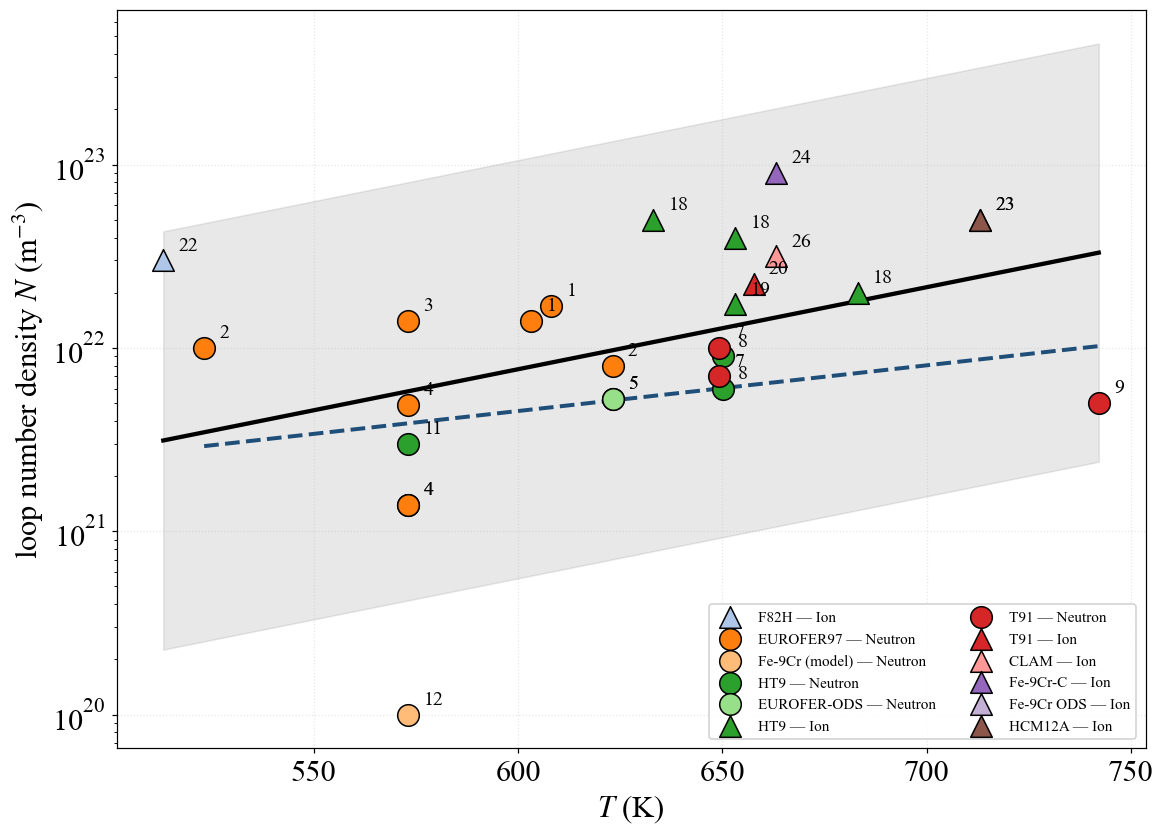

[all data]  n = 27
   geometric mean = 1.011e+22,  GSD = 4.092   |   arithmetic mean = 1.936e+22 +/- 2.09e+22
   ln y = a + b*(T):   a = 44.2091 +/- 2.9147,   b = 0.010301 +/- 0.00463
   residual variance s^2 = 1.7238 (ln-units),  s = 1.3129,   GSD about fit = 3.717,   R^2 = 0.165
[neutron only]  n = 17
   geometric mean = 4.818e+21,  GSD = 3.410   |   arithmetic mean = 7.14e+21 +/- 4.76e+21
   ln y = a + b*(T):   a = 46.4226 +/- 3.7740,   b = 0.0057369 +/- 0.00616
   residual variance s^2 = 1.5176 (ln-units),  s = 1.2319,   GSD about fit = 3.428,   R^2 = 0.055
[ion only]  n = 10
   geometric mean = 3.564e+22,  GSD = 1.663   |   arithmetic mean = 4.013e+22 +/- 2.16e+22
   ln y = a + b*(T):   a = 50.8496 +/- 2.0724,   b = 0.0016471 +/- 0.00316
   residual variance s^2 = 0.2818 (ln-units),  s = 0.5308,   GSD about fit = 1.700,   R^2 = 0.033


In [8]:
d = show("loop", "density", ">=1 dpa", "T",
         r"loop number density $N$ (m$^{-3}$)", ylog=True)

**Figure 5.3.** Dislocation loop number density versus $T$ (K) for all database entries with dose ≥ 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 27$ points, the dashed line the neutron-only fit, and the grey band the $\pm 2s$ (≈95 %) lognormal prediction band.

Fit (all data): $\ln y = 44.209 +0.010301\,(T)$, $s^2 = 1.724$, GSD $= 3.72$, $R^2 = 0.165$.

Fit (neutron only): $\ln y = 46.423 +0.0057369\,(T)$, $s^2 = 1.518$, GSD $= 3.43$, $R^2 = 0.055$.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (m⁻³) | Reference |
|---|---|---|---|---|---|---|
| 1 | F82H | Fe³⁺ | 30 | 300 / 573 / 513 | 3.00e22 | [22] Ando 2018 |
| 2 | EUROFER97 | Neutron (fast) | 16.3 | 250 / 523 | 1.00e22 | [2] Gaganidze 2011 |
| 3 | EUROFER97 | Neutron (mixed spect.) | 15 | 300 / 573 | 1.40e22 | [3] Gaganidze 2016 |
| 4 | EUROFER97 | Neutron (fast) | 15 | 300 / 573 | 1.40e21 | [4] Dethloff 2016 |
| 5 | EUROFER97 | Neutron (fast) | 15 | 300 / 573 | 4.90e21 | [4] Dethloff 2016 |
| 6 | EUROFER97 | Neutron (fast) | 15 | 300 / 573 | 1.40e21 | [4] Dethloff 2016 |
| 7 | Fe-9Cr (model) | Neutron (fission) | 2 | 300 / 573 | 1.00e20 | [12] Lambrecht 2014 |
| 8 | HT9 | Neutron (fast) | 4.02 | 300 / 573 | 3.00e21 | [11] Yan 2021 |
| 9 | EUROFER97 | Neutron (fast) | 15 | 330 / 603 | 1.40e22 | [1] Klimenkov 2012 |
| 10 | EUROFER97 | Neutron (fast) | 32 | 335 / 608 | 1.70e22 | [1] Klimenkov 2012 |
| 11 | EUROFER-ODS | Neutron (fast) | 16.3 | 350 / 623 | 5.29e21 | [5] Klimenkov 2017 |
| 12 | EUROFER-ODS | Neutron (fast) | 16.3 | 350 / 623 | 5.29e21 | [5] Klimenkov 2017 |
| 13 | EUROFER97 | Neutron (fast) | 16.3 | 350 / 623 | 8.00e21 | [2] Gaganidze 2011 |
| 14 | HT9 | Kr⁺ | 4 | 420 / 693 / 633 | 5.00e22 | [18] Zheng 2018 |
| 15 | T91 | Neutron (fast) | 15.4 | 376 / 649 | 1.00e22 | [7] Gao 2018 |
| 16 | T91 | Neutron (fast) | 35.1 | 376 / 649 | 7.00e21 | [7] Gao 2018 |
| 17 | HT9 | Neutron (fast) | 17.1 | 377 / 650 | 9.00e21 | [8] Gao 2019 |
| 18 | HT9 | Neutron (fast) | 35.1 | 377 / 650 | 6.00e21 | [8] Gao 2019 |
| 19 | HT9 | Kr⁺ | 4 | 440 / 713 / 653 | 4.00e22 | [18] Zheng 2018 |
| 20 | HT9 | Fe⁺⁺ | 140 | 440 / 713 / 653 | 1.73e22 | [19] Toloczko 2015 |
| 21 | T91 | Fe³⁺ + He²⁺ (dual) | 34.5717 | 444 / 718 / 658 | 2.24e22 | [20] Toloczko 2024 |
| 22 | CLAM | Fe + He (dual) | 11 | 450 / 723 / 663 | 3.16e22 | [26] Liu 2023 |
| 23 | Fe-9Cr-C | Fe¹³⁺ | 3 | 450 / 723 / 663 | 9.00e22 | [24] Jiang 2024 |
| 24 | HT9 | Kr⁺ | 4 | 470 / 743 / 683 | 2.00e22 | [18] Zheng 2018 |
| 25 | Fe-9Cr ODS | Fe²⁺ | 3 | 500 / 773 / 713 | 5.00e22 | [23] Swenson & Wharry 2018 |
| 26 | HCM12A | Fe²⁺ | 3 | 500 / 773 / 713 | 5.00e22 | [23] Swenson & Wharry 2018 |
| 27 | T91 | Neutron (fast) | 4.3 | 469 / 742 | 5.00e21 | [9] Zhong 2021 |

## 5.4 Mean dislocation loop diameter versus $T$ (K), dose ≥ 1 dpa

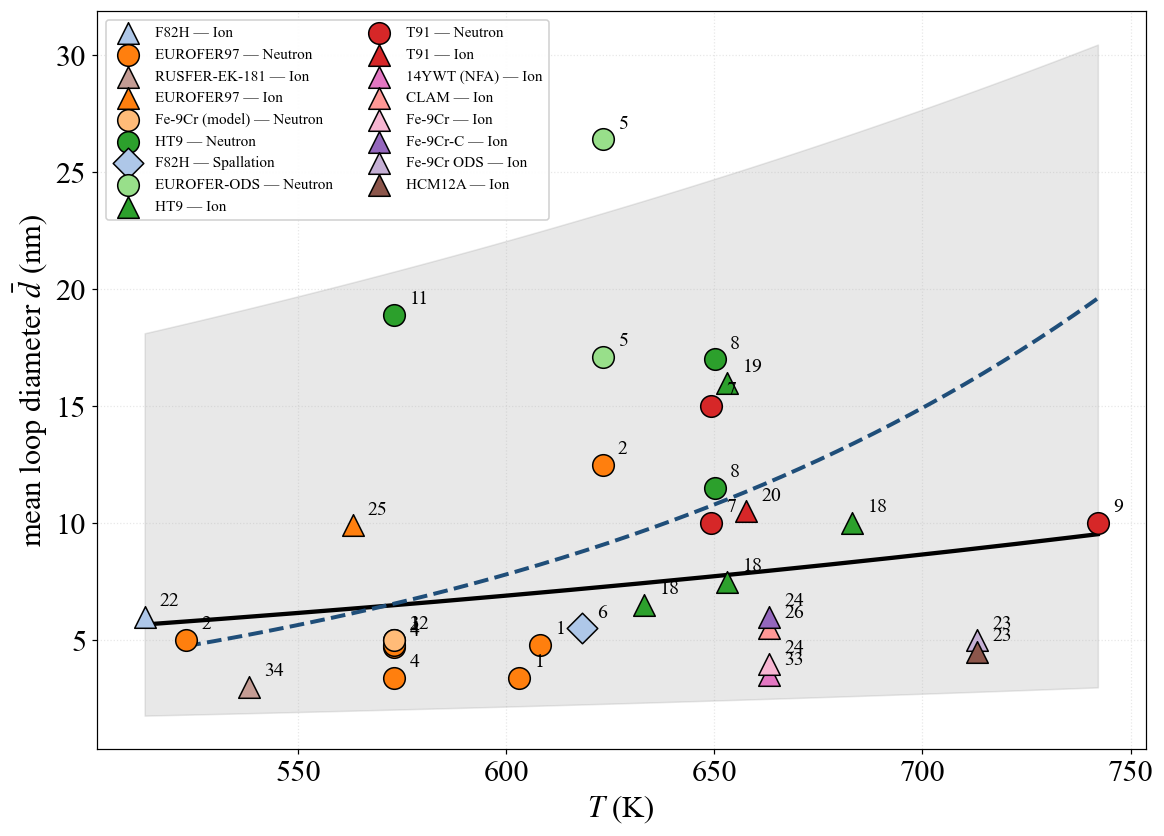

[all data]  n = 32
   geometric mean = 7.292,  GSD = 1.795   |   arithmetic mean = 8.684 +/- 5.62
   ln y = a + b*(T):   a = 0.5708 +/- 1.1823,   b = 0.0022684 +/- 0.00189
   residual variance s^2 = 0.3375 (ln-units),  s = 0.5810,   GSD about fit = 1.788,   R^2 = 0.046
[neutron only]  n = 17
   geometric mean = 8.374,  GSD = 1.940   |   arithmetic mean = 10.26 +/- 6.73
   ln y = a + b*(T):   a = -1.8319 +/- 1.8301,   b = 0.0064784 +/- 0.00299
   residual variance s^2 = 0.3569 (ln-units),  s = 0.5974,   GSD about fit = 1.817,   R^2 = 0.239
[ion only]  n = 14
   geometric mean = 6.29,  GSD = 1.600   |   arithmetic mean = 6.993 +/- 3.54
   ln y = a + b*(T):   a = 1.5650 +/- 1.4382,   b = 0.00042736 +/- 0.00223
   residual variance s^2 = 0.2385 (ln-units),  s = 0.4884,   GSD about fit = 1.630,   R^2 = 0.003


In [9]:
d = show("loop", "size", ">=1 dpa", "T",
         r"mean loop diameter $\bar d$ (nm)", ylog=False)

**Figure 5.4.** Mean dislocation loop diameter versus $T$ (K) for all database entries with dose ≥ 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 32$ points, the dashed line the neutron-only fit, and the grey band the $\pm 2s$ (≈95 %) lognormal prediction band.

Fit (all data): $\ln y = 0.571 +0.0022684\,(T)$, $s^2 = 0.338$, GSD $= 1.79$, $R^2 = 0.046$.

Fit (neutron only): $\ln y = -1.832 +0.0064784\,(T)$, $s^2 = 0.357$, GSD $= 1.82$, $R^2 = 0.239$.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (nm) | Reference |
|---|---|---|---|---|---|---|
| 1 | F82H | Fe³⁺ | 30 | 300 / 573 / 513 | 6 | [22] Ando 2018 |
| 2 | EUROFER97 | Neutron (fast) | 16.3 | 250 / 523 | 5 | [2] Gaganidze 2011 |
| 3 | RUSFER-EK-181 | Fe ion | 6 | 325 / 598 / 538 | 3 | [34] Rogozhkin 2020 |
| 4 | EUROFER97 | Kr²⁺ | 3 | 350 / 623 / 563 | 9.9 | [25] Boulanger & Serruys 2009 |
| 5 | EUROFER97 | Neutron (mixed spect.) | 15 | 300 / 573 | 5 | [3] Gaganidze 2016 |
| 6 | EUROFER97 | Neutron (fast) | 15 | 300 / 573 | 4.7 | [4] Dethloff 2016 |
| 7 | EUROFER97 | Neutron (fast) | 15 | 300 / 573 | 3.4 | [4] Dethloff 2016 |
| 8 | EUROFER97 | Neutron (fast) | 15 | 300 / 573 | 4.8 | [4] Dethloff 2016 |
| 9 | Fe-9Cr (model) | Neutron (fission) | 2 | 300 / 573 | 5 | [12] Lambrecht 2014 |
| 10 | HT9 | Neutron (fast) | 4.02 | 300 / 573 | 18.9 | [11] Yan 2021 |
| 11 | EUROFER97 | Neutron (fast) | 15 | 330 / 603 | 3.4 | [1] Klimenkov 2012 |
| 12 | EUROFER97 | Neutron (fast) | 32 | 335 / 608 | 4.8 | [1] Klimenkov 2012 |
| 13 | F82H | Neutron (spallation) | 20 | 345 / 618 | 5.5 | [6] Wan 2010 |
| 14 | EUROFER-ODS | Neutron (fast) | 16.3 | 350 / 623 | 17.1 | [5] Klimenkov 2017 |
| 15 | EUROFER-ODS | Neutron (fast) | 16.3 | 350 / 623 | 26.4 | [5] Klimenkov 2017 |
| 16 | EUROFER97 | Neutron (fast) | 16.3 | 350 / 623 | 12.5 | [2] Gaganidze 2011 |
| 17 | HT9 | Kr⁺ | 4 | 420 / 693 / 633 | 6.5 | [18] Zheng 2018 |
| 18 | T91 | Neutron (fast) | 15.4 | 376 / 649 | 10 | [7] Gao 2018 |
| 19 | T91 | Neutron (fast) | 35.1 | 376 / 649 | 15 | [7] Gao 2018 |
| 20 | HT9 | Neutron (fast) | 17.1 | 377 / 650 | 11.5 | [8] Gao 2019 |
| 21 | HT9 | Neutron (fast) | 35.1 | 377 / 650 | 17 | [8] Gao 2019 |
| 22 | HT9 | Kr⁺ | 4 | 440 / 713 / 653 | 7.5 | [18] Zheng 2018 |
| 23 | HT9 | Fe⁺⁺ | 140 | 440 / 713 / 653 | 16 | [19] Toloczko 2015 |
| 24 | T91 | Fe³⁺ + He²⁺ (dual) | 34.5717 | 444 / 718 / 658 | 10.5 | [20] Toloczko 2024 |
| 25 | 14YWT (NFA) | Fe⁹⁺ | 21 | 450 / 723 / 663 | 3.5 | [33] Auger 2019 |
| 26 | CLAM | Fe + He (dual) | 11 | 450 / 723 / 663 | 5.5 | [26] Liu 2023 |
| 27 | Fe-9Cr | Fe¹³⁺ | 3 | 450 / 723 / 663 | 4 | [24] Jiang 2024 |
| 28 | Fe-9Cr-C | Fe¹³⁺ | 3 | 450 / 723 / 663 | 6 | [24] Jiang 2024 |
| 29 | HT9 | Kr⁺ | 4 | 470 / 743 / 683 | 10 | [18] Zheng 2018 |
| 30 | Fe-9Cr ODS | Fe²⁺ | 3 | 500 / 773 / 713 | 5 | [23] Swenson & Wharry 2018 |
| 31 | HCM12A | Fe²⁺ | 3 | 500 / 773 / 713 | 4.5 | [23] Swenson & Wharry 2018 |
| 32 | T91 | Neutron (fast) | 4.3 | 469 / 742 | 10 | [9] Zhong 2021 |

---
# 6. Dislocation loop number density — fits versus $1000/T$ (K⁻¹)

Only the **number density** is fitted on the Arrhenius axis. The mean loop
diameter is fitted against $T$ only (Section 5) — an activation energy extracted
from a pooled mean-size/$1000/T$ regression is not physically interpretable here,
so those panels are deliberately not produced.


## 6.1 Dislocation loop number density versus $1000/T$ (K⁻¹), dose < 1 dpa

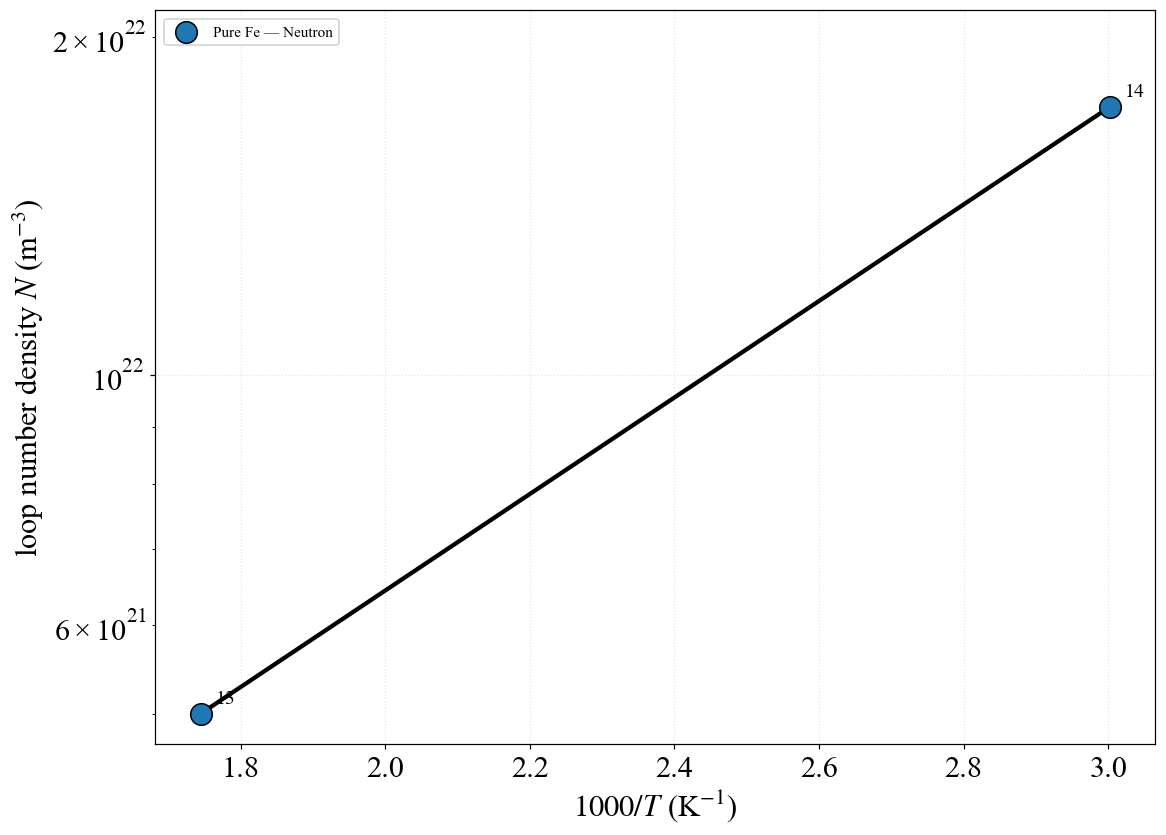

[all data]  n = 2
   geometric mean = 9.306e+21,  GSD = 2.407   |   arithmetic mean = 1.116e+22 +/- 8.71e+21
   ln y = a + b*(1000/T):   a = 48.2390,   b = 0.9885
   n = 2 -> line exactly determined; residual variance undefined
   Arrhenius  y = y0*exp(-E/kT):   E_eff = -0.0852 eV


In [10]:
d = show("loop", "density", "<1 dpa", "invT",
         r"loop number density $N$ (m$^{-3}$)", ylog=True)

**Figure 6.1.** Dislocation loop number density versus $1000/T$ (K⁻¹) for all database entries with dose < 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 2$ points.

Fit (all data): $\ln y = 48.239 +0.9885\,(1000/T)$ (exactly determined, $n=2$), $E_\mathrm{eff} = -0.085$ eV.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (m⁻³) | Reference |
|---|---|---|---|---|---|---|
| 1 | Pure Fe | Neutron (fission) | 0.79 | 60 / 333 | 1.73e22 | [14] Eldrup 1999 |
| 2 | Pure Fe | Neutron (fission) | 0.19 | 300 / 573 | 5.00e21 | [13] Lambrecht 2009 |

## 6.2 Dislocation loop number density versus $1000/T$ (K⁻¹), dose ≥ 1 dpa

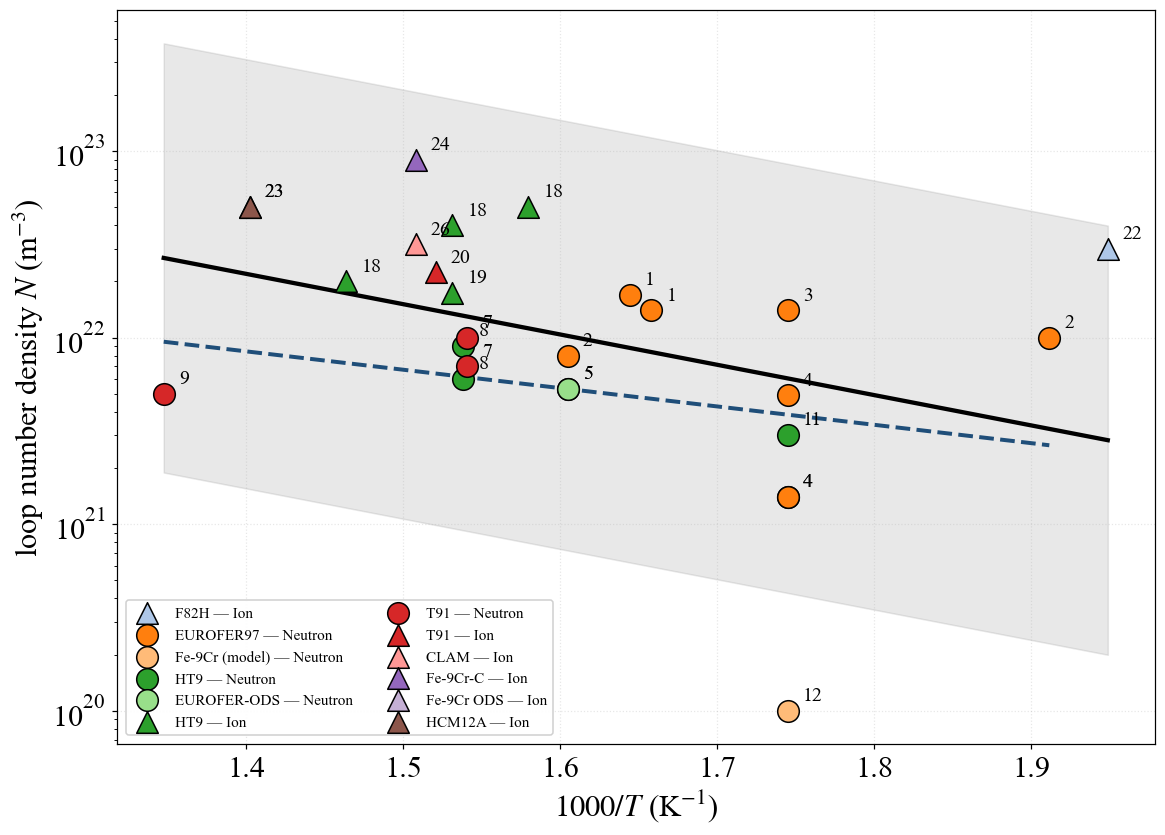

[all data]  n = 27
   geometric mean = 1.011e+22,  GSD = 4.092   |   arithmetic mean = 1.936e+22 +/- 2.09e+22
   ln y = a + b*(1000/T):   a = 56.6802 +/- 2.8634,   b = -3.7408 +/- 1.77
   residual variance s^2 = 1.7533 (ln-units),  s = 1.3241,   GSD about fit = 3.759,   R^2 = 0.151
   Arrhenius  y = y0*exp(-E/kT):   E_eff = +0.3224 eV
[neutron only]  n = 17
   geometric mean = 4.818e+21,  GSD = 3.410   |   arithmetic mean = 7.14e+21 +/- 4.76e+21
   ln y = a + b*(1000/T):   a = 53.6584 +/- 3.9188,   b = -2.2656 +/- 2.37
   residual variance s^2 = 1.5134 (ln-units),  s = 1.2302,   GSD about fit = 3.422,   R^2 = 0.057
   Arrhenius  y = y0*exp(-E/kT):   E_eff = +0.1952 eV
[ion only]  n = 10
   geometric mean = 3.564e+22,  GSD = 1.663   |   arithmetic mean = 4.013e+22 +/- 2.16e+22
   ln y = a + b*(1000/T):   a = 52.7706 +/- 1.7753,   b = -0.5475 +/- 1.15
   residual variance s^2 = 0.2833 (ln-units),  s = 0.5323,   GSD about fit = 1.703,   R^2 = 0.028
   Arrhenius  y = y0*exp(-E/kT):   E_eff

In [11]:
d = show("loop", "density", ">=1 dpa", "invT",
         r"loop number density $N$ (m$^{-3}$)", ylog=True)

**Figure 6.2.** Dislocation loop number density versus $1000/T$ (K⁻¹) for all database entries with dose ≥ 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 27$ points, the dashed line the neutron-only fit, and the grey band the $\pm 2s$ (≈95 %) lognormal prediction band.

Fit (all data): $\ln y = 56.680 -3.7408\,(1000/T)$, $s^2 = 1.753$, GSD $= 3.76$, $R^2 = 0.151$, $E_\mathrm{eff} = +0.322$ eV.

Fit (neutron only): $\ln y = 53.658 -2.2656\,(1000/T)$, $s^2 = 1.513$, GSD $= 3.42$, $R^2 = 0.057$, $E_\mathrm{eff} = +0.195$ eV.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (m⁻³) | Reference |
|---|---|---|---|---|---|---|
| 1 | F82H | Fe³⁺ | 30 | 300 / 573 / 513 | 3.00e22 | [22] Ando 2018 |
| 2 | EUROFER97 | Neutron (fast) | 16.3 | 250 / 523 | 1.00e22 | [2] Gaganidze 2011 |
| 3 | EUROFER97 | Neutron (mixed spect.) | 15 | 300 / 573 | 1.40e22 | [3] Gaganidze 2016 |
| 4 | EUROFER97 | Neutron (fast) | 15 | 300 / 573 | 1.40e21 | [4] Dethloff 2016 |
| 5 | EUROFER97 | Neutron (fast) | 15 | 300 / 573 | 4.90e21 | [4] Dethloff 2016 |
| 6 | EUROFER97 | Neutron (fast) | 15 | 300 / 573 | 1.40e21 | [4] Dethloff 2016 |
| 7 | Fe-9Cr (model) | Neutron (fission) | 2 | 300 / 573 | 1.00e20 | [12] Lambrecht 2014 |
| 8 | HT9 | Neutron (fast) | 4.02 | 300 / 573 | 3.00e21 | [11] Yan 2021 |
| 9 | EUROFER97 | Neutron (fast) | 15 | 330 / 603 | 1.40e22 | [1] Klimenkov 2012 |
| 10 | EUROFER97 | Neutron (fast) | 32 | 335 / 608 | 1.70e22 | [1] Klimenkov 2012 |
| 11 | EUROFER-ODS | Neutron (fast) | 16.3 | 350 / 623 | 5.29e21 | [5] Klimenkov 2017 |
| 12 | EUROFER-ODS | Neutron (fast) | 16.3 | 350 / 623 | 5.29e21 | [5] Klimenkov 2017 |
| 13 | EUROFER97 | Neutron (fast) | 16.3 | 350 / 623 | 8.00e21 | [2] Gaganidze 2011 |
| 14 | HT9 | Kr⁺ | 4 | 420 / 693 / 633 | 5.00e22 | [18] Zheng 2018 |
| 15 | T91 | Neutron (fast) | 15.4 | 376 / 649 | 1.00e22 | [7] Gao 2018 |
| 16 | T91 | Neutron (fast) | 35.1 | 376 / 649 | 7.00e21 | [7] Gao 2018 |
| 17 | HT9 | Neutron (fast) | 17.1 | 377 / 650 | 9.00e21 | [8] Gao 2019 |
| 18 | HT9 | Neutron (fast) | 35.1 | 377 / 650 | 6.00e21 | [8] Gao 2019 |
| 19 | HT9 | Kr⁺ | 4 | 440 / 713 / 653 | 4.00e22 | [18] Zheng 2018 |
| 20 | HT9 | Fe⁺⁺ | 140 | 440 / 713 / 653 | 1.73e22 | [19] Toloczko 2015 |
| 21 | T91 | Fe³⁺ + He²⁺ (dual) | 34.5717 | 444 / 718 / 658 | 2.24e22 | [20] Toloczko 2024 |
| 22 | CLAM | Fe + He (dual) | 11 | 450 / 723 / 663 | 3.16e22 | [26] Liu 2023 |
| 23 | Fe-9Cr-C | Fe¹³⁺ | 3 | 450 / 723 / 663 | 9.00e22 | [24] Jiang 2024 |
| 24 | HT9 | Kr⁺ | 4 | 470 / 743 / 683 | 2.00e22 | [18] Zheng 2018 |
| 25 | Fe-9Cr ODS | Fe²⁺ | 3 | 500 / 773 / 713 | 5.00e22 | [23] Swenson & Wharry 2018 |
| 26 | HCM12A | Fe²⁺ | 3 | 500 / 773 / 713 | 5.00e22 | [23] Swenson & Wharry 2018 |
| 27 | T91 | Neutron (fast) | 4.3 | 469 / 742 | 5.00e21 | [9] Zhong 2021 |

---
# 7. Voids and cavities — fits versus $T$ (K)

## 7.1 Void / cavity number density versus $T$ (K), dose < 1 dpa

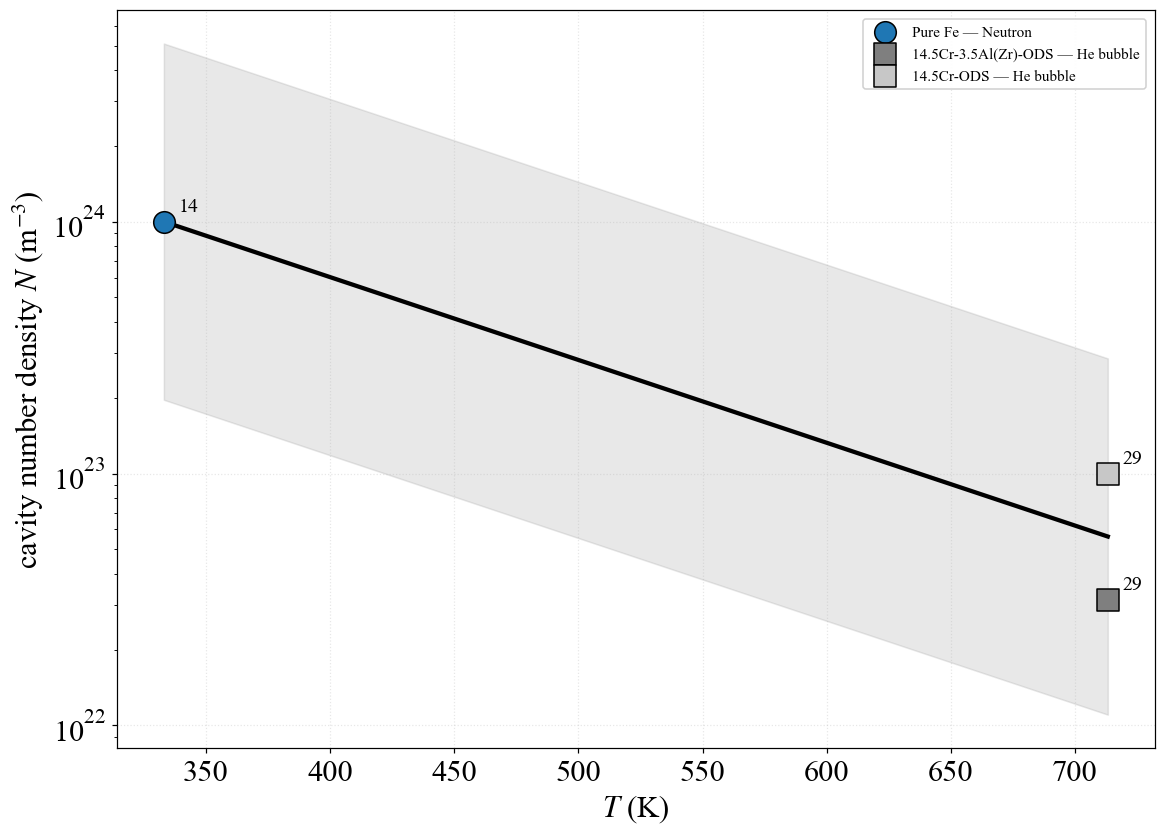

[all data]  n = 3
   geometric mean = 1.468e+23,  GSD = 5.804   |   arithmetic mean = 3.772e+23 +/- 5.4e+23
   ln y = a + b*(T):   a = 57.7854 +/- 1.6090,   b = -0.0075743 +/- 0.00262
   residual variance s^2 = 0.6627 (ln-units),  s = 0.8141,   GSD about fit = 2.257,   R^2 = 0.893
[neutron only]  n = 1
   geometric mean = 1e+24   |   arithmetic mean = 1e+24
   fewer than 2 points or no temperature spread -> no fit
[voids only (He-bubble rows excluded)]  n = 1
   geometric mean = 1e+24   |   arithmetic mean = 1e+24
   fewer than 2 points or no temperature spread -> no fit


In [12]:
d = show("void", "density", "<1 dpa", "T",
         r"cavity number density $N$ (m$^{-3}$)", ylog=True)

**Figure 7.1.** Void / cavity number density versus $T$ (K) for all database entries with dose < 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 3$ points, and the grey band the $\pm 2s$ (≈95 %) lognormal prediction band.

Fit (all data): $\ln y = 57.785 -0.0075743\,(T)$, $s^2 = 0.663$, GSD $= 2.26$, $R^2 = 0.893$.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (m⁻³) | Reference |
|---|---|---|---|---|---|---|
| 1 | Pure Fe | Neutron (fission) | 0.79 | 60 / 333 | 1.00e24 | [14] Eldrup 1999 |
| 2 | 14.5Cr-3.5Al(Zr)-ODS | Single He⁺ | 0.2 | 500 / 773 / 713 | 3.16e22 | [29] Yutani 2007 / Kimura group |
| 3 | 14.5Cr-ODS | Single He⁺ | 0.2 | 500 / 773 / 713 | 1.00e23 | [29] Yutani 2007 |

## 7.2 Mean void / cavity diameter versus $T$ (K), dose < 1 dpa

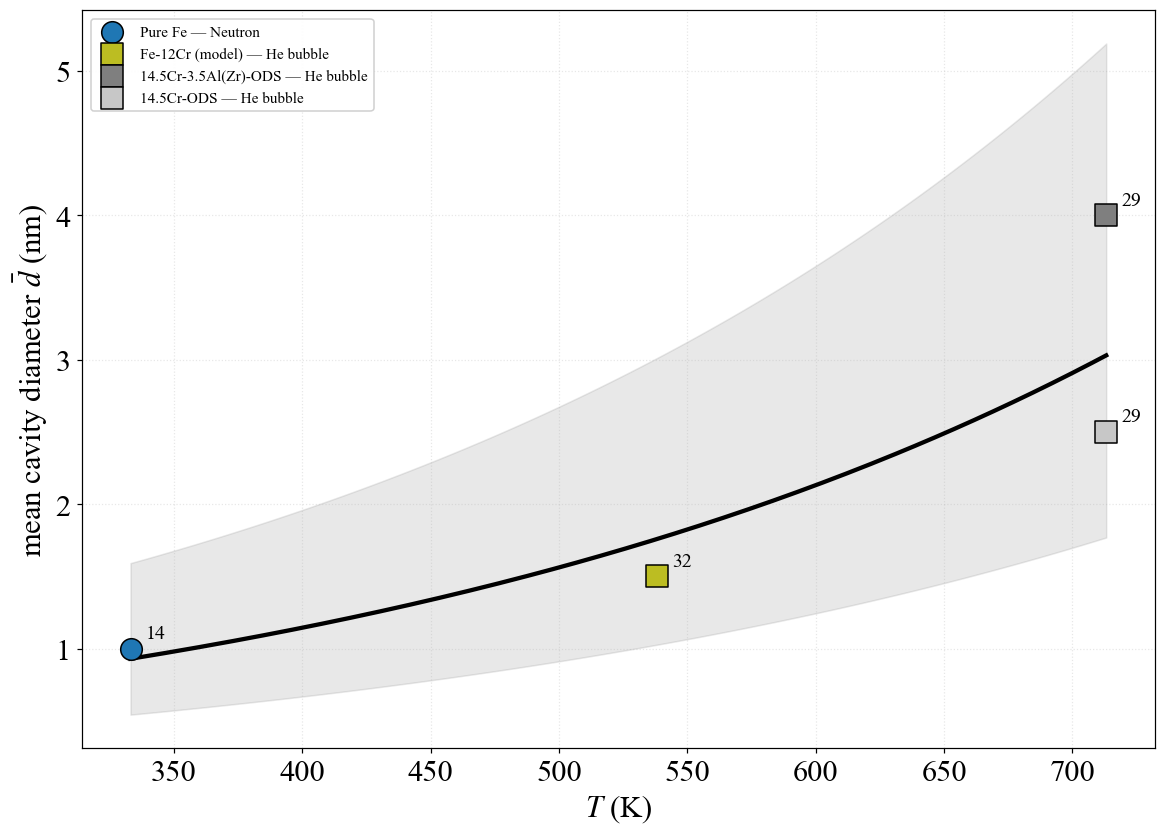

[all data]  n = 4
   geometric mean = 1.968,  GSD = 1.828   |   arithmetic mean = 2.25 +/- 1.32
   ln y = a + b*(T):   a = -1.1091 +/- 0.5115,   b = 0.0031095 +/- 0.000859
   residual variance s^2 = 0.0723 (ln-units),  s = 0.2690,   GSD about fit = 1.309,   R^2 = 0.868
[neutron only]  n = 1
   geometric mean = 1   |   arithmetic mean = 1
   fewer than 2 points or no temperature spread -> no fit
[voids only (He-bubble rows excluded)]  n = 1
   geometric mean = 1   |   arithmetic mean = 1
   fewer than 2 points or no temperature spread -> no fit


In [13]:
d = show("void", "size", "<1 dpa", "T",
         r"mean cavity diameter $\bar d$ (nm)", ylog=False)

**Figure 7.2.** Mean void / cavity diameter versus $T$ (K) for all database entries with dose < 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 4$ points, and the grey band the $\pm 2s$ (≈95 %) lognormal prediction band.

Fit (all data): $\ln y = -1.109 +0.0031095\,(T)$, $s^2 = 0.072$, GSD $= 1.31$, $R^2 = 0.868$.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (nm) | Reference |
|---|---|---|---|---|---|---|
| 1 | Pure Fe | Neutron (fission) | 0.79 | 60 / 333 | 1 | [14] Eldrup 1999 |
| 2 | Fe-12Cr (model) | Single He⁺ | <1 | 325 / 598 / 538 | 1.5 | [32] Schroeder & Trinkaus 1986 |
| 3 | 14.5Cr-3.5Al(Zr)-ODS | Single He⁺ | 0.2 | 500 / 773 / 713 | 4 | [29] Yutani 2007 / Kimura group |
| 4 | 14.5Cr-ODS | Single He⁺ | 0.2 | 500 / 773 / 713 | 2.5 | [29] Yutani 2007 |

## 7.3 Void / cavity number density versus $T$ (K), dose ≥ 1 dpa

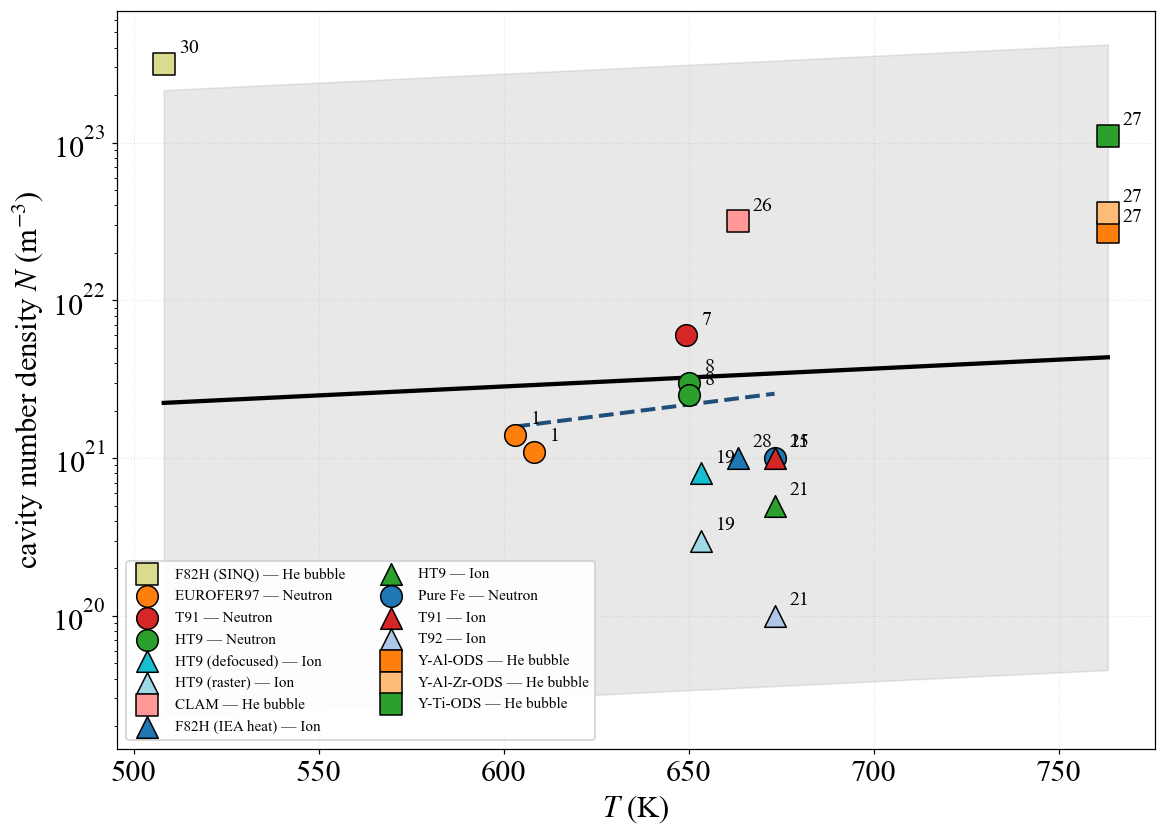

[all data]  n = 17
   geometric mean = 3.361e+21,  GSD = 9.168   |   arithmetic mean = 3.174e+22 +/- 7.83e+22
   ln y = a + b*(T):   a = 47.8343 +/- 6.1196,   b = 0.0026096 +/- 0.00918
   residual variance s^2 = 5.2086 (ln-units),  s = 2.2822,   GSD about fit = 9.799,   R^2 = 0.005
[neutron only]  n = 6
   geometric mean = 2.027e+21,  GSD = 1.995   |   arithmetic mean = 2.5e+21 +/- 1.89e+21
   ln y = a + b*(T):   a = 44.6837 +/- 7.7552,   b = 0.0068499 +/- 0.0121
   residual variance s^2 = 0.5522 (ln-units),  s = 0.7431,   GSD about fit = 2.103,   R^2 = 0.074
[ion only]  n = 6
   geometric mean = 4.785e+20,  GSD = 2.452   |   arithmetic mean = 6.167e+20 +/- 3.76e+20
   ln y = a + b*(T):   a = 59.0539 +/- 29.7793,   b = -0.017203 +/- 0.0448
   residual variance s^2 = 0.9696 (ln-units),  s = 0.9847,   GSD about fit = 2.677,   R^2 = 0.036
[voids only (He-bubble rows excluded)]  n = 12
   geometric mean = 9.848e+20,  GSD = 2.923   |   arithmetic mean = 1.558e+21 +/- 1.63e+21
   ln y = a + 

In [14]:
d = show("void", "density", ">=1 dpa", "T",
         r"cavity number density $N$ (m$^{-3}$)", ylog=True)

**Figure 7.3.** Void / cavity number density versus $T$ (K) for all database entries with dose ≥ 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 17$ points, the dashed line the neutron-only fit, and the grey band the $\pm 2s$ (≈95 %) lognormal prediction band.

Fit (all data): $\ln y = 47.834 +0.0026096\,(T)$, $s^2 = 5.209$, GSD $= 9.80$, $R^2 = 0.005$.

Fit (neutron only): $\ln y = 44.684 +0.0068499\,(T)$, $s^2 = 0.552$, GSD $= 2.10$, $R^2 = 0.074$.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (m⁻³) | Reference |
|---|---|---|---|---|---|---|
| 1 | F82H (SINQ) | Spallation (n+p+He) | 14.4817 | 235 / 508 | 3.16e23 | [30] Dai 2004 |
| 2 | EUROFER97 | Neutron (fast) | 15 | 330 / 603 | 1.40e21 | [1] Klimenkov 2012 |
| 3 | EUROFER97 | Neutron (fast) | 32 | 335 / 608 | 1.10e21 | [1] Klimenkov 2012 |
| 4 | T91 | Neutron (fast) | 35.1 | 376 / 649 | 6.00e21 | [7] Gao 2018 |
| 5 | HT9 | Neutron (fast) | 17.1 | 377 / 650 | 3.00e21 | [8] Gao 2019 |
| 6 | HT9 | Neutron (fast) | 35.1 | 377 / 650 | 2.50e21 | [8] Gao 2019 |
| 7 | HT9 (defocused) | Fe⁺⁺ | 140 | 440 / 713 / 653 | 8.00e20 | [19] Toloczko 2015 |
| 8 | HT9 (raster) | Fe⁺⁺ | 140 | 440 / 713 / 653 | 3.00e20 | [19] Toloczko 2015 |
| 9 | CLAM | Dual Fe+He | 11 | 450 / 723 / 663 | 3.16e22 | [26] Liu 2023 |
| 10 | F82H (IEA heat) | Fe + He + H (triple) | 31.6228 | 450 / 723 / 663 | 1.00e21 | [28] Wakai 2002 |
| 11 | HT9 | Fe⁺⁺ | 220.794 | 460 / 733 / 673 | 5.00e20 | [21] Getto 2015 (Gao/Was group) |
| 12 | Pure Fe | Neutron (fission) | 1 | 400 / 673 | 1.00e21 | [15] English 1982 |
| 13 | T91 | Fe⁺⁺ | 220.794 | 460 / 733 / 673 | 1.00e21 | [21] Getto 2015 |
| 14 | T92 | Fe⁺⁺ | 220.794 | 460 / 733 / 673 | 1.00e20 | [21] Getto 2015 |
| 15 | Y-Al-ODS | Dual Fe+He | 30 | 550 / 823 / 763 | 2.70e22 | [27] Song 2018 |
| 16 | Y-Al-Zr-ODS | Dual Fe+He | 30 | 550 / 823 / 763 | 3.60e22 | [27] Song 2018 |
| 17 | Y-Ti-ODS | Dual Fe+He | 30 | 550 / 823 / 763 | 1.10e23 | [27] Song 2018 |

## 7.4 Mean void / cavity diameter versus $T$ (K), dose ≥ 1 dpa

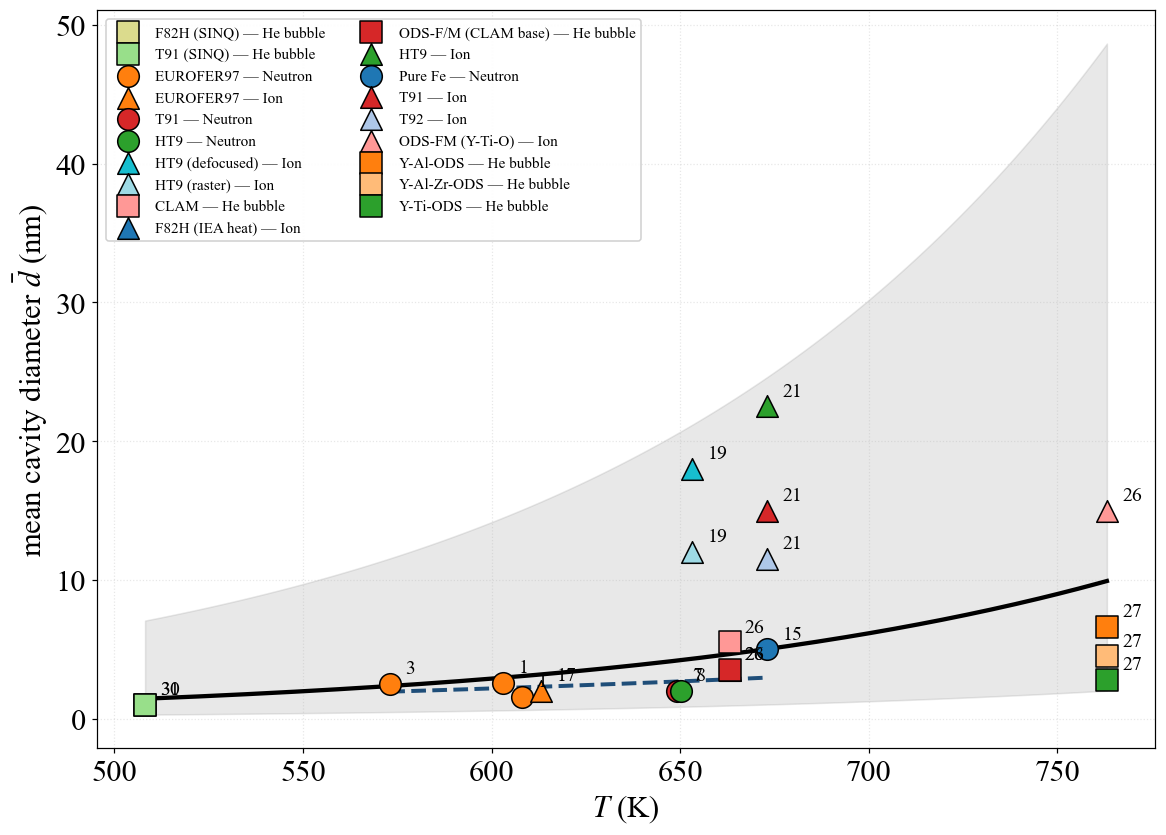

[all data]  n = 21
   geometric mean = 4.378,  GSD = 2.582   |   arithmetic mean = 6.671 +/- 6.34
   ln y = a + b*(T):   a = -3.4767 +/- 1.6172,   b = 0.0075628 +/- 0.00245
   residual variance s^2 = 0.6318 (ln-units),  s = 0.7949,   GSD about fit = 2.214,   R^2 = 0.333
[neutron only]  n = 6
   geometric mean = 2.434,  GSD = 1.483   |   arithmetic mean = 2.617 +/- 1.22
   ln y = a + b*(T):   a = -1.7332 +/- 3.0360,   b = 0.0041888 +/- 0.00484
   residual variance s^2 = 0.1635 (ln-units),  s = 0.4044,   GSD about fit = 1.498,   R^2 = 0.158
[ion only]  n = 8
   geometric mean = 9.842,  GSD = 2.343   |   arithmetic mean = 12.44 +/- 6.92
   ln y = a + b*(T):   a = -4.5447 +/- 4.7555,   b = 0.010186 +/- 0.00708
   residual variance s^2 = 0.6288 (ln-units),  s = 0.7930,   GSD about fit = 2.210,   R^2 = 0.257
[voids only (He-bubble rows excluded)]  n = 14
   geometric mean = 5.408,  GSD = 2.671   |   arithmetic mean = 8.229 +/- 7.2
   ln y = a + b*(T):   a = -7.4785 +/- 3.1473,   b = 0.014068

In [15]:
d = show("void", "size", ">=1 dpa", "T",
         r"mean cavity diameter $\bar d$ (nm)", ylog=False)

**Figure 7.4.** Mean void / cavity diameter versus $T$ (K) for all database entries with dose ≥ 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 21$ points, the dashed line the neutron-only fit, and the grey band the $\pm 2s$ (≈95 %) lognormal prediction band.

Fit (all data): $\ln y = -3.477 +0.0075628\,(T)$, $s^2 = 0.632$, GSD $= 2.21$, $R^2 = 0.333$.

Fit (neutron only): $\ln y = -1.733 +0.0041888\,(T)$, $s^2 = 0.164$, GSD $= 1.50$, $R^2 = 0.158$.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (nm) | Reference |
|---|---|---|---|---|---|---|
| 1 | F82H (SINQ) | Spallation (n+p+He) | 14.4817 | 235 / 508 | 1 | [30] Dai 2004 |
| 2 | T91 (SINQ) | Spallation (n+p+He) | 11.8 | 235 / 508 | 1 | [31] Jia 2005 |
| 3 | EUROFER97 | Neutron (mixed spect.) | 15 | 300 / 573 | 2.5 | [3] Gaganidze 2016 |
| 4 | EUROFER97 | Neutron (fast) | 15 | 330 / 603 | 2.6 | [1] Klimenkov 2012 |
| 5 | EUROFER97 | Neutron (fast) | 32 | 335 / 608 | 1.6 | [1] Klimenkov 2012 |
| 6 | EUROFER97 | Ion (Fe³⁺, dual-beam — for comparison) | 26 | 400 / 673 / 613 | 2 | [17] Rouffié 2014 (HAL) |
| 7 | T91 | Neutron (fast) | 15.4 | 376 / 649 | 2 | [7] Gao 2018 |
| 8 | HT9 | Neutron (fast) | 17.1 | 377 / 650 | 2 | [8] Gao 2019 |
| 9 | HT9 (defocused) | Fe⁺⁺ | 140 | 440 / 713 / 653 | 18 | [19] Toloczko 2015 |
| 10 | HT9 (raster) | Fe⁺⁺ | 140 | 440 / 713 / 653 | 12 | [19] Toloczko 2015 |
| 11 | CLAM | Dual Fe+He | 11 | 450 / 723 / 663 | 5.5 | [26] Liu 2023 |
| 12 | F82H (IEA heat) | Fe + He + H (triple) | 31.6228 | 450 / 723 / 663 | 3.5 | [28] Wakai 2002 |
| 13 | ODS-F/M (CLAM base) | Dual Fe+He | 11 | 450 / 723 / 663 | 3.5 | [26] Liu 2023 |
| 14 | HT9 | Fe⁺⁺ | 220.794 | 460 / 733 / 673 | 22.5 | [21] Getto 2015 (Gao/Was group) |
| 15 | Pure Fe | Neutron (fission) | 1 | 400 / 673 | 5 | [15] English 1982 |
| 16 | T91 | Fe⁺⁺ | 220.794 | 460 / 733 / 673 | 15 | [21] Getto 2015 |
| 17 | T92 | Fe⁺⁺ | 220.794 | 460 / 733 / 673 | 11.5 | [21] Getto 2015 |
| 18 | ODS-FM (Y-Ti-O) | Fe²⁺ | 500 | 550 / 823 / 763 | 15 | [26] Liu 2023 |
| 19 | Y-Al-ODS | Dual Fe+He | 30 | 550 / 823 / 763 | 6.6 | [27] Song 2018 |
| 20 | Y-Al-Zr-ODS | Dual Fe+He | 30 | 550 / 823 / 763 | 4.5 | [27] Song 2018 |
| 21 | Y-Ti-ODS | Dual Fe+He | 30 | 550 / 823 / 763 | 2.8 | [27] Song 2018 |

---
# 8. Void / cavity number density — fits versus $1000/T$ (K⁻¹)

As in Section 6, only the **number density** is fitted on the Arrhenius axis;
the mean cavity diameter is fitted against $T$ only (Section 7).


## 8.1 Void / cavity number density versus $1000/T$ (K⁻¹), dose < 1 dpa

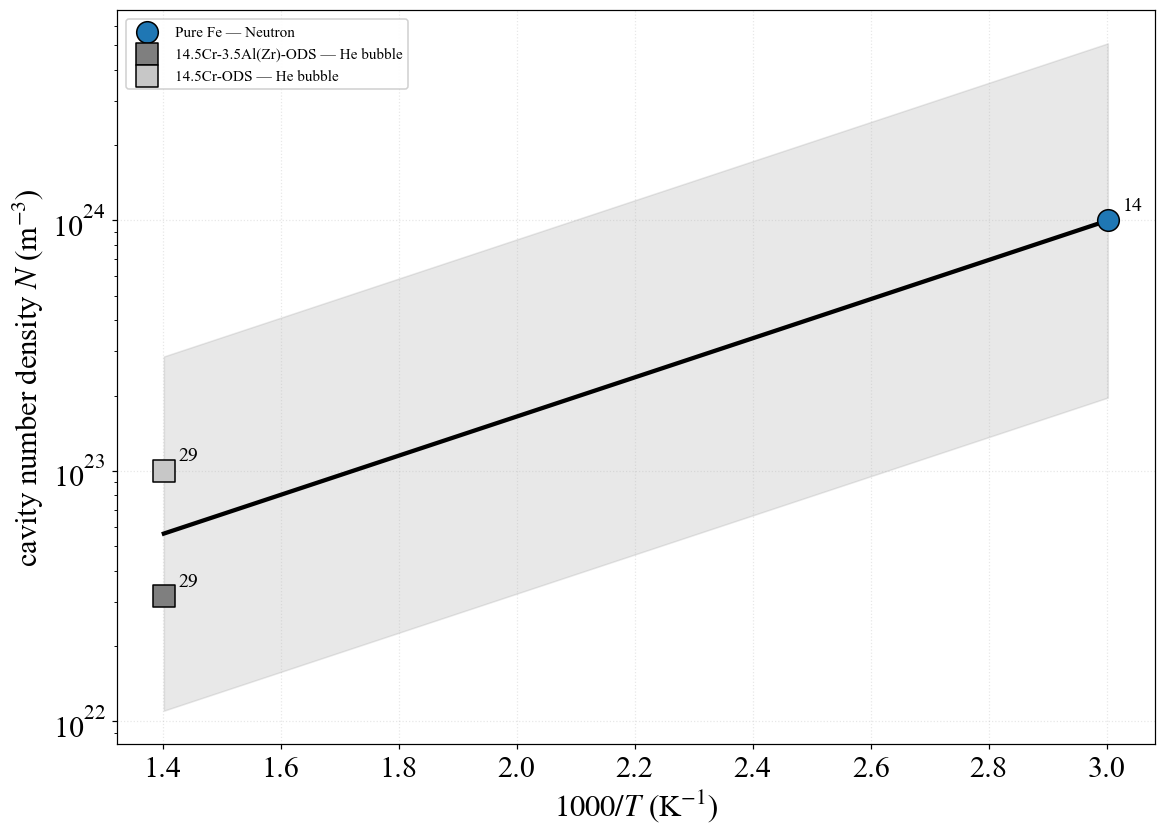

[all data]  n = 3
   geometric mean = 1.468e+23,  GSD = 5.804   |   arithmetic mean = 3.772e+23 +/- 5.4e+23
   ln y = a + b*(1000/T):   a = 49.8604 +/- 1.2948,   b = 1.7995 +/- 0.623
   residual variance s^2 = 0.6627 (ln-units),  s = 0.8141,   GSD about fit = 2.257,   R^2 = 0.893
   Arrhenius  y = y0*exp(-E/kT):   E_eff = -0.1551 eV
[neutron only]  n = 1
   geometric mean = 1e+24   |   arithmetic mean = 1e+24
   fewer than 2 points or no temperature spread -> no fit
[voids only (He-bubble rows excluded)]  n = 1
   geometric mean = 1e+24   |   arithmetic mean = 1e+24
   fewer than 2 points or no temperature spread -> no fit


In [16]:
d = show("void", "density", "<1 dpa", "invT",
         r"cavity number density $N$ (m$^{-3}$)", ylog=True)

**Figure 8.1.** Void / cavity number density versus $1000/T$ (K⁻¹) for all database entries with dose < 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 3$ points, and the grey band the $\pm 2s$ (≈95 %) lognormal prediction band.

Fit (all data): $\ln y = 49.860 +1.7995\,(1000/T)$, $s^2 = 0.663$, GSD $= 2.26$, $R^2 = 0.893$, $E_\mathrm{eff} = -0.155$ eV.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (m⁻³) | Reference |
|---|---|---|---|---|---|---|
| 1 | Pure Fe | Neutron (fission) | 0.79 | 60 / 333 | 1.00e24 | [14] Eldrup 1999 |
| 2 | 14.5Cr-3.5Al(Zr)-ODS | Single He⁺ | 0.2 | 500 / 773 / 713 | 3.16e22 | [29] Yutani 2007 / Kimura group |
| 3 | 14.5Cr-ODS | Single He⁺ | 0.2 | 500 / 773 / 713 | 1.00e23 | [29] Yutani 2007 |

## 8.2 Void / cavity number density versus $1000/T$ (K⁻¹), dose ≥ 1 dpa

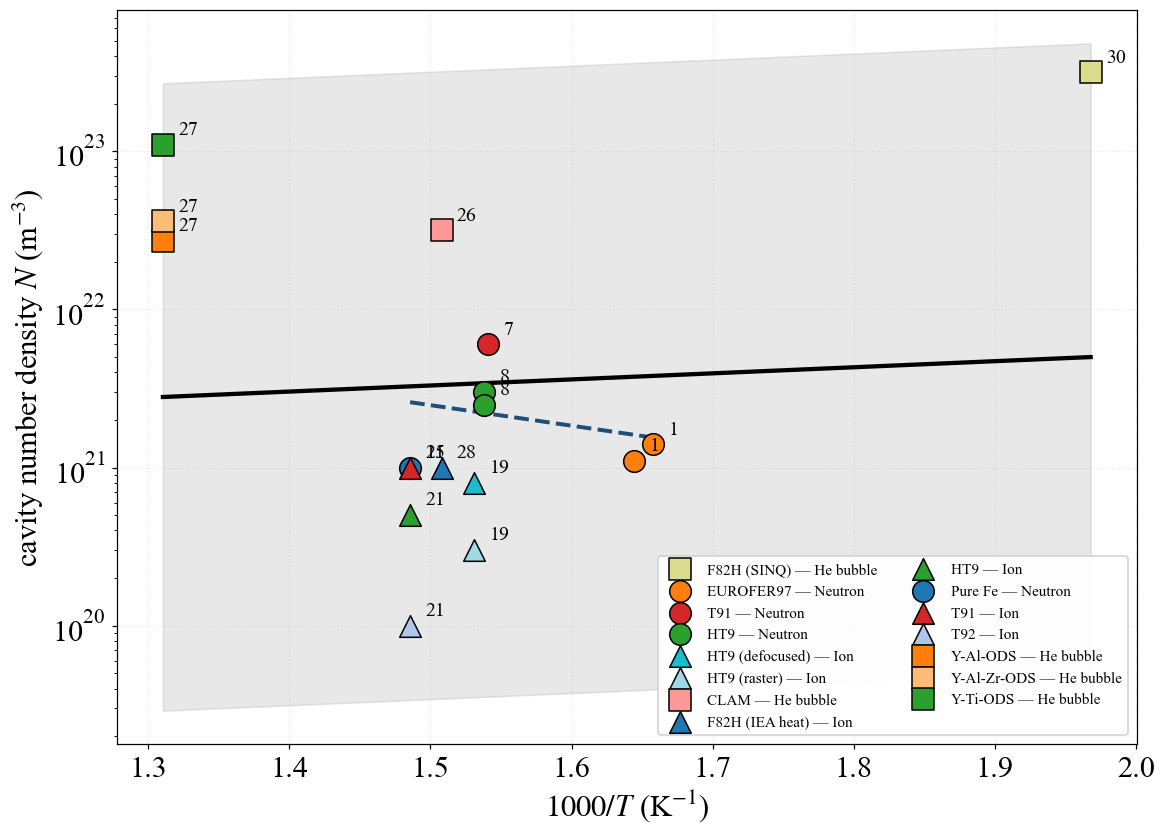

[all data]  n = 17
   geometric mean = 3.361e+21,  GSD = 9.168   |   arithmetic mean = 3.174e+22 +/- 7.83e+22
   ln y = a + b*(1000/T):   a = 48.2216 +/- 5.7087,   b = 0.88476 +/- 3.74
   residual variance s^2 = 5.2171 (ln-units),  s = 2.2841,   GSD about fit = 9.817,   R^2 = 0.004
   Arrhenius  y = y0*exp(-E/kT):   E_eff = -0.0762 eV
[neutron only]  n = 6
   geometric mean = 2.027e+21,  GSD = 1.995   |   arithmetic mean = 2.5e+21 +/- 1.89e+21
   ln y = a + b*(1000/T):   a = 53.7479 +/- 7.5882,   b = -2.9904 +/- 4.84
   residual variance s^2 = 0.5443 (ln-units),  s = 0.7378,   GSD about fit = 2.091,   R^2 = 0.087
   Arrhenius  y = y0*exp(-E/kT):   E_eff = +0.2577 eV
[ion only]  n = 6
   geometric mean = 4.785e+20,  GSD = 2.452   |   arithmetic mean = 6.167e+20 +/- 3.76e+20
   ln y = a + b*(1000/T):   a = 36.3790 +/- 29.6577,   b = 7.4699 +/- 19.7
   residual variance s^2 = 0.9705 (ln-units),  s = 0.9851,   GSD about fit = 2.678,   R^2 = 0.035
   Arrhenius  y = y0*exp(-E/kT):   E_eff = 

In [17]:
d = show("void", "density", ">=1 dpa", "invT",
         r"cavity number density $N$ (m$^{-3}$)", ylog=True)

**Figure 8.2.** Void / cavity number density versus $1000/T$ (K⁻¹) for all database entries with dose ≥ 1 dpa. Marker colour = material, marker shape = irradiation class (● neutron, ▲ ion, ■ He-bubble measurement, ◆ spallation); ion temperatures are shifted by $-60$ °C onto the neutron-equivalent axis $T_\mathrm{eq}$. The solid line is the log-linear fit to all $n = 17$ points, the dashed line the neutron-only fit, and the grey band the $\pm 2s$ (≈95 %) lognormal prediction band.

Fit (all data): $\ln y = 48.222 +0.88476\,(1000/T)$, $s^2 = 5.217$, GSD $= 9.82$, $R^2 = 0.004$, $E_\mathrm{eff} = -0.076$ eV.

Fit (neutron only): $\ln y = 53.748 -2.9904\,(1000/T)$, $s^2 = 0.544$, GSD $= 2.09$, $R^2 = 0.087$, $E_\mathrm{eff} = +0.258$ eV.

| # | Material | Irradiation source | Dose (dpa) | $T$ (°C / K / $T_\mathrm{eq}$) | Value (m⁻³) | Reference |
|---|---|---|---|---|---|---|
| 1 | F82H (SINQ) | Spallation (n+p+He) | 14.4817 | 235 / 508 | 3.16e23 | [30] Dai 2004 |
| 2 | EUROFER97 | Neutron (fast) | 15 | 330 / 603 | 1.40e21 | [1] Klimenkov 2012 |
| 3 | EUROFER97 | Neutron (fast) | 32 | 335 / 608 | 1.10e21 | [1] Klimenkov 2012 |
| 4 | T91 | Neutron (fast) | 35.1 | 376 / 649 | 6.00e21 | [7] Gao 2018 |
| 5 | HT9 | Neutron (fast) | 17.1 | 377 / 650 | 3.00e21 | [8] Gao 2019 |
| 6 | HT9 | Neutron (fast) | 35.1 | 377 / 650 | 2.50e21 | [8] Gao 2019 |
| 7 | HT9 (defocused) | Fe⁺⁺ | 140 | 440 / 713 / 653 | 8.00e20 | [19] Toloczko 2015 |
| 8 | HT9 (raster) | Fe⁺⁺ | 140 | 440 / 713 / 653 | 3.00e20 | [19] Toloczko 2015 |
| 9 | CLAM | Dual Fe+He | 11 | 450 / 723 / 663 | 3.16e22 | [26] Liu 2023 |
| 10 | F82H (IEA heat) | Fe + He + H (triple) | 31.6228 | 450 / 723 / 663 | 1.00e21 | [28] Wakai 2002 |
| 11 | HT9 | Fe⁺⁺ | 220.794 | 460 / 733 / 673 | 5.00e20 | [21] Getto 2015 (Gao/Was group) |
| 12 | Pure Fe | Neutron (fission) | 1 | 400 / 673 | 1.00e21 | [15] English 1982 |
| 13 | T91 | Fe⁺⁺ | 220.794 | 460 / 733 / 673 | 1.00e21 | [21] Getto 2015 |
| 14 | T92 | Fe⁺⁺ | 220.794 | 460 / 733 / 673 | 1.00e20 | [21] Getto 2015 |
| 15 | Y-Al-ODS | Dual Fe+He | 30 | 550 / 823 / 763 | 2.70e22 | [27] Song 2018 |
| 16 | Y-Al-Zr-ODS | Dual Fe+He | 30 | 550 / 823 / 763 | 3.60e22 | [27] Song 2018 |
| 17 | Y-Ti-ODS | Dual Fe+He | 30 | 550 / 823 / 763 | 1.10e23 | [27] Song 2018 |

---
# 9. Dislocation-loop size distributions

Six full TEM size-distribution histograms are available (`Loop_Size_Distributions`),
covering EUROFER97 and EUROFER-ODS at two irradiation temperatures. They are the only
resolved size distributions in the database; **no void size-distribution histograms exist**
— Figure G.15 of the source document is schematic, and the void data are reported only as
mean diameter plus a unimodal/bimodal label.

Each histogram is renormalised to 100 % and fitted with a **log-normal** number
distribution, the shape identified in Appendix G.8 for loop populations:

$$f(d) \;=\; \frac{1}{d\,\sigma\sqrt{2\pi}}\,
\exp\!\left[-\frac{(\ln d - \mu)^2}{2\sigma^2}\right],$$

with $\mu$ and $\sigma$ obtained by **moment matching** on the measured
fraction-weighted log-diameters (no non-linear optimiser, hence no convergence
failure and no seed sensitivity). The reported statistics are

$$\text{mean } = e^{\mu + \sigma^2/2},\qquad
\text{median } = e^{\mu},\qquad
\text{mode } = e^{\mu - \sigma^2},\qquad
\text{SD } = e^{\mu+\sigma^2/2}\sqrt{e^{\sigma^2}-1},$$

alongside the arithmetic mean and standard deviation computed directly from the histogram.
As a validation, the arithmetic means recovered here reproduce the *Derived mean* column
of the workbook exactly (9.90, 4.68, 3.43, 4.76, 17.12 and 26.39 nm).

Following Figure G.13, one figure is produced **per irradiation temperature**, with all
populations measured at that temperature overlaid.

In [18]:
def load_size_distributions():
    """Six loop-diameter histograms + their metadata, renormalised to 100 % each."""
    raw = pd.read_excel(XLSX, sheet_name="Loop_Size_Distributions", header=None)
    meta = raw.iloc[4:10, 0:11].copy()
    meta.columns = ["dataset", "ref", "material", "irradiation", "T_C", "dose",
                    "population", "sheet_mean_nm", "sheet_std_nm", "nbins", "sum_frac"]
    meta = meta.reset_index(drop=True)
    meta["T_C"] = meta["T_C"].astype(float)
    meta["dose"] = meta["dose"].astype(float)
    hist = {}
    for k, c0 in enumerate([0, 3, 6, 9, 12, 15]):          # six (diameter, fraction) blocks
        block = raw.iloc[15:39, [c0, c0 + 1]].apply(pd.to_numeric, errors="coerce").dropna()
        d = block.iloc[:, 0].to_numpy(float)
        f = block.iloc[:, 1].to_numpy(float)
        hist[meta.loc[k, "dataset"]] = (d, 100.0 * f / f.sum())
    return meta, hist

def lognormal_pdf(d, mu, sig):
    d = np.asarray(d, float)
    out = np.zeros_like(d)
    g = d > 0
    out[g] = np.exp(-(np.log(d[g]) - mu)**2 / (2*sig**2)) / (d[g]*sig*np.sqrt(2*np.pi))
    return out

def fit_lognormal(d, f):
    """Moment-matched lognormal on a loop-diameter histogram (f = per-bin percentage)."""
    w = f / f.sum()
    m1 = float((w*d).sum())
    sd = float(np.sqrt((w*(d - m1)**2).sum()))
    g = d > 0
    lw = w[g] / w[g].sum(); ld = np.log(d[g])
    mu = float((lw*ld).sum())
    sig = float(np.sqrt(max((lw*(ld - mu)**2).sum(), 1e-12)))
    bw = float(np.median(np.diff(np.unique(d)))) if len(np.unique(d)) > 1 else 1.0
    pred = 100.0 * lognormal_pdf(d, mu, sig) * bw
    ss = float(np.sum((f - pred)**2)); tt = float(np.sum((f - f.mean())**2))
    return dict(mu=mu, sig=sig, bw=bw, arith_mean=m1, arith_sd=sd,
                mean=float(np.exp(mu + sig**2/2)), median=float(np.exp(mu)),
                mode=float(np.exp(mu - sig**2)),
                sd_ln=float(np.exp(mu + sig**2/2)*np.sqrt(np.exp(sig**2) - 1)),
                R2=float(1 - ss/tt) if tt > 0 else np.nan)

META, HIST = load_size_distributions()
FITS = {r["dataset"]: fit_lognormal(*HIST[r["dataset"]]) for _, r in META.iterrows()}

tab = pd.DataFrame([{
    "dataset": k, "T (C)": float(META.loc[META.dataset == k, "T_C"].iloc[0]),
    "dose (dpa)": float(META.loc[META.dataset == k, "dose"].iloc[0]),
    "population": META.loc[META.dataset == k, "population"].iloc[0],
    "mu": v["mu"], "sigma": v["sig"], "mean (nm)": v["mean"], "median (nm)": v["median"],
    "mode (nm)": v["mode"], "SD (nm)": v["sd_ln"],
    "hist mean": v["arith_mean"], "hist SD": v["arith_sd"],
    "sheet mean": float(META.loc[META.dataset == k, "sheet_mean_nm"].iloc[0]),
    "R2": v["R2"]} for k, v in FITS.items()])
pd.set_option("display.width", 200, "display.max_columns", 20)
print(tab.round(3).to_string(index=False))

         dataset  T (C)  dose (dpa)               population    mu  sigma  mean (nm)  median (nm)  mode (nm)  SD (nm)  hist mean  hist SD  sheet mean    R2
       350C_3dpa  350.0         3.0                all loops 2.168  0.500      9.908        8.743      6.808    5.282      9.897    5.031        9.90 0.915
300C_15dpa_area1  300.0        15.0 ½⟨111⟩ (Area1, g={3̄10}) 1.418  0.491      4.657        4.128      3.244    2.431      4.680    2.590        4.68 0.985
300C_15dpa_area2  300.0        15.0  ⟨100⟩ (Area2, g={2̄11}) 1.079  0.543      3.410        2.943      2.192    1.996      3.427    2.209        3.43 0.993
300C_15dpa_area3  300.0        15.0  ½⟨111⟩ (Area2, g={200}) 1.414  0.529      4.730        4.112      3.107    2.690      4.762    2.872        4.76 0.966
  350C_16dpa_100  350.0        16.3                    ⟨100⟩ 2.770  0.390     17.217       15.954     13.698    6.986     17.115    6.125       17.12 0.919
  350C_16dpa_111  350.0        16.3                   ½⟨111⟩ 3.1

**Table 9.1 — fitted log-normal parameters for every measured loop size distribution.**

| Dataset | Material | Irradiation | $T$ (°C) | Dose (dpa) | Population | $\mu$ | $\sigma$ | Mean (nm) | Median (nm) | Mode (nm) | SD (nm) | Hist. mean (nm) | Hist. SD (nm) | Reference | $R^2$ |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 350C_3dpa | EUROFER97 | Ion (Kr²⁺, 700 keV) | 350 | 3 | all loops | 2.168 | 0.500 | 9.91 | 8.74 | 6.81 | 5.28 | 9.90 | 5.03 | [25] Boulanger & Serruys 2009 | 0.915 |
| 300C_15dpa_area1 | EUROFER97 | Neutron (BOR-60) | 300 | 15 | ½⟨111⟩ (Area1, g={3̄10}) | 1.418 | 0.491 | 4.66 | 4.13 | 3.24 | 2.43 | 4.68 | 2.59 | [4] Dethloff 2016 | 0.985 |
| 300C_15dpa_area2 | EUROFER97 | Neutron (BOR-60) | 300 | 15 | ⟨100⟩ (Area2, g={2̄11}) | 1.079 | 0.543 | 3.41 | 2.94 | 2.19 | 2.00 | 3.43 | 2.21 | [4] Dethloff 2016 | 0.993 |
| 300C_15dpa_area3 | EUROFER97 | Neutron (BOR-60) | 300 | 15 | ½⟨111⟩ (Area2, g={200}) | 1.414 | 0.529 | 4.73 | 4.11 | 3.11 | 2.69 | 4.76 | 2.87 | [4] Dethloff 2016 | 0.966 |
| 350C_16dpa_100 | EUROFER-ODS | Neutron (BOR-60) | 350 | 16.3 | ⟨100⟩ | 2.770 | 0.390 | 17.22 | 15.95 | 13.70 | 6.99 | 17.12 | 6.12 | [5] Klimenkov 2017 | 0.919 |
| 350C_16dpa_111 | EUROFER-ODS | Neutron (BOR-60) | 350 | 16.3 | ½⟨111⟩ | 3.167 | 0.484 | 26.68 | 23.73 | 18.78 | 13.70 | 26.39 | 12.06 | [5] Klimenkov 2017 | 0.877 |

In [19]:
SDCOL = {"300C_15dpa_area1": "#1f77b4", "300C_15dpa_area2": "#d62728",
         "300C_15dpa_area3": "#2ca02c", "350C_3dpa": "#9467bd",
         "350C_16dpa_100": "#ff7f0e", "350C_16dpa_111": "#8c564b"}

def plot_distributions(T_C):
    """Figure G.13 style: every loop size distribution measured at one temperature."""
    sel = META[np.isclose(META["T_C"].astype(float), T_C)]
    fig, ax = plt.subplots(figsize=(11, 8))
    for _, m in sel.iterrows():
        k = m["dataset"]
        d, f = HIST[k]
        v = FITS[k]
        c = SDCOL.get(k, "k")
        ax.step(d, f, where="mid", color=c, lw=2.0, alpha=0.55)
        ax.scatter(d, f, s=90, color=c, edgecolors="k", linewidths=0.7, zorder=3,
                   label=f"[{ref_no(m['ref'])}] {m['material']}, {m['dose']:g} dpa, "
                         f"{texify(m['population'])}")
        dg = np.linspace(max(d.min()*0.5, 0.2), d.max()*1.15, 400)
        ax.plot(dg, 100.0*lognormal_pdf(dg, v["mu"], v["sig"])*v["bw"], color=c, lw=3.0,
                zorder=4)
        ax.axvline(v["mean"], color=c, ls=":", lw=1.8, alpha=0.8)
    ax.set_xlabel(r"loop diameter $d$ (nm)")
    ax.set_ylabel(r"loop number fraction per bin (%)")
    ax.set_xlim(left=0)
    ax.grid(alpha=0.3, ls=":")
    place_legend_inside(ax)
    fig.tight_layout()
    plt.show()
    for _, m in sel.iterrows():
        v = FITS[m["dataset"]]
        print(f"{m['dataset']:>18s} | {m['population']:>26s} | "
              f"mu={v['mu']:.4f}  sigma={v['sig']:.4f} | mean={v['mean']:6.2f} nm  "
              f"median={v['median']:6.2f}  mode={v['mode']:6.2f}  SD={v['sd_ln']:5.2f} | "
              f"hist mean={v['arith_mean']:6.2f}  hist SD={v['arith_sd']:5.2f} | "
              f"R2={v['R2']:.3f}")

## 9.1 Loop size distributions at 300 °C

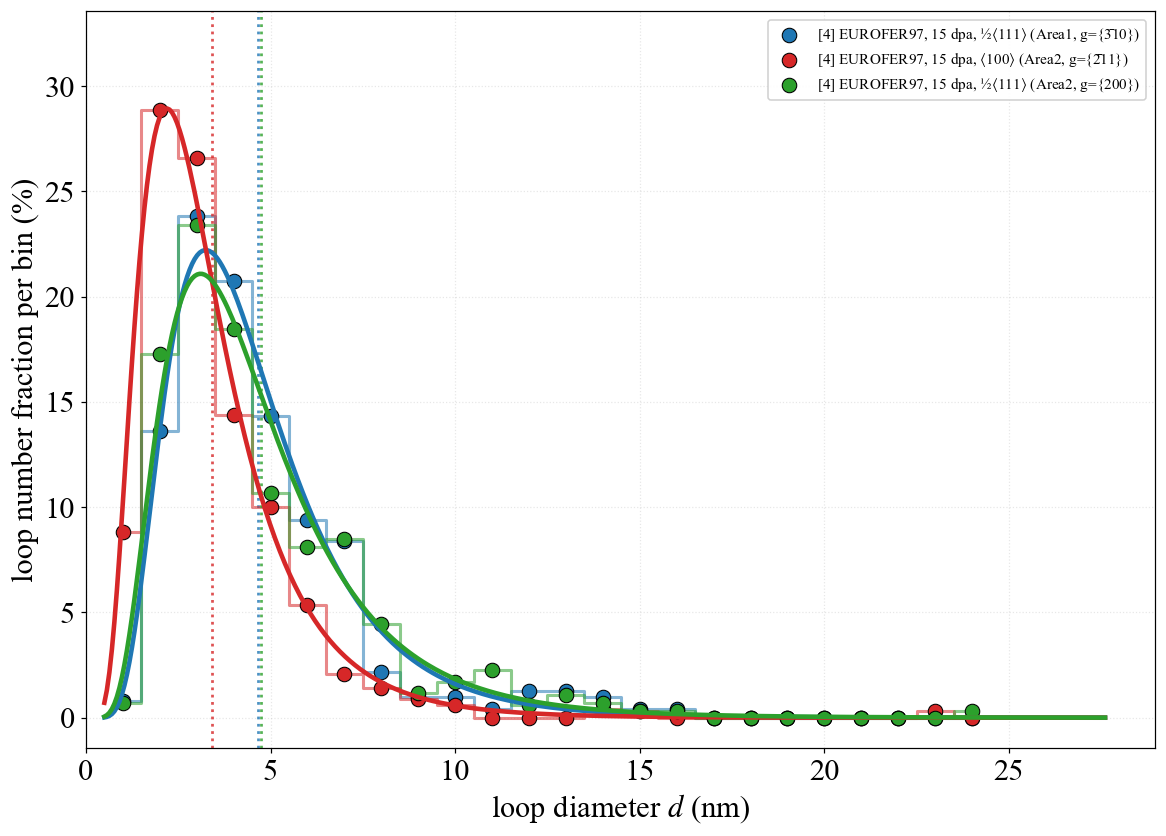

  300C_15dpa_area1 |   ½⟨111⟩ (Area1, g={3̄10}) | mu=1.4178  sigma=0.4909 | mean=  4.66 nm  median=  4.13  mode=  3.24  SD= 2.43 | hist mean=  4.68  hist SD= 2.59 | R2=0.985
  300C_15dpa_area2 |    ⟨100⟩ (Area2, g={2̄11}) | mu=1.0795  sigma=0.5428 | mean=  3.41 nm  median=  2.94  mode=  2.19  SD= 2.00 | hist mean=  3.43  hist SD= 2.21 | R2=0.993
  300C_15dpa_area3 |    ½⟨111⟩ (Area2, g={200}) | mu=1.4138  sigma=0.5294 | mean=  4.73 nm  median=  4.11  mode=  3.11  SD= 2.69 | hist mean=  4.76  hist SD= 2.87 | R2=0.966


In [20]:
plot_distributions(300.0)

**Figure 9.1.** Dislocation-loop size distributions in EUROFER97 after neutron irradiation to 15 dpa at 300 °C in BOR-60 (ARBOR), resolved by Burgers vector and imaging area. Markers and thin steps are the measured per-bin number fractions (renormalised to 100 %); thick curves are the moment-matched log-normal fits; dotted vertical lines mark the fitted means. At 300 °C the $\tfrac12\langle111\rangle$ populations are the larger but less numerous ones and the $\langle100\rangle$ population is shifted to smaller diameters — the low-temperature side of the $\tfrac12\langle111\rangle \to \langle100\rangle$ crossover.

| Curve | Material | Irradiation | Dose | $T$ | Population | Fitted mean / median / mode (nm) | $\sigma$ | Source |
|---|---|---|---|---|---|---|---|---|
| 300C_15dpa_area1 | EUROFER97 | Neutron (BOR-60) | 15 dpa | 300 °C | ½⟨111⟩ (Area1, g={3̄10}) | 4.66 / 4.13 / 3.24 | 0.491 | Dethloff 2016 |
| 300C_15dpa_area2 | EUROFER97 | Neutron (BOR-60) | 15 dpa | 300 °C | ⟨100⟩ (Area2, g={2̄11}) | 3.41 / 2.94 / 2.19 | 0.543 | Dethloff 2016 |
| 300C_15dpa_area3 | EUROFER97 | Neutron (BOR-60) | 15 dpa | 300 °C | ½⟨111⟩ (Area2, g={200}) | 4.73 / 4.11 / 3.11 | 0.529 | Dethloff 2016 |

## 9.2 Loop size distributions at 350 °C

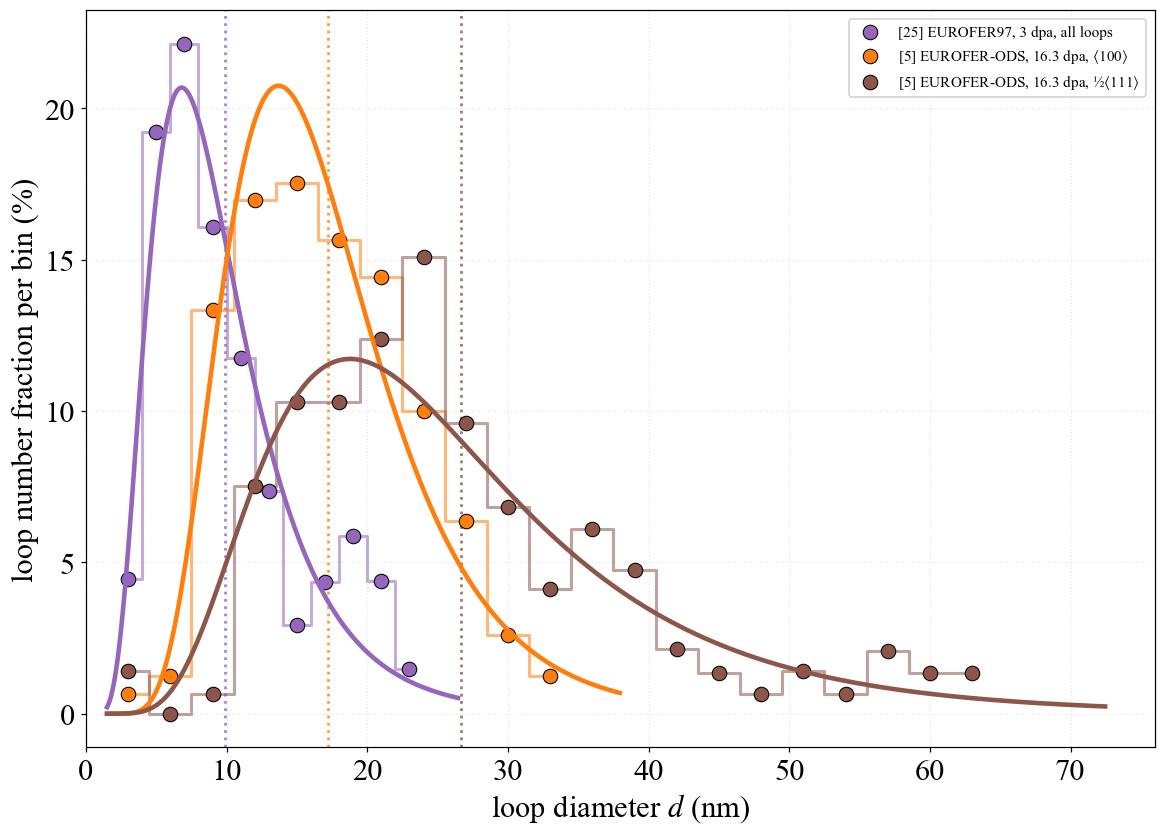

         350C_3dpa |                  all loops | mu=2.1682  sigma=0.5002 | mean=  9.91 nm  median=  8.74  mode=  6.81  SD= 5.28 | hist mean=  9.90  hist SD= 5.03 | R2=0.915
    350C_16dpa_100 |                      ⟨100⟩ | mu=2.7697  sigma=0.3904 | mean= 17.22 nm  median= 15.95  mode= 13.70  SD= 6.99 | hist mean= 17.12  hist SD= 6.12 | R2=0.919
    350C_16dpa_111 |                     ½⟨111⟩ | mu=3.1669  sigma=0.4838 | mean= 26.68 nm  median= 23.73  mode= 18.78  SD=13.70 | hist mean= 26.39  hist SD=12.06 | R2=0.877


In [21]:
plot_distributions(350.0)

**Figure 9.2.** Dislocation-loop size distributions at 350 °C. Three populations are available at this temperature and they are *not* from a single experiment — EUROFER97 under 700 keV Kr²⁺ ion irradiation to 3 dpa (JANNUS-Saclay) alongside EUROFER-ODS under BOR-60 neutron irradiation to 16.3 dpa, resolved by Burgers vector. Markers and thin steps are the measured per-bin number fractions; thick curves are the moment-matched log-normal fits; dotted vertical lines mark the fitted means. The contrast with Figure 9.1 is the expected one: at 350 °C the distributions are broader and shifted to markedly larger diameters, and the $\tfrac12\langle111\rangle$ population in the ODS grade extends to 60 nm. The ion-irradiated EUROFER97 distribution is narrower and centred at 9.9 nm, consistent with Table G.33 (ion irradiation gives more symmetric, narrower distributions with fewer black dots).

| Curve | Material | Irradiation | Dose | $T$ | Population | Fitted mean / median / mode (nm) | $\sigma$ | Source |
|---|---|---|---|---|---|---|---|---|
| 350C_3dpa | EUROFER97 | Ion (Kr²⁺, 700 keV) | 3 dpa | 350 °C | all loops | 9.91 / 8.74 / 6.81 | 0.500 | Boulanger & Serruys 2009 |
| 350C_16dpa_100 | EUROFER-ODS | Neutron (BOR-60) | 16.3 dpa | 350 °C | ⟨100⟩ | 17.22 / 15.95 / 13.70 | 0.390 | Klimenkov 2017 |
| 350C_16dpa_111 | EUROFER-ODS | Neutron (BOR-60) | 16.3 dpa | 350 °C | ½⟨111⟩ | 26.68 / 23.73 / 18.78 | 0.484 | Klimenkov 2017 |

## 9.3 Temperature evolution of the fitted distributions

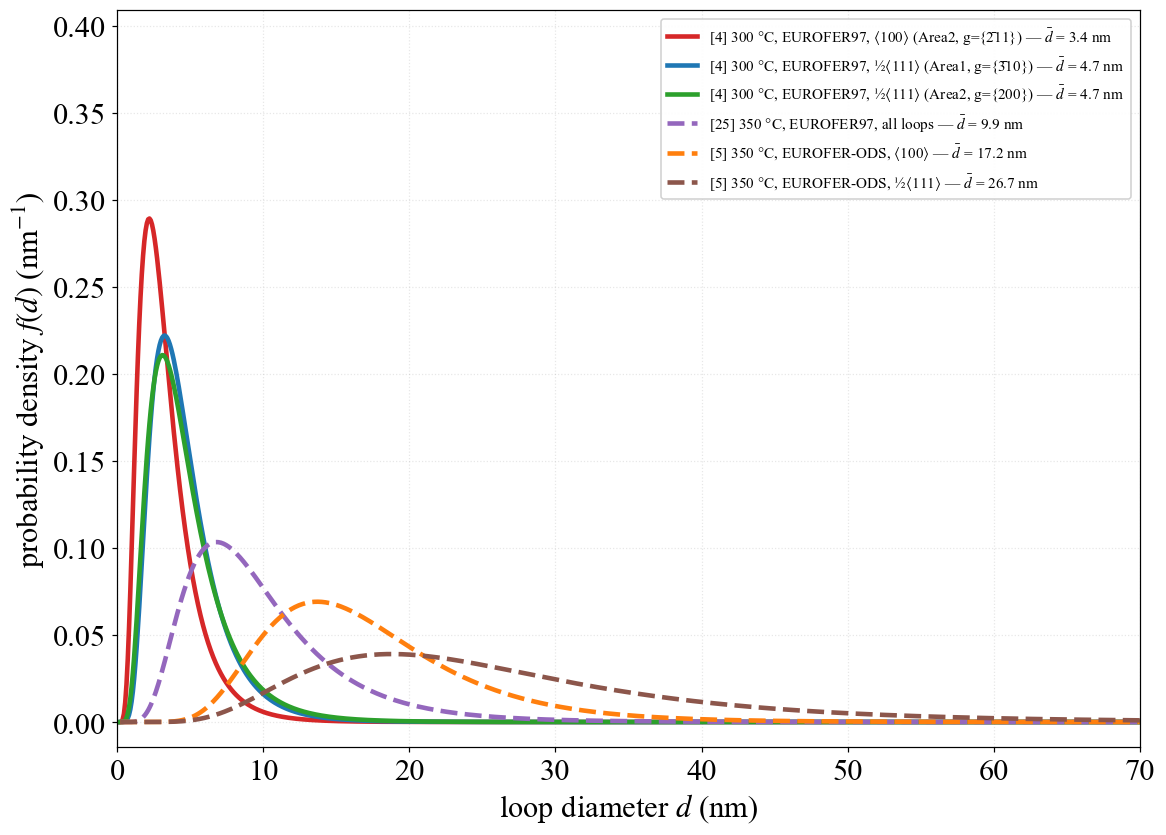

In [22]:
fig, ax = plt.subplots(figsize=(11, 8))
order = sorted(FITS, key=lambda k: (float(META.loc[META.dataset == k, "T_C"].iloc[0]),
                                    FITS[k]["mean"]))
for k in order:
    m = META.loc[META.dataset == k].iloc[0]
    v = FITS[k]
    dg = np.linspace(0.2, 70, 800)
    ls = "-" if float(m["T_C"]) == 300 else "--"
    ax.plot(dg, lognormal_pdf(dg, v["mu"], v["sig"]), ls=ls, lw=3.0,
            color=SDCOL.get(k, "k"),
            label=f"[{ref_no(m['ref'])}] {m['T_C']:.0f} °C, {m['material']}, "
                  f"{texify(m['population'])}"
                  f" — $\\bar d$ = {v['mean']:.1f} nm")
ax.set_xlabel(r"loop diameter $d$ (nm)")
ax.set_ylabel(r"probability density $f(d)$ (nm$^{-1}$)")
ax.set_xlim(0, 70)
ax.grid(alpha=0.3, ls=":")
place_legend_inside(ax)
fig.tight_layout()
plt.show()

**Figure 9.3.** All six fitted log-normal loop-size distributions on a common probability-density axis (each normalised to unit area), solid for 300 °C and dashed for 350 °C. This is the quantitative counterpart of the schematic Figure G.13: raising the irradiation temperature from 300 to 350 °C shifts the mode from ~2–3 nm to 7–19 nm and broadens the distribution, while the peak height drops by roughly an order of magnitude. Sources: Dethloff 2016 (EUROFER97, BOR-60, 15 dpa, 300 °C — three populations); Boulanger & Serruys 2009 (EUROFER97, 700 keV Kr²⁺, 3 dpa, 350 °C); Klimenkov 2017 (EUROFER-ODS, BOR-60, 16.3 dpa, 350 °C — $\langle100\rangle$ and $\tfrac12\langle111\rangle$).

---
# 10. Reducing the scatter: grouping on known variables

Sections 5–8 fit one log-linear model $\ln y = a + b\,T$ to every point in a dose group.
Several of those fits are very weak — the cavity number density at $\ge 1$ dpa has
$R^2 = 0.005$ and a geometric scatter of GSD $= 9.8$, i.e. the $\pm 2s$ band spans nearly
four orders of magnitude. This section asks whether that scatter is irreducible
measurement noise, or whether it is **structure**: variance carried by variables the
database already records — irradiation dose, irradiation type (and hence dose rate),
alloy class, and the distinction between a void and a He bubble.

### 10.1 Why extra parameters have to be charged for

Adding any regressor reduces the residual sum of squares. Splitting the $\ge 1$ dpa group
into two or three dose bins and fitting each bin separately **always** lowers the
within-group scatter, whether or not dose matters, because every bin is handed its own
intercept. A drop in $s^2$ is therefore not by itself evidence of anything. Three guards
are used throughout this section:

| Statistic | What it does |
|---|---|
| $s^2$, adjusted $R^2$ | charge the degrees of freedom that were spent |
| AICc | information criterion with the small-sample correction — at $n = 17$–$32$ plain AIC is optimistic |
| **LOO** | leave-one-out RMS prediction error in $\ln y$; a parameter that fits only noise *raises* it |

Candidate models are ranked by **LOO**, the only one of the three that is a genuine
out-of-sample measure, with AICc printed alongside as a cross-check and a nested $F$-test
against the temperature-only model reported as `p_vs_T`.

Covariates are entered into a **single pooled regression** rather than fitted as
independent per-group lines: the temperature slope is estimated from the whole panel and
only the intercept is allowed to shift between groups. Where a grouping is real this is
both more parsimonious and far more stable than independent per-group fits, several of
which would rest on three or four points.

In [23]:
# --- multi-covariate log-linear fitting with small-sample model selection --------
def mfit(y, cols, name="model"):
    """OLS of ln(y) on [1, *cols].  Returns coefficients and selection statistics."""
    y = np.asarray(y, float)
    X = np.column_stack([np.ones(len(y))] + [np.asarray(c, float) for c in cols])
    ly = np.log(y)
    n, p = X.shape
    if n - p < 1:
        return None
    beta, *_ = np.linalg.lstsq(X, ly, rcond=None)
    res = ly - X @ beta
    rss = float(res @ res)
    dof = n - p
    s2  = rss / dof
    tss = float(((ly - ly.mean()) ** 2).sum())
    r2  = 1.0 - rss / tss if tss > 0 else np.nan
    adj = 1.0 - (1.0 - r2) * (n - 1) / dof
    aic = n * np.log(rss / n) + 2 * p
    aicc = aic + 2 * p * (p + 1) / (n - p - 1) if n - p - 1 > 0 else np.inf
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    return dict(name=name, n=n, p=p, beta=beta, se=se, rss=rss, s2=s2, s=np.sqrt(s2),
                gsd=float(np.exp(np.sqrt(s2))), R2=r2, adjR2=adj, AICc=aicc)


def loo_rms(y, cols):
    """Leave-one-out RMS prediction error in ln y.  Cannot be lowered by fitting noise."""
    y = np.asarray(y, float)
    X = np.column_stack([np.ones(len(y))] + [np.asarray(c, float) for c in cols])
    ly = np.log(y)
    n = len(y)
    if n - X.shape[1] < 1:
        return np.nan
    err = np.empty(n)
    for i in range(n):
        k = np.arange(n) != i
        b, *_ = np.linalg.lstsq(X[k], ly[k], rcond=None)
        err[i] = ly[i] - X[i] @ b
    return float(np.sqrt(np.mean(err ** 2)))


def f_pvalue(small, big):
    """Nested-model F test: is the extra structure in `big` justified over `small`?"""
    from scipy import stats
    if small is None or big is None:
        return np.nan
    df1, df2 = big["p"] - small["p"], big["n"] - big["p"]
    if df1 <= 0 or df2 <= 0:
        return np.nan
    F = ((small["rss"] - big["rss"]) / df1) / (big["rss"] / df2)
    return float(1.0 - stats.f.cdf(F, df1, df2))


def group_dummies(labels, ref=None):
    """Treatment-coded dummies; the reference level is dropped.  Returns (cols, levels)."""
    labels = np.asarray(labels, dtype=object)
    lv = sorted(pd.unique(labels).tolist(), key=str)
    if ref is not None and ref in lv:
        lv = [ref] + [l for l in lv if l != ref]
    return [(labels == l).astype(float) for l in lv[1:]], lv


def compare(d, quantity, candidates):
    """Rank candidate covariate sets for one panel.  First entry is the baseline."""
    y = d[QCOL[quantity]].to_numpy(float)
    base, rows = None, []
    for nm, cols in candidates.items():
        m = mfit(y, cols, nm)
        if m is None:
            continue
        if base is None:
            base = m
        rows.append(dict(model=nm, k=m["p"] - 1, s2=m["s2"], GSD=m["gsd"], R2=m["R2"],
                         adjR2=m["adjR2"], AICc=m["AICc"], LOO=loo_rms(y, cols),
                         p_vs_T=f_pvalue(base, m) if m["p"] > base["p"] else np.nan))
    t = pd.DataFrame(rows).sort_values("LOO").reset_index(drop=True)
    return t.round(dict(s2=3, GSD=2, R2=3, adjR2=3, AICc=1, LOO=3, p_vs_T=4))

### 10.2 The candidate covariates

Four kinds of grouping are tested, all built only from columns the database already
carries.

* **He-bubble flag** — 1 (`cavity_kind == "He bubble"`) or 0. Separates the
  He-implanted bubble population from voids proper.
* **Ion flag** — 1 for ion and spallation rows, 0 for neutron. This is a *dose-rate*
  proxy: ion irradiations run at $\sim10^{-4}$–$10^{-3}$ dpa/s against $\sim6\times10^{-7}$
  dpa/s for neutrons. Note that this dummy and the $-60$ °C shift of
  `T_SHIFT_ION` are **exactly collinear** — $T_\mathrm{eq} = T - 60\,\chi_\mathrm{ion}$ —
  so once the dummy is present the fit is numerically identical whether $T$ or
  $T_\mathrm{eq}$ is used. The difference is that the dummy is *estimated from the data*
  rather than assumed.
* **Dose** — as a continuous $\ln(\phi)$ term, and as bins. Bin edges are placed at the
  natural gaps in the cavity dose set (values cluster at 1–17, 26–32 and 140–500 dpa),
  giving edges at **20 and 50 dpa** and a balanced 9/6/6 split. Data-derived tertiles were
  tried first and are worse, because they cut through the cluster of 30 dpa points.
* **Alloy class** — a coarse 4-level family (9Cr F/M, 12Cr F/M, ODS, pure Fe), a 1-dof
  ODS-versus-rest flag, and Cr content as a continuous variable. The raw `material`
  column has 28 levels across 27 rows and cannot be used directly.

In [24]:
# --- derived grouping columns ---------------------------------------------------
DOSE_EDGES_CAVITY = (20.0, 50.0)   # dpa - at the natural gaps in the cavity dose set
DOSE_EDGE_LOOP    = 15.0           # dpa - see 10.6, selected by scan and therefore tentative

def _matalloy(d):
    return (d["material"].fillna("") + " " + d["alloy"].fillna("")).str.strip()

def alloy_family(d):
    """Coarse alloy class: the raw `material` column is far too granular to fit."""
    s = _matalloy(d)
    out = np.where(s.str.contains("ODS|NFA|14YWT", regex=True), "ODS",
          np.where(s.str.contains("Pure Fe|bcc Fe", regex=True), "pure Fe",
          np.where(s.str.contains("12Cr|HT9|HCM12A", regex=True), "12Cr F/M", "9Cr F/M")))
    return pd.Series(out, index=d.index)

def cr_wt(d):
    """Nominal Cr content (wt%) parsed from the material / alloy designation."""
    s = _matalloy(d)
    cr = s.str.extract(r"(\d+(?:\.\d+)?)\s*Cr", expand=False).astype(float)
    cr = cr.where(~s.str.contains("Pure Fe|bcc Fe", regex=True), 0.0)
    cr = cr.where(cr.notna() | ~s.str.contains("HT9|HCM12A", regex=True), 12.0)
    cr = cr.where(cr.notna() | ~s.str.contains("8Cr", regex=True), 8.0)
    return cr.fillna(9.0)

DB["family"] = alloy_family(DB)
DB["Cr_wt"]  = cr_wt(DB)

# covariate builders - every one returns plain float arrays aligned with `d`
cov_T       = lambda d: d["T_K_eq"].to_numpy(float)
cov_ion     = lambda d: (d["irradiation"] != "Neutron").astype(float).to_numpy()
cov_bubble  = lambda d: d["cavity_kind"].eq("He bubble").astype(float).to_numpy()
cov_lndose  = lambda d: np.log(d["dose"].to_numpy(float))
cov_ods     = lambda d: _matalloy(d).str.contains("ODS|NFA|14YWT", regex=True).astype(float).to_numpy()
cov_cr      = lambda d: d["Cr_wt"].to_numpy(float)

def cov_dosebins(d, edges):
    """Two dummies for a three-bin dose split; the lowest bin is the reference."""
    v = d["dose"].to_numpy(float)
    return [((v > edges[0]) & (v <= edges[1])).astype(float), (v > edges[1]).astype(float)]

print("alloy families over the whole database:")
print(DB.groupby(["defect", "family"]).size().to_string())
print(f"\nHe-bubble rows: {int(DB.cavity_kind.eq('He bubble').sum())} of "
      f"{int((DB.defect == 'void').sum())} cavity rows")

alloy families over the whole database:
defect  family  
loop    12Cr F/M     9
        9Cr F/M     21
        ODS          4
        pure Fe      2
void    12Cr F/M     7
        9Cr F/M     15
        ODS          8
        pure Fe      2

He-bubble rows: 11 of 32 cavity rows


### 10.3 Model-selection tables

Every candidate is fitted to the four $\ge 1$ dpa panels. The `<1` dpa panels are
excluded: they hold two loop rows and four cavity rows, all of them pure Fe or model
alloys, so there is nothing to group.

In [25]:
def loop_candidates(d):
    T, ion, ld = cov_T(d), cov_ion(d), cov_lndose(d)
    hi = (d["dose"].to_numpy(float) > DOSE_EDGE_LOOP).astype(float)
    fam, _ = group_dummies(d["family"].to_numpy(), ref="9Cr F/M")
    return {
        "T only (Sections 5-8)":              [T],
        "T + ion flag":                       [T, ion],
        "T + ln(dose)":                       [T, ld],
        f"T + dose > {DOSE_EDGE_LOOP:g} dpa flag":  [T, hi],
        "T + ion + ln(dose)":                 [T, ion, ld],
        "T + ODS flag":                       [T, cov_ods(d)],
        "T + alloy family":                   [T] + fam,
        "T + Cr wt%":                         [T, cov_cr(d)],
    }

def cavity_candidates(d):
    T, ld = cov_T(d), cov_lndose(d)
    bub   = cov_bubble(d)
    bins  = cov_dosebins(d, DOSE_EDGES_CAVITY)
    fam, _ = group_dummies(d["family"].to_numpy(), ref="9Cr F/M")
    e = DOSE_EDGES_CAVITY
    return {
        "T only (Sections 5-8)":              [T],
        "T + He-bubble flag":                 [T, bub],
        f"T + dose bins ({e[0]:g}, {e[1]:g})": [T] + bins,
        "T + dose bins + He-bubble":          [T] + bins + [bub],
        "T + ln(dose)":                       [T, ld],
        "T + ion flag":                       [T, cov_ion(d)],
        "T + ODS flag":                       [T, cov_ods(d)],
        "T + alloy family":                   [T] + fam,
    }

PANELS = [("loop", "density", "Loop number density",   loop_candidates),
          ("loop", "size",    "Mean loop diameter",    loop_candidates),
          ("void", "density", "Cavity number density", cavity_candidates),
          ("void", "size",    "Mean cavity diameter",  cavity_candidates)]

SEL = {}
for defect, quantity, label, cands in PANELS:
    d = select(defect, quantity, ">=1 dpa")
    SEL[(defect, quantity)] = d
    t = compare(d, quantity, cands(d))
    print("=" * 104)
    print(f"{label}  (dose >= 1 dpa, n = {len(d)})   -- ranked by LOO, lower is better")
    print(t.to_string(index=False))

Loop number density  (dose >= 1 dpa, n = 27)   -- ranked by LOO, lower is better
                 model  k    s2  GSD    R2  adjR2  AICc   LOO  p_vs_T
          T + ion flag  2 1.054 2.79 0.510  0.469   5.3 1.065  0.0004
    T + ion + ln(dose)  3 1.020 2.75 0.546  0.486   6.0 1.199  0.0009
 T only (Sections 5-8)  1 1.724 3.72 0.165  0.132  17.1 1.406     NaN
          T + ODS flag  2 1.792 3.81 0.167  0.098  19.6 1.433  0.8171
            T + Cr wt%  2 1.784 3.80 0.170  0.101  19.5 1.444  0.6995
T + dose > 15 dpa flag  2 1.783 3.80 0.171  0.102  19.5 1.449  0.6806
      T + alloy family  3 1.841 3.88 0.180  0.073  22.0 1.467  0.8192
          T + ln(dose)  2 1.766 3.78 0.179  0.111  19.2 1.513  0.5310
Mean loop diameter  (dose >= 1 dpa, n = 32)   -- ranked by LOO, lower is better
                 model  k    s2  GSD    R2  adjR2  AICc   LOO  p_vs_T
T + dose > 15 dpa flag  2 0.270 1.68 0.261  0.210 -38.2 0.544  0.0069
          T + ion flag  2 0.311 1.75 0.151  0.092 -33.7 0.580  0.0689

**Table 10.1.** Model selection for the four $\ge 1$ dpa panels, ranked by leave-one-out
prediction error. `k` is the number of regressors beyond the intercept, `p_vs_T` the
nested $F$-test probability against the temperature-only baseline.

The winner is different for every panel, and in no case is it the alloy class:

| Panel | Best covariate | $s^2$ | GSD | $R^2$ | LOO | Variance removed |
|---|---|---|---|---|---|---|
| Cavity number density | He-bubble flag | $5.209 \to 0.982$ | $9.80 \to 2.69$ | $0.005 \to 0.825$ | $2.98 \to 1.05$ | **81 %** |
| Mean cavity diameter | dose bins (20, 50 dpa) | $0.632 \to 0.123$ | $2.21 \to 1.42$ | $0.333 \to 0.884$ | $0.83 \to 0.39$ | **81 %** |
| Loop number density | ion flag | $1.724 \to 1.054$ | $3.72 \to 2.79$ | $0.165 \to 0.510$ | $1.41 \to 1.07$ | **39 %** |
| Mean loop diameter | dose $>$ 15 dpa | $0.338 \to 0.270$ | $1.79 \to 1.68$ | $0.046 \to 0.261$ | $0.59 \to 0.54$ | 20 % *(weak)* |

Two results are worth stating explicitly because they are negative:

* **Dose does nothing for loop number density.** `T + ln(dose)` *raises* both AICc
  (17.1 → 19.2) and LOO (1.41 → 1.51). Dose bins do no better. This is consistent with
  loop density saturating early and then being held at a steady state — the behaviour the
  loop $\to$ network loss term of `RadCluster_2_1` is designed to reproduce.
* **Dose is decisive for cavity size but not cavity density.** Cavities keep growing with
  dose ($R^2 = 0.884$) while their number density is set by something else entirely.

In [26]:
GRPCOL = ["#1f4e79", "#c0392b", "#27ae60", "#8e44ad", "#e67e22", "#16a085"]

def panel_grouped(d, quantity, labels, ylabel, ref=None, ylog=True, extra=None):
    """Scatter coloured by group, with a common-slope / group-intercept fit per group.

    Points carry their reference number, as in Sections 5-8.  Marker shape still
    encodes the irradiation series.  The dashed
    black line is the ungrouped fit of Sections 5-8, drawn for direct comparison.
    `extra` adds further regressors to the model without giving them their own line.
    """
    col = QCOL[quantity]
    y   = d[col].to_numpy(float)
    T   = d["T_K_eq"].to_numpy(float)
    labels = np.asarray(labels, dtype=object)
    dums, lv = group_dummies(labels, ref=ref)
    cols = [T] + dums + (list(extra) if extra else [])
    m    = mfit(y, cols, "grouped")
    base = mfit(y, [T], "T only")

    fig, ax = plt.subplots(figsize=(11, 8))
    for i, l in enumerate(lv):
        g = labels == l
        c = GRPCOL[i % len(GRPCOL)]
        for ser, gg in d[g].groupby("series", sort=False):
            lbl = (f"{l} (n={len(gg)})"
                   if str(l).strip().lower() == str(ser).strip().lower()
                   else f"{l} \u2014 {ser} (n={len(gg)})")
            ax.scatter(gg["T_K_eq"], gg[col], s=200, c=[c], marker=MARK[ser],
                       edgecolors="k", linewidths=1.0, zorder=3, label=lbl)
        if m is not None and g.sum():
            off = 0.0 if i == 0 else m["beta"][1 + i]
            lo, hi = (T[g].min(), T[g].max()) if T[g].min() < T[g].max() else (T.min(), T.max())
            xs = np.linspace(lo, hi, 100)
            yy = np.exp(m["beta"][0] + off + m["beta"][1] * xs)
            ax.plot(xs, yy, "-", color=c, lw=3.0, zorder=2)
            ax.fill_between(xs, yy*np.exp(-2*m["s"]), yy*np.exp(2*m["s"]),
                            color=c, alpha=0.10, zorder=1)
    annotate_refs(ax, d, "T", col)
    if base is not None:
        xs = np.linspace(T.min(), T.max(), 100)
        ax.plot(xs, np.exp(base["beta"][0] + base["beta"][1]*xs), "k--", lw=2.4, zorder=2,
                label="ungrouped fit (Sections 5\u20138)")
        ax.fill_between(xs, np.exp(base["beta"][0] + base["beta"][1]*xs - 2*base["s"]),
                        np.exp(base["beta"][0] + base["beta"][1]*xs + 2*base["s"]),
                        color="0.5", alpha=0.12, zorder=0)
    ax.set_xlabel(r"$T$ (K)")
    ax.set_ylabel(ylabel)
    if ylog:
        ax.set_yscale("log")
    ax.grid(alpha=0.3, ls=":")
    place_legend_inside(ax)
    fig.tight_layout()
    return fig, m, base, lv


def report_grouped(m, base, lv, unit=""):
    """Print the grouped fit with coefficient standard errors and the group offsets."""
    if m is None:
        print("   model not identifiable"); return
    print(f"   ungrouped :  ln y = {base['beta'][0]:.4f} + {base['beta'][1]:.5g} T"
          f"    s^2 = {base['s2']:.4f}   GSD = {base['gsd']:.2f}   R^2 = {base['R2']:.3f}")
    print(f"   grouped   :  common slope b = {m['beta'][1]:.5g} +/- {m['se'][1]:.3g} K^-1"
          f"    s^2 = {m['s2']:.4f}   GSD = {m['gsd']:.2f}   adj R^2 = {m['adjR2']:.3f}")
    print(f"   reference level '{lv[0]}':  a = {m['beta'][0]:.4f} +/- {m['se'][0]:.3g}")
    for i, l in enumerate(lv[1:], start=1):
        b, s = m["beta"][1 + i], m["se"][1 + i]
        print(f"     offset '{l}':  {b:+.4f} +/- {s:.3g}  ->  x{np.exp(b):.3g} "
              f"relative to '{lv[0]}'{unit}  (t = {b/s:+.2f})")
    print(f"   variance removed vs ungrouped: {100*(1 - m['s2']/base['s2']):.1f} %")

### 10.4 Cavity number density — He bubbles are a separate population

This is the largest single reduction in the notebook, and it is a **data-classification
result rather than a fitting result**. `INCLUDE_HE_BUBBLES = True` (Section 4) merges the
`Ion_He_Bubbles` sheet into the void population, so the panel of Figure 7.3 pools two
physically distinct populations: five He-implanted bubble measurements at
$10^{23}$–$10^{24}$ m⁻³ against twelve void measurements two to three orders of magnitude
lower. Almost all of the GSD $= 9.8$ scatter is that step.

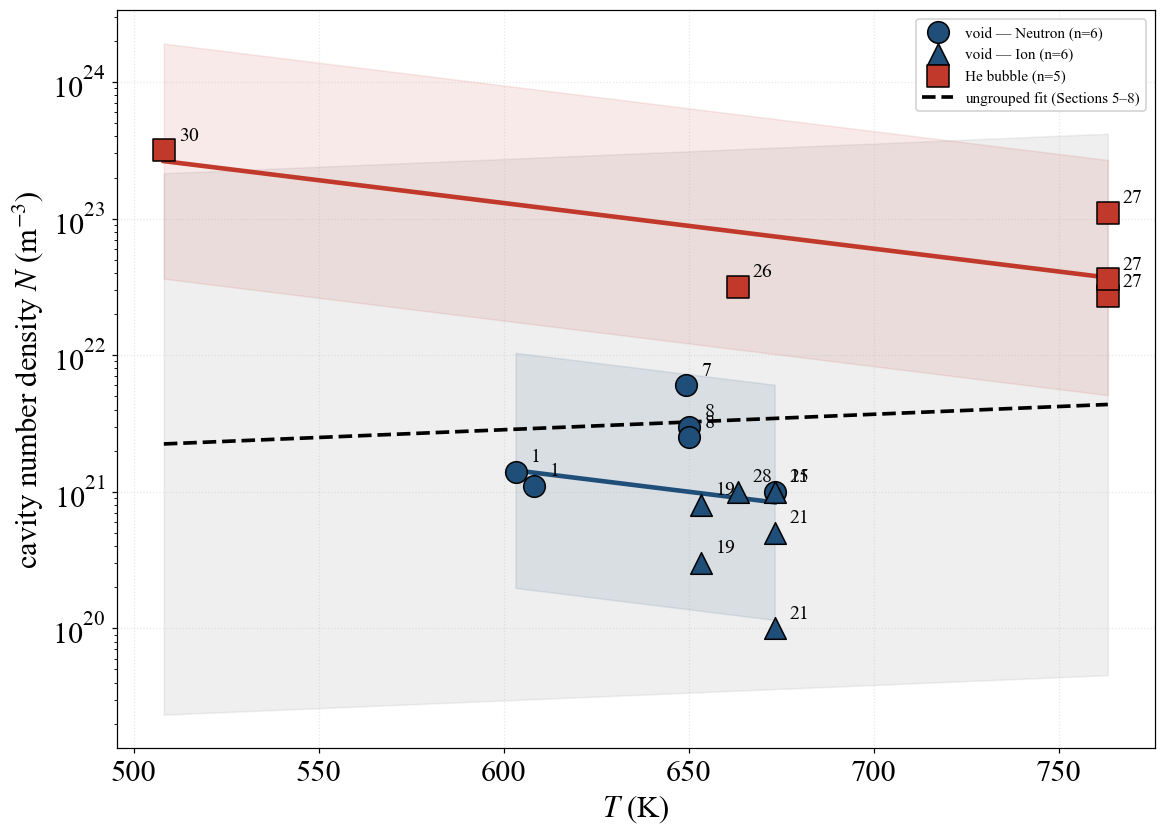

   ungrouped :  ln y = 47.8343 + 0.0026096 T    s^2 = 5.2086   GSD = 9.80   R^2 = 0.005
   grouped   :  common slope b = -0.0076998 +/- 0.00419 K^-1    s^2 = 0.9824   GSD = 2.69   adj R^2 = 0.800
   reference level 'void':  a = 53.3584 +/- 2.74
     offset 'He bubble':  +4.4833 +/- 0.554  ->  x88.5 relative to 'void'  (t = +8.10)
   variance removed vs ungrouped: 81.1 %

   rows by population:
            n  T_min  T_max  dose_min    dose_max     N_geomean
pop                                                            
He bubble   5  235.0  550.0      11.0   30.000000  6.394577e+22
void       12  330.0  460.0       1.0  220.794022  9.847505e+20


In [27]:
d = SEL[("void", "density")]
lab = np.where(d.cavity_kind.eq("He bubble"), "He bubble", "void")
fig, m, base, lv = panel_grouped(d, "density", lab,
                                 r"cavity number density $N$ (m$^{-3}$)", ref="void")
plt.show()
report_grouped(m, base, lv)
print("\n   rows by population:")
print(d.assign(pop=lab).groupby("pop").agg(
        n=("material", "size"), T_min=("T_C", "min"), T_max=("T_C", "max"),
        dose_min=("dose", "min"), dose_max=("dose", "max"),
        N_geomean=("dens_m3", lambda s: float(np.exp(np.log(s).mean())))).to_string())

**Figure 10.1.** Cavity number density versus $T$ (K) at dose $\ge 1$ dpa, with He bubbles
(red) and voids (blue) fitted as separate populations sharing a common temperature slope.
Marker shape is the irradiation series as in Sections 5–8; the dashed black line and grey
band are the ungrouped fit of Figure 7.3. Separating the two populations takes
$s^2$ from 5.209 to 0.982 and $R^2$ from 0.005 to 0.825 — **81 % of the variance removed
for one degree of freedom**, and out-of-sample error (LOO) falls from 2.98 to 1.05.

The bubble population sits a factor **88.5** above the voids at the same temperature
($t = 8.1$), which is the expected result: He implantation supplies a nucleation site
density that vacancy supersaturation alone never reaches.

The separation also **recovers a physically sensible temperature dependence that the
pooled fit had destroyed**. Ungrouped, the slope is $b = +0.0026$ K⁻¹ — cavity density
apparently *rising* with temperature. Grouped, it becomes $b = -0.0077 \pm 0.0042$ K⁻¹:
cavity density falls with temperature, as vacancy emission and coarsening require. The
pooled fit had been reading the bubble/void step, which happens to run the other way
because the bubble measurements sit at higher temperatures, as though it were a
temperature trend.

**A confound that must be stated.** All three ODS rows in this panel are He-bubble
measurements, and all come from one experiment (Song 2018, dual Fe+He, 550 °C, 30 dpa).
Within the cavity data, "ODS" and "He bubble" are therefore the *same five rows* and
cannot be separated — the 4-level alloy family reaches $R^2 = 0.646$ here only because it
is partially reproducing the bubble/void split, and it needs three degrees of freedom to
do worse than the bubble flag does with one. The physical expectation that ODS particles
provide strong, finely dispersed sinks is entirely reasonable, but **this database cannot
test it on cavities**. Section 10.7 tests it where it *is* separable, on the loop data.

### 10.5 Mean cavity diameter — dose bins

Cavity size is where the dose grouping pays off. The cavity dose values fall into three
natural clusters separated by clear gaps — 1–17 dpa, 26–32 dpa and 140–500 dpa — so the
bin edges are placed at **20 and 50 dpa**, giving a balanced 9/6/6 split. These round
edges outperform data-derived tertiles (LOO 0.391 against 0.551), because the tertiles cut
straight through the cluster of 30 dpa points.

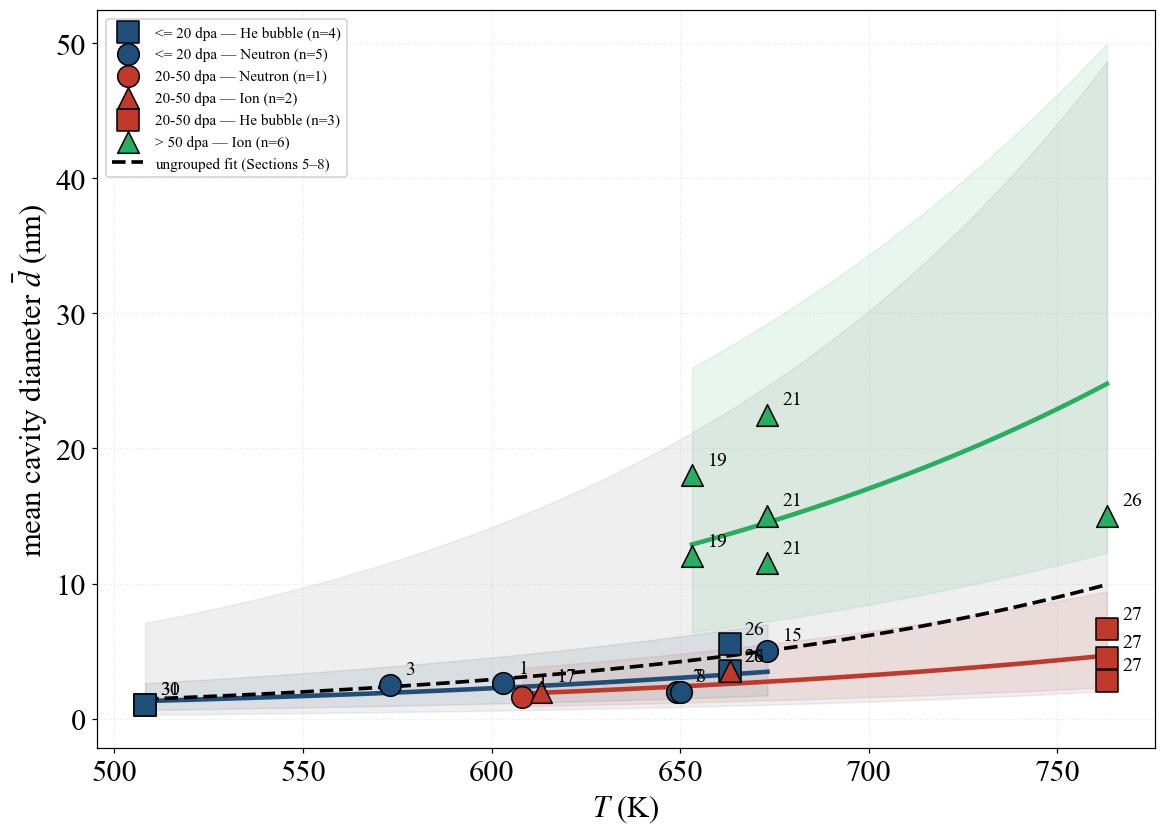

   ungrouped :  ln y = -3.4767 + 0.0075628 T    s^2 = 0.6318   GSD = 2.21   R^2 = 0.333
   grouped   :  common slope b = 0.0059456 +/- 0.0013 K^-1    s^2 = 0.1229   GSD = 1.42   adj R^2 = 0.863
   reference level '<= 20 dpa':  a = -2.7583 +/- 0.802
     offset '20-50 dpa':  -0.2384 +/- 0.216  ->  x0.788 relative to '<= 20 dpa'  (t = -1.11)
     offset '> 50 dpa':  +1.4310 +/- 0.207  ->  x4.18 relative to '<= 20 dpa'  (t = +6.92)
   variance removed vs ungrouped: 80.5 %

   rows by dose bin:
           n  dose_min  dose_max     d_mean
bin                                        
20-50 dpa  6      26.0      32.0   3.500000
<= 20 dpa  9       1.0      17.1   2.788889
> 50 dpa   6     140.0     500.0  15.666667


In [28]:
d = SEL[("void", "size")]
e = DOSE_EDGES_CAVITY
dose = d["dose"].to_numpy(float)
lab = np.where(dose <= e[0], f"<= {e[0]:g} dpa",
      np.where(dose <= e[1], f"{e[0]:g}-{e[1]:g} dpa", f"> {e[1]:g} dpa"))
fig, m, base, lv = panel_grouped(d, "size", lab, r"mean cavity diameter $\bar d$ (nm)",
                                 ref=f"<= {e[0]:g} dpa", ylog=False)
plt.show()
report_grouped(m, base, lv)
print("\n   rows by dose bin:")
print(d.assign(bin=lab).groupby("bin").agg(
        n=("material", "size"), dose_min=("dose", "min"), dose_max=("dose", "max"),
        d_mean=("size_nm", "mean")).to_string())

**Figure 10.2.** Mean cavity diameter versus $T$ (K) at dose $\ge 1$ dpa, grouped into
three dose bins with a common temperature slope. Dashed black line and grey band are the
ungrouped fit of Figure 7.4. Binning takes $s^2$ from 0.632 to 0.123, $R^2$ from 0.333 to
0.884 (adjusted 0.863), and LOO from 0.825 to 0.391 — **81 % of the variance removed for
two degrees of freedom**.

Note that the *binned* form clearly beats continuous $\ln(\phi)$ (LOO 0.391 against 0.757,
$s^2$ 0.123 against 0.392). The cavity size response to dose in this database is therefore
step-like rather than a power law — consistent with the three clusters being three
distinct experimental campaigns rather than a swept dose series, so the "bins" are partly
standing in for campaign-to-campaign differences in technique. Treat the bin offsets as an
empirical stratification, not as a measured dose exponent.

### 10.6 Loop number density — irradiation type (dose rate)

For loops the useful variable is neither dose nor alloy but the **irradiation type**, and
it acts as a pure intercept offset.

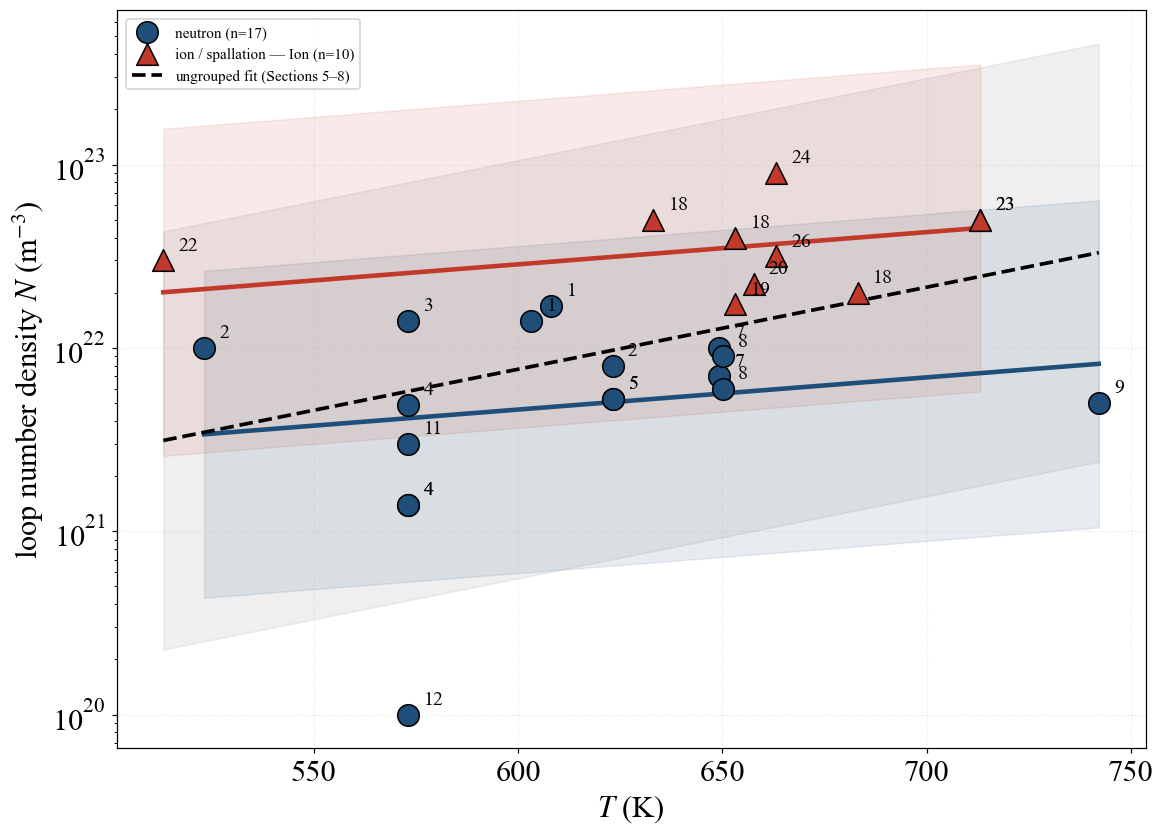

   ungrouped :  ln y = 44.2091 + 0.010301 T    s^2 = 1.7238   GSD = 3.72   R^2 = 0.165
   grouped   :  common slope b = 0.0040424 +/- 0.00393 K^-1    s^2 = 1.0540   GSD = 2.79   adj R^2 = 0.469
   reference level 'neutron':  a = 47.4576 +/- 2.41
     offset 'ion / spallation':  +1.8240 +/- 0.444  ->  x6.2 relative to 'neutron'  (t = +4.11)
   variance removed vs ungrouped: 38.9 %

   collinearity check:  s^2(T_eq + ion) = 1.053991, s^2(T_raw + ion) = 1.053991  ->  identical fits
   ion/neutron density ratio at equal EQUIVALENT temperature T_eq: 6.2x  (t = +4.11)
   ion/neutron density ratio at equal ACTUAL     temperature T   : 4.9x  (t = +2.74)
   the two differ by exactly exp(60*b) = 1.27, the -60 C shift folded into the offset


In [29]:
d = SEL[("loop", "density")]
lab = np.where(d.irradiation.eq("Neutron"), "neutron", "ion / spallation")
fig, m, base, lv = panel_grouped(d, "density", lab,
                                 r"loop number density $N$ (m$^{-3}$)", ref="neutron")
plt.show()
report_grouped(m, base, lv)

# the ion dummy and the -60 C equivalence shift are exactly collinear: verify it
y = d["dens_m3"].to_numpy(float)
ion = cov_ion(d)
m_eq  = mfit(y, [d["T_K_eq"].to_numpy(float), ion], "T_eq  + ion")
m_raw = mfit(y, [d["T_K"].to_numpy(float),    ion], "T_raw + ion")
print(f"\n   collinearity check:  s^2(T_eq + ion) = {m_eq['s2']:.6f}, "
      f"s^2(T_raw + ion) = {m_raw['s2']:.6f}  ->  identical fits")
print(f"   ion/neutron density ratio at equal EQUIVALENT temperature T_eq: "
      f"{np.exp(m_eq['beta'][2]):.1f}x  (t = {m_eq['beta'][2]/m_eq['se'][2]:+.2f})")
print(f"   ion/neutron density ratio at equal ACTUAL     temperature T   : "
      f"{np.exp(m_raw['beta'][2]):.1f}x  (t = {m_raw['beta'][2]/m_raw['se'][2]:+.2f})")
print(f"   the two differ by exactly exp(60*b) = {np.exp(60*m_eq['beta'][1]):.2f}, "
      f"the -60 C shift folded into the offset")

**Figure 10.3.** Loop number density versus $T$ (K) at dose $\ge 1$ dpa, with neutron
(blue) and ion/spallation (red) rows given separate intercepts and a common temperature
slope. Dashed black line and grey band are the ungrouped fit of Figure 5.3. The offset
takes $s^2$ from 1.724 to 1.054, $R^2$ from 0.165 to 0.510 and LOO from 1.41 to 1.07 —
**39 % of the variance removed for one degree of freedom** ($p = 4\times10^{-4}$).

Ion irradiation produces **6.2× the loop density** of neutron irradiation at the same
*equivalent* temperature, or **4.9×** at the same *actual* temperature — the two differ by
exactly $\exp(60b) = 1.27$, the $-60$ °C shift folded into the offset, and both are
printed above. Either way this is a dose-rate effect: at $10^{-4}$–$10^{-3}$ dpa/s the
point-defect supersaturation is far higher than at $6\times10^{-7}$ dpa/s, so nucleation
outruns growth and the loop population is finer and denser.

Note also that the fitted temperature slope becomes insignificant once the offset is
present ($b = 0.0040 \pm 0.0039$ K⁻¹): what the ungrouped fit of Figure 5.3 read as a
temperature trend was substantially the ion points — which sit at higher temperatures *and*
higher densities — masquerading as one.

**This supersedes the $-60$ °C shift as a fitting device.** As the printed check confirms,
$T_\mathrm{eq} = T - 60\,\chi_\mathrm{ion}$ is exactly collinear with the ion dummy, so
$s^2$ is identical whether the raw or the shifted temperature is used once the dummy is in
the model. The shift alone, without the dummy, only reaches $s^2 = 1.328$. The dummy is
preferable because the offset is estimated from the data with a standard error attached,
rather than being imposed as a fixed 60 °C. The shift remains useful for *plotting* the
points on one axis, which is why it is retained everywhere else in this notebook.

### 10.7 Mean loop diameter, and the groupings that do not work

The mean loop diameter is the one panel where nothing convincing is found. The best
model is a dose threshold at 15 dpa ($s^2$ 0.338 → 0.270, $R^2$ 0.046 → 0.261), but that
threshold was **chosen by scanning candidate values**, and the scan is sharply peaked:
splitting at 12 dpa gives $R^2 = 0.05$ and at 20 dpa $R^2 = 0.04$, while 15 dpa gives
0.23. A threshold selected this way has an optimistically inflated significance, so it is
reported for completeness and plotted below, but it should not be used as a validation
target.

loop-size dose threshold scan (selection is NOT free - see the caption):
   split at   5 dpa:  n_high = 21   s^2 = 0.344   R^2 = 0.059   LOO = 0.616
   split at   8 dpa:  n_high = 20   s^2 = 0.336   R^2 = 0.081   LOO = 0.607
   split at  10 dpa:  n_high = 20   s^2 = 0.336   R^2 = 0.081   LOO = 0.607
   split at  12 dpa:  n_high = 19   s^2 = 0.330   R^2 = 0.099   LOO = 0.602
   split at  15 dpa:  n_high = 14   s^2 = 0.270   R^2 = 0.261   LOO = 0.544
   split at  20 dpa:  n_high =  7   s^2 = 0.338   R^2 = 0.076   LOO = 0.606
   split at  30 dpa:  n_high =  5   s^2 = 0.313   R^2 = 0.145   LOO = 0.579


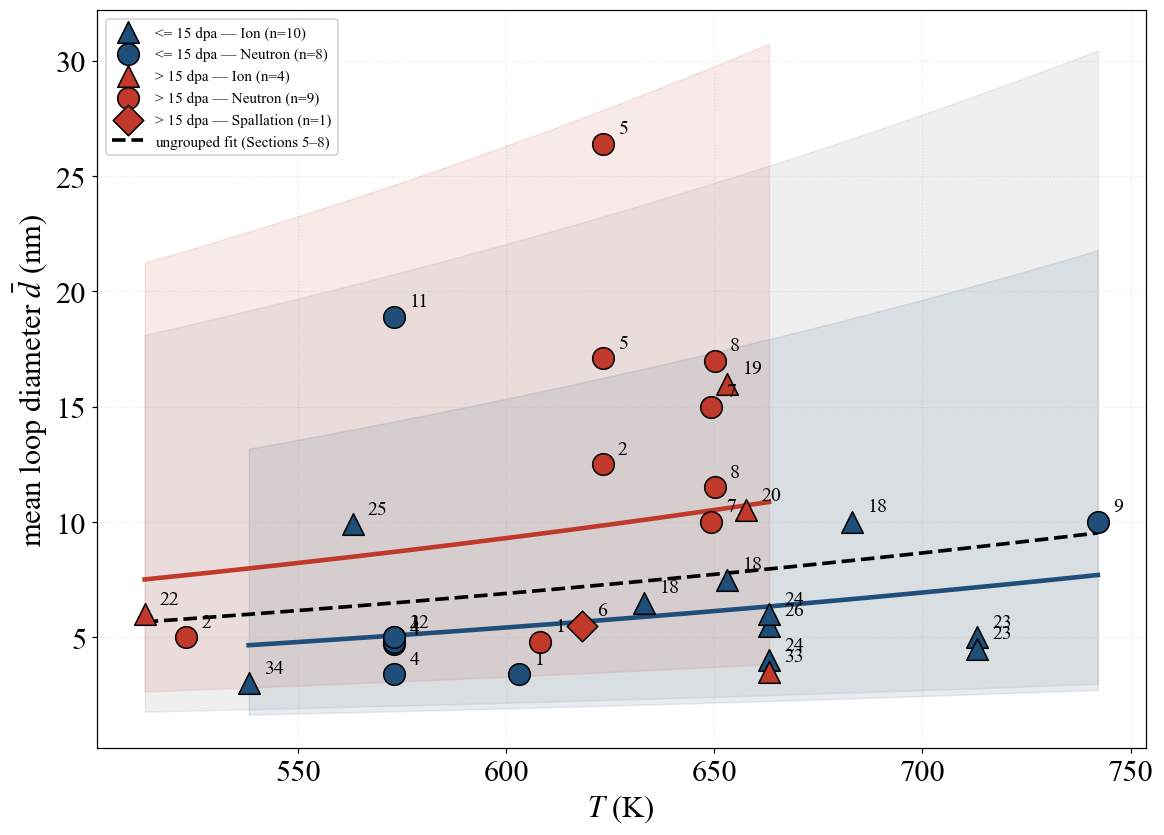

   ungrouped :  ln y = 0.5708 + 0.0022684 T    s^2 = 0.3375   GSD = 1.79   R^2 = 0.046
   grouped   :  common slope b = 0.0024651 +/- 0.00169 K^-1    s^2 = 0.2703   GSD = 1.68   adj R^2 = 0.210
   reference level '<= 15 dpa':  a = 0.2121 +/- 1.07
     offset '> 15 dpa':  +0.5392 +/- 0.185  ->  x1.71 relative to '<= 15 dpa'  (t = +2.91)
   variance removed vs ungrouped: 19.9 %


In [30]:
d = SEL[("loop", "size")]
dose = d["dose"].to_numpy(float)
y = d["size_nm"].to_numpy(float); T = cov_T(d)

print("loop-size dose threshold scan (selection is NOT free - see the caption):")
for thr in [5, 8, 10, 12, 15, 20, 30]:
    b = (dose > thr).astype(float)
    if b.sum() < 3 or (len(b) - b.sum()) < 3:
        continue
    mm = mfit(y, [T, b])
    print(f"   split at {thr:3d} dpa:  n_high = {int(b.sum()):2d}   s^2 = {mm['s2']:.3f}   "
          f"R^2 = {mm['R2']:.3f}   LOO = {loo_rms(y, [T, b]):.3f}")

lab = np.where(dose > DOSE_EDGE_LOOP, f"> {DOSE_EDGE_LOOP:g} dpa", f"<= {DOSE_EDGE_LOOP:g} dpa")
fig, m, base, lv = panel_grouped(d, "size", lab, r"mean loop diameter $\bar d$ (nm)",
                                 ref=f"<= {DOSE_EDGE_LOOP:g} dpa", ylog=False)
plt.show()
report_grouped(m, base, lv)

**Figure 10.4.** Mean loop diameter versus $T$ (K) at dose $\ge 1$ dpa, split at 15 dpa.
The reduction is real but modest (20 % of the variance) and the split point was selected
by the scan printed above, so the quoted $R^2 = 0.261$ is optimistic. Loop diameter in
this database is essentially unexplained by any recorded variable.

In [31]:
# --- the alloy hypothesis, tested where it is NOT confounded --------------------
# In the cavity data "ODS" and "He bubble" are the same five rows (Section 10.4), so the
# alloy effect cannot be isolated there.  In the LOOP data the ODS rows are ordinary
# neutron/ion loop measurements, so an ODS flag is separable and can be tested cleanly.
for quantity, label in [("density", "Loop number density"), ("size", "Mean loop diameter")]:
    d = SEL[("loop", quantity)]
    y = d[QCOL[quantity]].to_numpy(float)
    T, ion, ods = cov_T(d), cov_ion(d), cov_ods(d)
    fam, lv = group_dummies(d["family"].to_numpy(), ref="9Cr F/M")
    print("=" * 96)
    print(f"{label}   n = {len(d)}   ODS rows = {int(ods.sum())}: "
          f"{sorted(d.loc[ods.astype(bool), 'material'].unique().tolist())}")
    base = mfit(y, [T])
    for nm, cols in [("T only", [T]), ("T + ODS flag", [T, ods]),
                     ("T + alloy family", [T] + fam), ("T + Cr wt%", [T, cov_cr(d)]),
                     ("T + ion flag", [T, ion]), ("T + ion + ODS flag", [T, ion, ods])]:
        mm = mfit(y, cols, nm)
        extra = ""
        if "ODS" in nm:
            b, s = mm["beta"][-1], mm["se"][-1]
            extra = f"   ODS offset = {b:+.2f} +/- {s:.2f}  (x{np.exp(b):.1f}, t = {b/s:+.2f})"
        print(f"   {nm:20s} k={mm['p']-1}  s^2={mm['s2']:.3f}  adjR^2={mm['adjR2']:+.3f}  "
              f"AICc={mm['AICc']:6.1f}  LOO={loo_rms(y, cols):.3f}  "
              f"p_vs_T={f_pvalue(base, mm):.3f}" + extra)

Loop number density   n = 27   ODS rows = 3: ['EUROFER-ODS', 'Fe-9Cr ODS']
   T only               k=1  s^2=1.724  adjR^2=+0.132  AICc=  17.1  LOO=1.406  p_vs_T=nan
   T + ODS flag         k=2  s^2=1.792  adjR^2=+0.098  AICc=  19.6  LOO=1.433  p_vs_T=0.817   ODS offset = -0.19 +/- 0.83  (x0.8, t = -0.23)
   T + alloy family     k=3  s^2=1.841  adjR^2=+0.073  AICc=  22.0  LOO=1.467  p_vs_T=0.819
   T + Cr wt%           k=2  s^2=1.784  adjR^2=+0.101  AICc=  19.5  LOO=1.444  p_vs_T=0.700
   T + ion flag         k=2  s^2=1.054  adjR^2=+0.469  AICc=   5.3  LOO=1.065  p_vs_T=0.000
   T + ion + ODS flag   k=3  s^2=1.099  adjR^2=+0.446  AICc=   8.0  LOO=1.069  p_vs_T=0.002   ODS offset = +0.07 +/- 0.65  (x1.1, t = +0.11)
Mean loop diameter   n = 32   ODS rows = 4: ['14YWT (NFA)', 'EUROFER-ODS', 'Fe-9Cr ODS']
   T only               k=1  s^2=0.338  adjR^2=+0.014  AICc= -32.4  LOO=0.594  p_vs_T=nan
   T + ODS flag         k=2  s^2=0.343  adjR^2=-0.003  AICc= -30.5  LOO=0.651  p_vs_T=0.493   ODS 

**Table 10.2.** The alloy hypothesis tested on the loop panels, where — unlike the cavity
panels — ODS rows are ordinary loop measurements and the flag is not confounded with the
measurement type.

The result is a clean null. An ODS flag shifts the loop density by a factor 0.8 and the
loop diameter by 1.3, both well inside one standard error, and it *raises* LOO in every
combination. The 4-level alloy family and continuous Cr content do no better: for loop
density the family gives $p = 0.82$ against the temperature-only model and pushes AICc
from 17.1 to 22.0.

This is a statement about **this database**, not about the metallurgy. Only three or four
ODS rows survive into each loop panel, spread over different alloys (EUROFER-ODS,
Fe-9Cr ODS, 14YWT), facilities and doses; the residual scatter within the non-ODS rows is
comparable to any plausible ODS effect. The database as it stands cannot resolve an alloy
effect on loops — it would take a matched ODS / non-ODS pair irradiated in the same
campaign, which the workbook does not contain.

### 10.8 Recommended fits for `RadCluster` comparison

Combining the four panels, the models below are the ones worth comparing against
`RadCluster` output. Each is a common-slope, group-intercept log-linear model in $T$ (K),
$\ln y = a + b\,T + \sum_g c_g \chi_g$, with $y$ lognormally scattered about the fit with
variance $s^2$.

| Panel | Grouping | $s^2$ (was) | GSD (was) | $R^2$ (was) | Confidence |
|---|---|---|---|---|---|
| Cavity number density | He bubble vs void | 0.982 (5.209) | 2.69 (9.80) | 0.825 (0.005) | **high** — 1 dof, $p = 5\times10^{-6}$, physically unambiguous |
| Mean cavity diameter | dose $\le$ 20 / 20–50 / $>$ 50 dpa | 0.123 (0.632) | 1.42 (2.21) | 0.884 (0.333) | **high** as a stratification; bins partly track campaigns, so not a dose exponent |
| Loop number density | neutron vs ion | 1.054 (1.724) | 2.79 (3.72) | 0.510 (0.165) | **high** — 1 dof, $p = 4\times10^{-4}$, 6.2× dose-rate offset |
| Mean loop diameter | dose $>$ 15 dpa | 0.270 (0.338) | 1.68 (1.79) | 0.261 (0.046) | **low** — threshold selected by scan; use the ungrouped fit instead |

Caveats that apply to the whole section:

1. **Small samples.** The cavity panels have $n = 17$ and $n = 21$ and roughly eight
   candidate models were compared on each. LOO guards against overfitting the *parameters*
   but not against overfitting the *model choice*; with $n = 17$ the ranking below the top
   entry is not reliable.
2. **Selected bin edges.** The cavity dose edges (20, 50 dpa) were placed at visible gaps
   in the data and the loop threshold (15 dpa) by scanning. Both are data-dependent
   choices, so their nominal $p$-values are optimistic. The cavity result survives this
   easily — it is an 81 % reduction with a clear physical reading — the loop-size result
   does not.
3. **The cavity-density result is a classification fix, not a regression trick.** The
   honest way to use it is to compare `RadCluster` void output against the *void* line
   only, and He-bubble data against the bubble line, rather than against a pooled cavity
   fit. Setting `INCLUDE_HE_BUBBLES = False` in Section 4 and re-running reproduces the
   void-only fit directly.
4. **Alloy class is not usable** as a grouping anywhere in this database (Section 10.7).

---
# 11. Summary and use for `RadCluster` validation

### 11.1 What the fits give you
For every combination of {loops, cavities} $\times$ {number density, mean diameter}
$\times$ {dose < 1 dpa, dose ≥ 1 dpa} there is now a two-parameter log-normal model
against temperature — number densities on both the $T$ and the $1000/T$ (Arrhenius)
axis, mean diameters on the $T$ axis only —

$$y(T) \sim \mathrm{Lognormal}\!\left(a + b\,x,\ s^2\right),$$

reported with coefficient standard errors, residual variance, geometric scatter and $R^2$,
plus the group geometric mean and geometric standard deviation. These are directly
comparable with `RadCluster` outputs: the loop density and mean loop diameter reductions,
and the cavity density / mean cavity diameter reductions, evaluated at the experimental
$(T,\phi)$ and compared point-by-point against the numbered caption tables.

### 11.2 Honest limitations
1. **The dose < 1 dpa group is data-starved.** The database contains only **two** loop
   entries below 1 dpa (pure Fe: Eldrup 1999 at 0.79 dpa/60 °C and Lambrecht 2009 at
   0.19 dpa/300 °C) and **four** cavity entries. The two loop diameters happen to
   reduce to the same value (10 nm from `~5–15` and `~8–12`), so the low-dose loop-size fit
   is exactly flat and carries no information. These panels are produced as requested, but
   the fitted slopes there should be treated as placeholders, not as measurements. No
   further sub-1 dpa loop or void data exist in this workbook.
2. **Pooled temperature slopes are weak.** Several ≥ 1 dpa fits have $R^2 < 0.2$ and
   slopes within one standard error of zero. This is a property of the data, not of the
   fit: pooling ten alloys, three orders of magnitude in dose rate, and matrix-versus-
   near-dislocation counting conventions produces alloy-to-alloy scatter comparable to the
   temperature signal. The dashed neutron-only lines and the printed sub-fits isolate the
   cleaner subsets; the within-series trends of Appendix G Fig. G.11 remain the
   authoritative statement of the temperature dependence. **Section 10 quantifies how
   much of this scatter is recoverable** by grouping on irradiation type, dose and
   measurement type — 39 % to 81 % depending on the panel.
3. **Ranges and bounds are reduced to point values.** `~10–15` becomes 12.5, `<5` becomes
   5. Rows so reduced are flagged (`size_flags`, `dens_flags`) in `DB` and can be excluded
   by filtering on those columns.
4. **He bubbles are counted as cavities.** `INCLUDE_HE_BUBBLES = True` merges the
   `Ion_He_Bubbles` sheet into the void population, which is what makes the low-dose cavity
   group non-degenerate. Every cavity panel also prints a *voids only (He-bubble rows
   excluded)* sub-fit so the effect is visible; set the flag to `False` to drop them.
   **Section 10.4 shows this is the single largest source of scatter in the notebook**:
   fitting bubbles and voids as separate populations removes 81 % of the cavity-density
   variance for one degree of freedom.
5. **Bimodal cavity rows lose their mean diameter.** `Bimodal: <2 + >2` has no single
   representative diameter, so those rows contribute a total density but no size. The
   bimodal density is the **sum** of the bubble and void populations.
6. **Only loops and voids are fitted**, as requested. Precipitate sheets
   (`Neutron_Precipitates`, `Ion_Precipitates`) and swelling are read into the workbook but
   not analysed here.
7. **Void size distributions do not exist** in this database; only the six loop histograms
   of Section 9 are resolved distributions.

### 11.3 Reproducibility
Every value plotted is derived in this notebook from the raw workbook sheets — no
intermediate or derived file is used. The one data repair applied (Section 4.2) is
declared in `ROW_FIXUPS` and printed at load time. The full tidy table is available as
`DB` and can be written out for downstream use.

In [32]:
DB.to_csv("FerriticSteels_parsed_database.csv", index=False)
print("wrote FerriticSteels_parsed_database.csv  "
      f"({len(DB)} rows x {DB.shape[1]} columns)")
DB.head(12)

wrote FerriticSteels_parsed_database.csv  (68 rows x 26 columns)


,defect,cavity_kind,sheet,irradiation,material,alloy,dose,dose_bound,T_C,T_bound,...,irr_src,burgers,T_K,T_K_eq,dose_group,series,ref_key,ref_no,family,Cr_wt
0,loop,loop,Neutron_DislocLoops,Neutron,EUROFER97,RAFM (9Cr-WTaV),15.00,,330.0,,...,Neutron (fast),½⟨111⟩ dominant at ≤300°C; ⟨100⟩ at ≥350°C,603.15,603.15,>=1 dpa,Neutron,Klimenkov 2012,1,9Cr F/M,9.0
1,loop,loop,Neutron_DislocLoops,Neutron,EUROFER97,RAFM (9Cr-WTaV),32.00,,335.0,,...,Neutron (fast),⟨100⟩ dominant,608.15,608.15,>=1 dpa,Neutron,Klimenkov 2012,1,9Cr F/M,9.0
2,loop,loop,Neutron_DislocLoops,Neutron,EUROFER97,RAFM (9Cr-WTaV),15.00,,300.0,,...,Neutron (mixed spect.),½⟨111⟩,573.15,573.15,>=1 dpa,Neutron,Gaganidze 2016,3,9Cr F/M,9.0
3,loop,loop,Neutron_DislocLoops,Neutron,EUROFER97,RAFM (9Cr-WTaV),16.30,,250.0,,...,Neutron (fast),½⟨111⟩,523.15,523.15,>=1 dpa,Neutron,Gaganidze 2011,2,9Cr F/M,9.0
4,loop,loop,Neutron_DislocLoops,Neutron,EUROFER97,RAFM (9Cr-WTaV),16.30,,350.0,,...,Neutron (fast),⟨100⟩ dominant,623.15,623.15,>=1 dpa,Neutron,Gaganidze 2011,2,9Cr F/M,9.0
5,loop,loop,Neutron_DislocLoops,Spallation,F82H,RAFM (8Cr-2W),20.00,,345.0,,...,Neutron (spallation),½⟨111⟩,618.15,618.15,>=1 dpa,Spallation,Wan 2010,6,9Cr F/M,8.0
6,loop,loop,Neutron_DislocLoops,Neutron,T91,FM (9Cr-1Mo-V-Nb),15.40,,376.0,,...,Neutron (fast),a⟨100⟩,649.15,649.15,>=1 dpa,Neutron,Gao 2018,7,9Cr F/M,9.0
7,loop,loop,Neutron_DislocLoops,Neutron,T91,FM (9Cr-1Mo-V-Nb),35.10,,376.0,,...,Neutron (fast),a⟨100⟩ dominant,649.15,649.15,>=1 dpa,Neutron,Gao 2018,7,9Cr F/M,9.0
8,loop,loop,Neutron_DislocLoops,Neutron,T91,FM (9Cr-1Mo-V-Nb),4.30,,469.0,,...,Neutron (fast),a⟨100⟩ + a/2⟨111⟩,742.15,742.15,>=1 dpa,Neutron,Zhong 2021,9,9Cr F/M,9.0
9,loop,loop,Neutron_DislocLoops,Neutron,HT9,FM (12Cr-1Mo-W-V),17.10,,377.0,,...,Neutron (fast),a⟨100⟩ dominant,650.15,650.15,>=1 dpa,Neutron,Gao 2019,8,12Cr F/M,12.0


---
# 12. $\langle 100\rangle$ / $\frac{1}{2}\langle 111\rangle$ loop character fractions

The `Loop_fractions` sheet records, for each experiment that resolved both Burgers
vectors, the **percentage of the loop population that is $\langle 100\rangle$**. It is
the one quantity in the database that bears directly on the loop-conversion channel,
since it is the observable a $\frac{1}{2}\langle 111\rangle \rightarrow \langle
100\rangle$ reaction model has to reproduce.

### 12.1 Why this sheet needs its own loader
The sheet is laid out differently from the five measurement sheets, in two ways that
break the generic loader:

* the **source is a merged cell** spanning the block of rows it covers, so a plain
  forward fill attributes the first row of each block to the previous paper;
* a measurement that resolved both Burgers vectors occupies **two rows carrying the
  same $\langle 100\rangle$ fraction** — one per loop type — so reading rows as
  measurements counts every resolved experiment twice.

`load_loop_fractions()` resolves the source through `openpyxl`'s merged-cell ranges and
collapses the duplicated pairs. The fraction itself is part of the collapsing key, so
the two analyses Dethloff (2018) reports for each condition — resolved loops only, and
loops together with black dots — are kept as separate measurements.

### 12.2 The fitted model
A fraction is bounded on $[0, 100]$, so the log-linear model of Sections 5–8 is not
appropriate: it is unbounded above and would predict fractions beyond $100\,\%$. The
natural analogue that respects the bound is **logit-linear**,

$$\mathrm{logit}\,f \;\equiv\; \ln\frac{f}{1-f} \;=\; a + b\,T_{\rm eq},
\qquad\Longleftrightarrow\qquad
f(T_{\rm eq}) \;=\; \frac{1}{1 + e^{-(a + b\,T_{\rm eq})}},$$

with $f$ the $\langle 100\rangle$ fraction as a proportion. The fit is reported through
$b$ and its standard error, the residual scatter $s$ **on the logit scale**, $R^2$, and
the temperature $T_{50} = -a/b$ at which the two populations are predicted equal —
which is the single most useful number for calibration.

Six of the 28 measurements report exactly $0\,\%$ or $100\,\%$. These are *qualitative*
statements — no $\langle 100\rangle$ loops seen, or none of the other type — and their
logit is infinite. They are plotted as open symbols and **excluded from the quoted
fit**; a sensitivity fit that includes them under a continuity correction
$f \rightarrow \max(\epsilon, \min(100-\epsilon, f))$ with $\epsilon = 0.5$ percentage
points is reported alongside, because that choice changes the conclusion and the reader
should see it.


In [ ]:
# --- <100> / 1/2<111> loop fractions: loader, logit fit, panel -----------------
import openpyxl

LF_SHEET   = "Loop_fractions"
LF_SRC_COL = 10          # 1-based column J, "Paper"
LF_EPS     = 0.5         # percentage points, the 0 %/100 % continuity correction

# The merged source cell of the Chauhan block starts one row too low: Excel row 40
# carries the <100> half of a measurement whose other half is in the merged range
# J41:J45.  Declared here rather than silently forward-filled; delete the entry once
# the merge is extended to J40:J45 in the workbook.
LF_MERGE_FIXUPS = {40: 41}

# The sheet spells its sources as full titles, and introduces thirteen papers that the
# five measurement sheets do not cite.  Each is matched on a distinctive substring and
# mapped to the canonical key of Section 4.8, so a paper that appears in both keeps one
# number throughout the notebook.
LF_SOURCE_KEYS = [
    ("Dethloff et al. - 2016",   "Dethloff 2016"),
    ("Dethloff et al. - 2018",   "Dethloff 2018"),
    ("Klimenkov et al. - 2011",  "Klimenkov 2011"),
    ("Klimenkov et al. - 2017",  "Klimenkov 2017"),
    ("Klimenkov et al. - 2020",  "Klimenkov 2020"),
    ("Klimenkov et al. - 2021",  "Klimenkov 2021"),
    ("Weiß et al. - 2012",       "Weiß 2012"),
    ("Boulanger and Serruys",    "Boulanger & Serruys 2009"),
    ("Chauhan et al. - 2021",    "Chauhan 2021"),
    ("Schaublin2002",            "Schäublin 2002"),
    ("Chen2013",                 "Chen 2013"),
    ("Rogozhkin et al. - 2019 - The influence of Fe-ion", "Rogozhkin 2019a"),
    ("Rogozhkin et al. - 2019 - Study of Microscopic",    "Rogozhkin 2019b"),
    ("Brimbal et al. - 2015",    "Brimbal 2015"),
    ("Zhang et al. - 2014",      "Zhang 2014"),
    ("Kaiser et al. - 2018",     "Kaiser 2018"),
]

# Sources excluded from the loop-fraction analysis, with the reason.  Discarding
# measurements is a judgement rather than a parsing step, so it is declared here, in
# one place, and reported at load time -- never applied silently inside a fit.
LF_EXCLUDE_SOURCES = {
    "Klimenkov 2011":
        "reports 0 % <100> in EUROFER97 at 300 and 350 C, where Dethloff (2016, 2018) "
        "report 77-78 % and Klimenkov (2020) reports 27 % and 79 % for the same "
        "material at the same temperatures and comparable dose; superseded by the "
        "later diffraction analyses of the same group",
}

def lf_ref_key(s):
    """Full title recorded in the sheet -> canonical author-year key."""
    s = str(s)
    for frag, key in LF_SOURCE_KEYS:
        if frag in s:
            return key
    return s.split(" - ")[0].strip()

def lf_material_class(s):
    """EUROFER-ODS (any variant) versus unstrengthened EUROFER97."""
    return "EUROFER-ODS" if "ODS" in str(s).upper() else "EUROFER97"

def load_loop_fractions():
    """One row per <100>-fraction measurement, on the same T_eq axis as Sections 5-8."""
    ws = openpyxl.load_workbook(XLSX)[LF_SHEET]
    src = {}
    for rng in ws.merged_cells.ranges:                    # merged source cells first
        if rng.min_col == LF_SRC_COL:
            v = ws.cell(row=rng.min_row, column=LF_SRC_COL).value
            for r in range(rng.min_row, rng.max_row + 1):
                src[r] = v
    for r in range(2, ws.max_row + 1):                    # then any unmerged ones
        v = ws.cell(row=r, column=LF_SRC_COL).value
        if v is not None:
            src.setdefault(r, v)
    for bad, good in LF_MERGE_FIXUPS.items():
        src[bad] = src.get(good)

    raw = pd.read_excel(XLSX, sheet_name=LF_SHEET, header=None).iloc[1:]
    rows = []
    for i, r in raw.iterrows():
        if pd.isna(r.iloc[2]):
            continue                                     # no fraction on this row
        xl = i + 1
        rows.append(dict(xlrow=xl, material=_s(r.iloc[0]), burgers=_s(r.iloc[1]),
                         frac=float(r.iloc[2]), T_C=float(r.iloc[3]),
                         dose=float(r.iloc[4]), irr_src=_s(r.iloc[7]),
                         facility=_s(r.iloc[8]), source=_s(src.get(xl)),
                         note=_s(r.iloc[10])))
    d = pd.DataFrame(rows)
    unsourced = sorted(d.loc[d.source == "", "xlrow"].tolist())

    # Collapse the two Burgers-vector rows of one measurement.  `frac` is in the key,
    # so genuinely different analyses of the same specimen stay separate.
    d = (d.groupby(["source", "material", "T_C", "dose", "irr_src", "frac"],
                   as_index=False)
           .agg(xlrows=("xlrow", list), facility=("facility", "first"),
                burgers=("burgers", lambda s: "/".join(sorted({x for x in s if x}))),
                note=("note", lambda s: "; ".join(sorted({x for x in s if x})))))

    d["irradiation"] = np.where(
        d["irr_src"].str.strip().str.lower().str.startswith("ion"), "Ion", "Neutron")
    d["series"]    = d["irradiation"]
    d["T_K"]       = d["T_C"] + 273.15
    d["T_K_eq"]    = d["T_K"] + np.where(d["irradiation"].eq("Ion"), T_SHIFT_ION, 0.0)
    d["interior"]  = (d["frac"] > 0) & (d["frac"] < 100)
    d["black_dots"] = d["note"].str.contains("blackdot", case=False, regex=False)
    d["alloy"]     = d["material"].map(lf_material_class)
    d["ref_key"]   = d["source"].map(lf_ref_key)
    d["ref_no"]    = d["ref_key"].map(lambda k: REF_NO.get(k, 0))
    drop = d["ref_key"].isin(LF_EXCLUDE_SOURCES)
    if drop.any():
        for key in sorted(d.loc[drop, "ref_key"].unique()):
            n = int((d["ref_key"] == key).sum())
            print(f"excluded {n} measurement(s) from [{REF_NO.get(key, 0)}] {key}: "
                  f"{LF_EXCLUDE_SOURCES[key]}")
        d = d[~drop]
    if unsourced:
        print(f"rows with no source after the merge map (add to LF_MERGE_FIXUPS): {unsourced}")
    miss = sorted(d.loc[d.ref_no == 0, "ref_key"].unique())
    if miss:
        print(f"UNKEYED loop-fraction sources (add to REFERENCES): {miss}")
    return d.sort_values(["T_K_eq", "source"]).reset_index(drop=True)


def logit_fit(T, frac, eps=None):
    """OLS of logit(f) on T.  `eps` (in %) clips 0 / 100 so they can be included."""
    T = np.asarray(T, float); p = np.asarray(frac, float)
    if eps is not None:
        p = np.clip(p, eps, 100.0 - eps)
    g = np.isfinite(T) & (p > 0) & (p < 100)
    T, p = T[g], p[g] / 100.0
    n = len(T)
    out = dict(n=n)
    if n < 3 or np.ptp(T) == 0:
        return out
    y = np.log(p / (1 - p))
    X = np.column_stack([np.ones(n), T])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    res = y - X @ beta
    s2 = float(res @ res / (n - 2))
    cov = s2 * np.linalg.inv(X.T @ X)
    tss = float(((y - y.mean()) ** 2).sum())
    out.update(a=float(beta[0]), b=float(beta[1]), s2=s2, s=float(np.sqrt(s2)),
               se_a=float(np.sqrt(cov[0, 0])), se_b=float(np.sqrt(cov[1, 1])),
               R2=float(1 - res @ res / tss) if tss > 0 else np.nan,
               T50=float(-beta[0] / beta[1]) if beta[1] != 0 else np.nan)
    return out


def _logistic(T, a, b):
    return 100.0 / (1.0 + np.exp(-(a + b * np.asarray(T, float))))


LF_COL = {"EUROFER97": "#1f4e79", "EUROFER-ODS": "#c0392b"}

def panel_loop_fraction(d, ylabel=r"$\langle 100\rangle$ loop fraction (\%)".replace("\\%", "%")):
    """Fraction against T_eq: interior points fitted, 0 %/100 % shown but not fitted."""
    fig, ax = plt.subplots(figsize=(11, 8))
    for alloy, g in d.groupby("alloy", sort=True):
        c = LF_COL.get(alloy, "0.4")
        for interior, gg in g.groupby("interior", sort=True):
            ax.scatter(gg["T_K_eq"], gg["frac"], s=200, marker="o",
                       c=[c] if interior else ["none"], edgecolors=c if not interior else "k",
                       linewidths=1.0 if interior else 2.2, zorder=3,
                       label=f"{alloy} ($n$ = {len(gg)})" if interior
                             else f"{alloy}, 0 % or 100 % ($n$ = {len(gg)})")
    for _, r in d.iterrows():
        ax.annotate(str(int(r["ref_no"])), (r["T_K_eq"], r["frac"]),
                    textcoords="offset points", xytext=(10, 7),
                    fontsize=PT_LABEL_FS, zorder=4)
    fit = logit_fit(d["T_K_eq"], d["frac"])
    sens = logit_fit(d["T_K_eq"], d["frac"], eps=LF_EPS)
    if "a" in fit:
        xs = np.linspace(d["T_K_eq"].min(), d["T_K_eq"].max(), 300)
        ax.plot(xs, _logistic(xs, fit["a"], fit["b"]), "k-", lw=3.0, zorder=2)
        lo = _logistic(xs, fit["a"] - 2 * fit["s"], fit["b"])
        hi = _logistic(xs, fit["a"] + 2 * fit["s"], fit["b"])
        ax.fill_between(xs, lo, hi, color="0.5", alpha=0.16, zorder=1)
    if "a" in sens:
        xs = np.linspace(d["T_K_eq"].min(), d["T_K_eq"].max(), 300)
        ax.plot(xs, _logistic(xs, sens["a"], sens["b"]), "--", color="#8e44ad", lw=2.6,
                zorder=2, label=r"including 0 %/100 % ($\epsilon$ = 0.5 pp)")
    ax.set_xlabel(r"$T_{\rm eq}$ (K)")
    ax.set_ylabel(ylabel)
    ax.set_ylim(-5, 105)
    # `place_legend_inside` makes room by extending the axis, which on a percentage
    # axis would print negative tick labels.  Pin the ticks to the physical range so
    # that the extra room stays blank rather than mislabelled.
    ax.set_yticks(np.arange(0, 101, 20))
    ax.grid(alpha=0.3, ls=":")
    place_legend_inside(ax)
    fig.tight_layout()
    return fig, fit, sens


def panel_loop_fraction_by_source(d):
    """The same measurements joined within each source, which is where the trend is."""
    fig, ax = plt.subplots(figsize=(11, 8))
    pal = list(plt.get_cmap("tab10").colors) + list(plt.get_cmap("Set2").colors)
    for i, (key, g) in enumerate(d.groupby("ref_key", sort=True)):
        g = g.sort_values("T_K_eq")
        c = pal[i % len(pal)]
        ls = "-" if g["irradiation"].iloc[0] == "Neutron" else "--"
        ax.plot(g["T_K_eq"], g["frac"], ls=ls, marker="o", ms=13, lw=2.4, color=c,
                markeredgecolor="k", markeredgewidth=0.8, zorder=3,
                label=f"[{int(g['ref_no'].iloc[0])}] {key} "
                      f"({g['irradiation'].iloc[0].lower()}, {g['alloy'].iloc[0]})")
    ax.set_xlabel(r"$T_{\rm eq}$ (K)")
    ax.set_ylabel(r"$\langle 100\rangle$ loop fraction (%)")
    ax.set_ylim(-5, 105)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.grid(alpha=0.3, ls=":")
    place_legend_inside(ax)
    fig.tight_layout()
    return fig


def report_loop_fraction(name, fit, sens):
    L = [f"[{name}]  n fitted = {fit.get('n', 0)}"]
    if "a" not in fit:
        L.append("   fewer than 3 interior points or no temperature spread -> no fit")
    else:
        L.append(f"   logit f = a + b*T:  a = {fit['a']:+.4f} +/- {fit['se_a']:.4f},"
                 f"   b = {fit['b']:+.5f} +/- {fit['se_b']:.5f}"
                 f"  (t = {fit['b']/fit['se_b']:+.2f})")
        L.append(f"   s = {fit['s']:.4f} (logit units),  R^2 = {fit['R2']:.3f},"
                 f"   T(f = 50 %) = {fit['T50']:.0f} K = {fit['T50']-273.15:.0f} C")
    if "a" in sens:
        L.append(f"   sensitivity, 0 %/100 % included at eps = {LF_EPS} pp: n = {sens['n']},"
                 f" b = {sens['b']:+.5g} +/- {sens['se_b']:.3g}"
                 f" (t = {sens['b']/sens['se_b']:+.2f}), R^2 = {sens['R2']:.3f},"
                 f" T50 = {sens['T50']-273.15:.0f} C")
    print("\n".join(L))


LOOPFRAC = load_loop_fractions()
print(f"loop-fraction measurements: {len(LOOPFRAC)}   |   "
      f"{dict(LOOPFRAC.groupby('irradiation').size())}   |   "
      f"reporting 0 % or 100 %: {int((~LOOPFRAC.interior).sum())}   |   "
      f"sources: {LOOPFRAC.ref_key.nunique()}")
print(LOOPFRAC[["ref_no", "ref_key", "material", "T_C", "dose", "irradiation",
                "frac", "black_dots"]].to_string(index=False))


In [ ]:
# --- the three loop-fraction panels ------------------------------------------
LF_N = LOOPFRAC[LOOPFRAC.irradiation == "Neutron"]
LF_I = LOOPFRAC[LOOPFRAC.irradiation == "Ion"]

fig, fit_n, sens_n = panel_loop_fraction(LF_N)
plt.show()
report_loop_fraction("neutron", fit_n, sens_n)

fig, fit_i, sens_i = panel_loop_fraction(LF_I)
plt.show()
report_loop_fraction("ion", fit_i, sens_i)

fig = panel_loop_fraction_by_source(LOOPFRAC)
plt.show()

# Within-source trends: the pooled fit is weak, but each series is not.
print("\nwithin-source fits (sources with >= 3 interior points at >= 2 temperatures):")
for key, g in LOOPFRAC.groupby("ref_key"):
    gi = g[g.interior]
    if len(gi) >= 3 and gi["T_K_eq"].nunique() >= 2:
        r = logit_fit(gi["T_K_eq"], gi["frac"])
        if "a" in r:
            print(f"   [{int(g.ref_no.iloc[0]):2d}] {key:24s} n = {r['n']}, "
                  f"b = {r['b']:+.5f} +/- {r['se_b']:.5f} (t = {r['b']/r['se_b']:+.2f}), "
                  f"R^2 = {r['R2']:.3f}, T50 = {r['T50']-273.15:.0f} C")
